### Environment Setup & GPU Check

In [1]:
# ============================================================
# CELL 1: ENVIRONMENT SETUP & GPU CHECK
# Industrial Video Analytics & Safety Rule Engine
# ============================================================

import sys
import subprocess
import importlib.util


def install_if_missing(module_name, package_name=None):
    """Install package only if it is not already available."""
    package_name = package_name or module_name

    if importlib.util.find_spec(module_name) is None:
        print(f"Installing {package_name} ...")
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package_name
        ])
    else:
        print(f"✓ {module_name} already installed")


# Required packages
install_if_missing("ultralytics")
install_if_missing("shapely")


# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------

import os
import cv2
import torch
import numpy as np
import pandas as pd
import ultralytics

from pathlib import Path
from ultralytics import YOLO
from shapely.geometry import Point, Polygon


# ------------------------------------------------------------
# GPU configuration
# ------------------------------------------------------------

CUDA_AVAILABLE = torch.cuda.is_available()
DEVICE = 0 if CUDA_AVAILABLE else "cpu"


print("\n" + "=" * 70)
print("INDUSTRIAL VIDEO ANALYTICS - ENVIRONMENT CHECK")
print("=" * 70)

print(f"Python Version      : {sys.version.split()[0]}")
print(f"PyTorch Version     : {torch.__version__}")
print(f"Ultralytics Version : {ultralytics.__version__}")
print(f"OpenCV Version      : {cv2.__version__}")

print("-" * 70)

print(f"CUDA Available      : {CUDA_AVAILABLE}")

if CUDA_AVAILABLE:
    print(f"GPU                 : {torch.cuda.get_device_name(0)}")
    print(
        f"GPU Memory          : "
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
    )
else:
    print("GPU                 : CPU")

print("=" * 70)

print("\n✓ Environment setup completed successfully.")

Installing ultralytics ...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 4.1 MB/s eta 0:00:00
✓ shapely already installed
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.

INDUSTRIAL VIDEO ANALYTICS - ENVIRONMENT CHECK
Python Version      : 3.12.13
PyTorch Version     : 2.10.0+cu128
Ultralytics Version : 8.4.163
OpenCV Version      : 4.13.0
----------------------------------------------------------------------
CUDA Available      : True
GPU                 : Tesla T4
GPU Memory          : 14.56 GB

✓ Environment setup completed successfully.


### Model Discovery, Loading & Class Verification

In [2]:
# ============================================================
# CELL 2: DISCOVER, LOAD & VERIFY CUSTOM YOLO MODELS
# ============================================================

from pathlib import Path
from ultralytics import YOLO


# ------------------------------------------------------------
# 1. Find all .pt model files available in Kaggle Input
# ------------------------------------------------------------

KAGGLE_INPUT = Path("/kaggle/input")

all_pt_files = list(KAGGLE_INPUT.rglob("*.pt"))

print("=" * 80)
print("AVAILABLE YOLO WEIGHTS")
print("=" * 80)

if not all_pt_files:
    raise FileNotFoundError(
        "No .pt files found inside /kaggle/input.\n"
        "Please add your model weights using Kaggle -> Add Input."
    )

for i, path in enumerate(all_pt_files, start=1):
    print(f"{i:02d}. {path}")

print(f"\nTotal .pt files found: {len(all_pt_files)}")


# ------------------------------------------------------------
# 2. Automatically identify our required models
# ------------------------------------------------------------

def find_model(keywords, files):
    """
    Return best matching .pt file containing all given keywords.
    """
    keywords = [k.lower() for k in keywords]

    matches = []

    for file_path in files:
        name = file_path.name.lower()

        if all(keyword in name for keyword in keywords):
            matches.append(file_path)

    if not matches:
        return None

    return matches[0]


model_paths = {
    "person": find_model(["person"], all_pt_files),

    "forklift": find_model(["forklift"], all_pt_files),

    "helmet_vest": find_model(
        ["helmet", "vest"],
        all_pt_files
    ),

    "gloves": find_model(
        ["gloves"],
        all_pt_files
    ),
}


# ------------------------------------------------------------
# 3. Verify all required model paths
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("MODEL PATH VERIFICATION")
print("=" * 80)

missing_models = []

for model_name, path in model_paths.items():

    if path is None:
        print(f"❌ {model_name:<15} : NOT FOUND")
        missing_models.append(model_name)

    else:
        print(f"✅ {model_name:<15} : {path}")


if missing_models:
    raise FileNotFoundError(
        f"\nMissing models: {missing_models}\n"
        "Please make sure all required weights are added to Kaggle."
    )


# ------------------------------------------------------------
# 4. Load YOLO models
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("LOADING MODELS")
print("=" * 80)

models = {}

for model_name, model_path in model_paths.items():

    print(f"\nLoading: {model_name}")

    models[model_name] = YOLO(str(model_path))

    print("✓ Loaded successfully")


# ------------------------------------------------------------
# 5. Print exact class names from every model
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("MODEL CLASS INFORMATION")
print("=" * 80)

for model_name, model in models.items():

    print(f"\nMODEL: {model_name.upper()}")
    print("-" * 50)

    class_names = model.names

    for class_id, class_name in class_names.items():
        print(
            f"Class ID {class_id:<3} -> {class_name}"
        )


print("\n" + "=" * 80)
print("✓ ALL MODELS LOADED SUCCESSFULLY")
print("=" * 80)

AVAILABLE YOLO WEIGHTS
01. /kaggle/input/models/basitibrahim/rule-models/pytorch/default/1/Camnitive_Helmet_Vest.pt
02. /kaggle/input/models/basitibrahim/rule-models/pytorch/default/1/Camnitive_Safety_Gloves.pt
03. /kaggle/input/models/basitibrahim/rule-models/pytorch/default/1/Camnitive_Person.pt
04. /kaggle/input/models/basitibrahim/rule-models/pytorch/default/1/Camnitive_Forklift.pt

Total .pt files found: 4

MODEL PATH VERIFICATION
✅ person          : /kaggle/input/models/basitibrahim/rule-models/pytorch/default/1/Camnitive_Person.pt
✅ forklift        : /kaggle/input/models/basitibrahim/rule-models/pytorch/default/1/Camnitive_Forklift.pt
✅ helmet_vest     : /kaggle/input/models/basitibrahim/rule-models/pytorch/default/1/Camnitive_Helmet_Vest.pt
✅ gloves          : /kaggle/input/models/basitibrahim/rule-models/pytorch/default/1/Camnitive_Safety_Gloves.pt

LOADING MODELS

Loading: person
✓ Loaded successfully

Loading: forklift
✓ Loaded successfully

Loading: helmet_vest
✓ Loaded suc

### Project Configuration + Unified Class Registry

In [3]:
# ============================================================
# CELL 3: PROJECT CONFIGURATION & UNIFIED CLASS REGISTRY
# ============================================================

from pathlib import Path
import json


# ------------------------------------------------------------
# 1. Project directories
# ------------------------------------------------------------

PROJECT_ROOT = Path("/kaggle/working/industrial_safety_engine")

DIRS = {
    "root": PROJECT_ROOT,
    "outputs": PROJECT_ROOT / "outputs",
    "alerts": PROJECT_ROOT / "outputs" / "alerts",
    "videos": PROJECT_ROOT / "outputs" / "videos",
    "logs": PROJECT_ROOT / "outputs" / "logs",
    "configs": PROJECT_ROOT / "configs",
}

for path in DIRS.values():
    path.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 2. Inference configuration
# ------------------------------------------------------------

INFERENCE_CONFIG = {
    "device": DEVICE,

    # Starting value for Kaggle T4.
    # We can tune this after testing the demo video.
    "imgsz": 960,

    "models": {
        "person": {
            "confidence": 0.35,
            "allowed_classes": ["person"],
        },

        "forklift": {
            "confidence": 0.35,

            # IMPORTANT:
            # Person is intentionally excluded because we already
            # have a dedicated person detector.
            "allowed_classes": [
                "container",
                "crane",
                "forklift",
                "ship",
                "stacker",
                "truck",
            ],
        },

        "helmet_vest": {
            "confidence": 0.35,
            "allowed_classes": [
                "Helmet",
                "No Helmet",
                "No Safety Vest",
                "Safety Vest",
            ],
        },

        "gloves": {
            "confidence": 0.35,
            "allowed_classes": [
                "gloves",
                "no gloves",
            ],
        },
    },
}


# ------------------------------------------------------------
# 3. Unified class registry
# ------------------------------------------------------------

CLASS_REGISTRY = {
    # Person
    "person": {
        "model": "person",
        "model_class_name": "person",
        "category": "person",
    },

    # MHE / Vehicle classes
    "forklift": {
        "model": "forklift",
        "model_class_name": "forklift",
        "category": "vehicle",
    },

    "stacker": {
        "model": "forklift",
        "model_class_name": "stacker",
        "category": "vehicle",
    },

    "truck": {
        "model": "forklift",
        "model_class_name": "truck",
        "category": "vehicle",
    },

    "crane": {
        "model": "forklift",
        "model_class_name": "crane",
        "category": "vehicle",
    },

    "container": {
        "model": "forklift",
        "model_class_name": "container",
        "category": "object",
    },

    "ship": {
        "model": "forklift",
        "model_class_name": "ship",
        "category": "object",
    },

    # Helmet / Vest
    "helmet": {
        "model": "helmet_vest",
        "model_class_name": "Helmet",
        "category": "ppe",
    },

    "no_helmet": {
        "model": "helmet_vest",
        "model_class_name": "No Helmet",
        "category": "ppe_violation",
    },

    "safety_vest": {
        "model": "helmet_vest",
        "model_class_name": "Safety Vest",
        "category": "ppe",
    },

    "no_safety_vest": {
        "model": "helmet_vest",
        "model_class_name": "No Safety Vest",
        "category": "ppe_violation",
    },

    # Gloves
    "gloves": {
        "model": "gloves",
        "model_class_name": "gloves",
        "category": "ppe",
    },

    "no_gloves": {
        "model": "gloves",
        "model_class_name": "no gloves",
        "category": "ppe_violation",
    },
}


# ------------------------------------------------------------
# 4. Reverse lookup:
#    model -> original model class -> unified class
# ------------------------------------------------------------

MODEL_CLASS_TO_UNIFIED = {}

for unified_name, info in CLASS_REGISTRY.items():

    model_name = info["model"]
    original_name = info["model_class_name"]

    MODEL_CLASS_TO_UNIFIED.setdefault(model_name, {})
    MODEL_CLASS_TO_UNIFIED[model_name][original_name] = unified_name


# ------------------------------------------------------------
# 5. Validate registry against actual loaded model classes
# ------------------------------------------------------------

print("=" * 80)
print("CLASS REGISTRY VALIDATION")
print("=" * 80)

registry_errors = []

for unified_name, info in CLASS_REGISTRY.items():

    model_key = info["model"]
    target_class = info["model_class_name"]

    available_classes = list(models[model_key].names.values())

    if target_class not in available_classes:

        registry_errors.append(
            f"{unified_name} -> "
            f"{model_key}:{target_class}"
        )

        print(
            f"❌ {unified_name:<18} "
            f"-> {model_key:<12} "
            f"-> {target_class}"
        )

    else:

        print(
            f"✅ {unified_name:<18} "
            f"-> {model_key:<12} "
            f"-> {target_class}"
        )


if registry_errors:
    raise ValueError(
        "\nInvalid class registry entries:\n" +
        "\n".join(registry_errors)
    )


# ------------------------------------------------------------
# 6. Define our portfolio rule set
# ------------------------------------------------------------

RULE_CONFIG = {

    "restricted_zone": {
        "enabled": True,
        "rule_type": "restricted_zone",
        "target_class": "person",
        "min_duration_sec": 1.0,
    },

    "dwell_time": {
        "enabled": True,
        "rule_type": "dwell_time",
        "target_class": "person",
        "threshold_sec": 5.0,
    },

    "wrong_mhe_parking": {
        "enabled": True,
        "rule_type": "wrong_parking",
        "target_classes": [
            "forklift",
            "stacker",
        ],
        "stationary_threshold_sec": 5.0,
        "movement_threshold_px": 8.0,
    },

    "directional_line_crossing": {
        "enabled": True,
        "rule_type": "line_crossing",
        "target_class": "person",
        "direction": "A_TO_B",
    },

    "object_count": {
        "enabled": True,
        "rule_type": "object_count",

        # Can later be changed to forklift, helmet,
        # no_helmet, safety_vest, gloves etc.
        "target_class": "person",

        "condition": "greater_than",
        "threshold": 5,
    },
}


# ------------------------------------------------------------
# 7. Display final configuration
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("PROJECT CONFIGURATION")
print("=" * 80)

print(f"Project Root : {PROJECT_ROOT}")
print(f"Device       : {INFERENCE_CONFIG['device']}")
print(f"Image Size   : {INFERENCE_CONFIG['imgsz']}")

print("\nUnified Classes:")
print("-" * 80)

for name, info in CLASS_REGISTRY.items():
    print(
        f"{name:<18} | "
        f"model={info['model']:<12} | "
        f"category={info['category']}"
    )


print("\n" + "=" * 80)
print("ACTIVE PORTFOLIO RULES")
print("=" * 80)

for rule_name, cfg in RULE_CONFIG.items():

    if cfg["enabled"]:
        print(f"✅ {rule_name}")

print("\n" + "=" * 80)
print("✓ PROJECT CONFIGURATION READY")
print("=" * 80)

CLASS REGISTRY VALIDATION
✅ person             -> person       -> person
✅ forklift           -> forklift     -> forklift
✅ stacker            -> forklift     -> stacker
✅ truck              -> forklift     -> truck
✅ crane              -> forklift     -> crane
✅ container          -> forklift     -> container
✅ ship               -> forklift     -> ship
✅ helmet             -> helmet_vest  -> Helmet
✅ no_helmet          -> helmet_vest  -> No Helmet
✅ safety_vest        -> helmet_vest  -> Safety Vest
✅ no_safety_vest     -> helmet_vest  -> No Safety Vest
✅ gloves             -> gloves       -> gloves
✅ no_gloves          -> gloves       -> no gloves

PROJECT CONFIGURATION
Project Root : /kaggle/working/industrial_safety_engine
Device       : 0
Image Size   : 960

Unified Classes:
--------------------------------------------------------------------------------
person             | model=person       | category=person
forklift           | model=forklift     | category=vehicle
stacker    

### Demo Video Discovery & Inspection

In [4]:
# ============================================================
# CELL 4: DISCOVER & INSPECT DEMO VIDEO
# ============================================================

from pathlib import Path
import cv2


# ------------------------------------------------------------
# 1. Search all supported video files in Kaggle Input
# ------------------------------------------------------------

VIDEO_EXTENSIONS = [
    "*.mp4",
    "*.avi",
    "*.mov",
    "*.mkv",
    "*.mpeg",
    "*.mpg"
]

video_files = []

for extension in VIDEO_EXTENSIONS:
    video_files.extend(Path("/kaggle/input").rglob(extension))


print("=" * 80)
print("AVAILABLE VIDEO FILES")
print("=" * 80)

if len(video_files) == 0:
    print("❌ No video files found inside /kaggle/input.")
    print("\nPlease add a demo industrial video using Kaggle -> Add Input.")

else:
    for i, path in enumerate(video_files, start=1):
        print(f"{i:02d}. {path}")

    print(f"\nTotal videos found: {len(video_files)}")


# ------------------------------------------------------------
# 2. Select demo video
# ------------------------------------------------------------

if len(video_files) > 0:

    # For now use first available video.
    # We can manually change this later if multiple videos exist.
    VIDEO_PATH = video_files[0]

    print("\nSelected Video:")
    print(VIDEO_PATH)


# ------------------------------------------------------------
# 3. Inspect video properties
# ------------------------------------------------------------

if len(video_files) > 0:

    cap = cv2.VideoCapture(str(VIDEO_PATH))

    if not cap.isOpened():
        raise RuntimeError(
            f"Could not open video:\n{VIDEO_PATH}"
        )

    fps = cap.get(cv2.CAP_PROP_FPS)

    frame_count = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    width = int(
        cap.get(cv2.CAP_PROP_FRAME_WIDTH)
    )

    height = int(
        cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
    )

    duration_sec = (
        frame_count / fps
        if fps > 0
        else 0
    )

    cap.release()


    print("\n" + "=" * 80)
    print("VIDEO INFORMATION")
    print("=" * 80)

    print(f"File Name      : {VIDEO_PATH.name}")
    print(f"Resolution     : {width} x {height}")
    print(f"FPS            : {fps:.2f}")
    print(f"Total Frames   : {frame_count}")
    print(f"Duration       : {duration_sec:.2f} seconds")
    print(f"Duration       : {duration_sec / 60:.2f} minutes")

    print("=" * 80)

    print("\n✓ Demo video successfully loaded.")

AVAILABLE VIDEO FILES
01. /kaggle/input/datasets/basitibrahim/demo-video-rules/demo-video-3.mp4
02. /kaggle/input/datasets/basitibrahim/demo-video-rules/demo-video4.mp4
03. /kaggle/input/datasets/basitibrahim/demo-video-rules/demo-video-6.mp4
04. /kaggle/input/datasets/basitibrahim/demo-video-rules/demo-video-1.mp4
05. /kaggle/input/datasets/basitibrahim/rule-demo/demo-video-3.mp4
06. /kaggle/input/datasets/basitibrahim/rule-videos/demo-video-3.mp4

Total videos found: 6

Selected Video:
/kaggle/input/datasets/basitibrahim/demo-video-rules/demo-video-3.mp4

VIDEO INFORMATION
File Name      : demo-video-3.mp4
Resolution     : 768 x 432
FPS            : 29.97
Total Frames   : 300
Duration       : 10.01 seconds
Duration       : 0.17 minutes

✓ Demo video successfully loaded.


### Rule-to-Video Mapping & Validation

In [5]:
# ============================================================
# CELL 4B: MULTI-VIDEO RULE CONFIGURATION
# ============================================================

from pathlib import Path
import cv2


# ------------------------------------------------------------
# 1. Dataset directory
# ------------------------------------------------------------

VIDEO_DIR = Path(
    "/kaggle/input/datasets/basitibrahim/demo-video-rules"
)


# ------------------------------------------------------------
# 2. Available demo videos
# ------------------------------------------------------------

DEMO_VIDEOS = {
    "video_1": VIDEO_DIR / "demo-video-1.mp4",
    "video_3": VIDEO_DIR / "demo-video-3.mp4",
    "video_4": VIDEO_DIR / "demo-video4.mp4",
    "video_6": VIDEO_DIR / "demo-video-6.mp4",
}


# ------------------------------------------------------------
# 3. Assign best video to each rule
# ------------------------------------------------------------

RULE_VIDEO_MAP = {

    "restricted_zone":
        DEMO_VIDEOS["video_6"],

    "dwell_time":
        DEMO_VIDEOS["video_1"],

    "wrong_mhe_parking":
        DEMO_VIDEOS["video_3"],

    "directional_line_crossing":
        DEMO_VIDEOS["video_4"],

    "object_count":
        DEMO_VIDEOS["video_1"],
}


# Primary showcase video
PRIMARY_VIDEO = DEMO_VIDEOS["video_4"]


# ------------------------------------------------------------
# 4. Video inspection function
# ------------------------------------------------------------

def inspect_video(video_path):

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        return None

    fps = cap.get(cv2.CAP_PROP_FPS)

    frames = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    width = int(
        cap.get(cv2.CAP_PROP_FRAME_WIDTH)
    )

    height = int(
        cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
    )

    duration = (
        frames / fps
        if fps > 0
        else 0
    )

    cap.release()

    return {
        "width": width,
        "height": height,
        "fps": fps,
        "frames": frames,
        "duration": duration,
    }


# ------------------------------------------------------------
# 5. Validate videos
# ------------------------------------------------------------

print("=" * 90)
print("DEMO VIDEO VALIDATION")
print("=" * 90)

for video_name, path in DEMO_VIDEOS.items():

    if not path.exists():

        print(
            f"❌ {video_name:<10} "
            f"NOT FOUND -> {path}"
        )

        continue

    info = inspect_video(path)

    if info is None:

        print(
            f"❌ {video_name:<10} "
            f"Could not open"
        )

        continue

    print(
        f"✅ {video_name:<10} | "
        f"{path.name:<20} | "
        f"{info['width']}x{info['height']} | "
        f"{info['fps']:.2f} FPS | "
        f"{info['duration']:.2f}s"
    )


# ------------------------------------------------------------
# 6. Display rule mapping
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("RULE → VIDEO MAPPING")
print("=" * 90)

for rule_name, video_path in RULE_VIDEO_MAP.items():

    print(
        f"{rule_name:<30} "
        f"→ {video_path.name}"
    )


print("\nPrimary Portfolio Video:")
print(f"→ {PRIMARY_VIDEO.name}")

print("\n" + "=" * 90)
print("✓ MULTI-VIDEO CONFIGURATION READY")
print("=" * 90)

DEMO VIDEO VALIDATION
✅ video_1    | demo-video-1.mp4     | 1920x1080 | 29.97 FPS | 13.58s
✅ video_3    | demo-video-3.mp4     | 768x432 | 29.97 FPS | 10.01s
✅ video_4    | demo-video4.mp4      | 3840x2160 | 30.00 FPS | 14.93s
✅ video_6    | demo-video-6.mp4     | 464x688 | 24.00 FPS | 6.04s

RULE → VIDEO MAPPING
restricted_zone                → demo-video-6.mp4
dwell_time                     → demo-video-1.mp4
wrong_mhe_parking              → demo-video-3.mp4
directional_line_crossing      → demo-video4.mp4
object_count                   → demo-video-1.mp4

Primary Portfolio Video:
→ demo-video4.mp4

✓ MULTI-VIDEO CONFIGURATION READY


### Multi-Model Detection Diagnostic

In [6]:
# ============================================================
# CELL 5: MULTI-MODEL DETECTION DIAGNOSTIC
# ============================================================

import cv2
import numpy as np
import pandas as pd
from collections import defaultdict


# ------------------------------------------------------------
# 1. Diagnostic settings
# ------------------------------------------------------------

# Low confidence only for analysis.
# Final thresholds will be decided after seeing results.
DIAGNOSTIC_CONF = 0.20

SAMPLE_POSITIONS = [
    0.25,
    0.50,
    0.75
]

# Only run models relevant to each video
DIAGNOSTIC_PLAN = {

    "video_1": [
        "person",
        "helmet_vest",
        "gloves"
    ],

    "video_3": [
        "forklift"
    ],

    "video_4": [
        "person",
        "forklift"
    ],

    "video_6": [
        "person"
    ],
}


# ------------------------------------------------------------
# 2. Helper: read frame at relative video position
# ------------------------------------------------------------

def read_frame_at_position(video_path, position):

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(
            f"Could not open video: {video_path}"
        )

    total_frames = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    fps = cap.get(cv2.CAP_PROP_FPS)

    frame_index = int(
        total_frames * position
    )

    frame_index = min(
        frame_index,
        max(total_frames - 1, 0)
    )

    cap.set(
        cv2.CAP_PROP_POS_FRAMES,
        frame_index
    )

    success, frame = cap.read()

    cap.release()

    if not success:
        return None, frame_index, 0.0

    timestamp = (
        frame_index / fps
        if fps > 0
        else 0.0
    )

    return frame, frame_index, timestamp


# ------------------------------------------------------------
# 3. Storage for diagnostic results
# ------------------------------------------------------------

diagnostic_rows = []


print("=" * 100)
print("RUNNING MULTI-MODEL DIAGNOSTIC")
print("=" * 100)


# ------------------------------------------------------------
# 4. Run relevant models on sampled frames
# ------------------------------------------------------------

for video_key, model_keys in DIAGNOSTIC_PLAN.items():

    video_path = DEMO_VIDEOS[video_key]

    print(f"\nVIDEO: {video_path.name}")
    print("-" * 100)

    for position in SAMPLE_POSITIONS:

        frame, frame_index, timestamp = read_frame_at_position(
            video_path,
            position
        )

        if frame is None:
            print(
                f"❌ Failed to read frame at "
                f"{position * 100:.0f}%"
            )
            continue

        print(
            f"\nFrame {frame_index} "
            f"({timestamp:.2f}s / {position * 100:.0f}%)"
        )

        for model_key in model_keys:

            model = models[model_key]

            allowed_classes = set(
                INFERENCE_CONFIG["models"]
                [model_key]
                ["allowed_classes"]
            )

            results = model.predict(
                source=frame,
                conf=DIAGNOSTIC_CONF,
                imgsz=INFERENCE_CONFIG["imgsz"],
                device=DEVICE,
                verbose=False
            )

            result = results[0]

            model_detection_count = 0

            if result.boxes is not None:

                for box in result.boxes:

                    class_id = int(
                        box.cls[0].item()
                    )

                    confidence = float(
                        box.conf[0].item()
                    )

                    original_class = (
                        model.names[class_id]
                    )

                    # Ignore classes not selected for this model
                    if original_class not in allowed_classes:
                        continue

                    # Convert model-specific name
                    # to our unified class name
                    unified_class = (
                        MODEL_CLASS_TO_UNIFIED
                        .get(model_key, {})
                        .get(original_class)
                    )

                    if unified_class is None:
                        continue

                    x1, y1, x2, y2 = (
                        box.xyxy[0]
                        .cpu()
                        .numpy()
                        .astype(float)
                    )

                    diagnostic_rows.append({

                        "video":
                            video_path.name,

                        "position":
                            f"{int(position * 100)}%",

                        "time_sec":
                            round(timestamp, 2),

                        "frame":
                            frame_index,

                        "model":
                            model_key,

                        "class":
                            unified_class,

                        "confidence":
                            round(confidence, 3),

                        "x1":
                            int(x1),

                        "y1":
                            int(y1),

                        "x2":
                            int(x2),

                        "y2":
                            int(y2),
                    })

                    model_detection_count += 1

            print(
                f"   {model_key:<13} "
                f"→ {model_detection_count} detections"
            )


# ------------------------------------------------------------
# 5. Create diagnostic DataFrame
# ------------------------------------------------------------

diagnostic_df = pd.DataFrame(
    diagnostic_rows
)


print("\n" + "=" * 100)
print("DETECTION SUMMARY")
print("=" * 100)


if diagnostic_df.empty:

    print(
        "\n❌ No detections found at "
        f"confidence >= {DIAGNOSTIC_CONF}"
    )

else:

    summary_df = (
        diagnostic_df
        .groupby(
            [
                "video",
                "model",
                "class"
            ]
        )
        .agg(
            detections=("class", "count"),
            mean_confidence=("confidence", "mean"),
            max_confidence=("confidence", "max")
        )
        .reset_index()
    )

    summary_df[
        "mean_confidence"
    ] = (
        summary_df["mean_confidence"]
        .round(3)
    )

    summary_df[
        "max_confidence"
    ] = (
        summary_df["max_confidence"]
        .round(3)
    )

    print(
        summary_df.to_string(
            index=False
        )
    )


# ------------------------------------------------------------
# 6. Confidence statistics by unified class
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("CLASS CONFIDENCE STATISTICS")
print("=" * 100)


if not diagnostic_df.empty:

    class_stats = (
        diagnostic_df
        .groupby("class")
        .agg(
            detections=(
                "confidence",
                "count"
            ),

            min_conf=(
                "confidence",
                "min"
            ),

            mean_conf=(
                "confidence",
                "mean"
            ),

            max_conf=(
                "confidence",
                "max"
            ),
        )
        .reset_index()
    )

    for column in [
        "min_conf",
        "mean_conf",
        "max_conf"
    ]:
        class_stats[column] = (
            class_stats[column]
            .round(3)
        )

    print(
        class_stats.to_string(
            index=False
        )
    )


# ------------------------------------------------------------
# 7. Save diagnostic detections
# ------------------------------------------------------------

diagnostic_csv = (
    DIRS["logs"] /
    "detection_diagnostic.csv"
)

diagnostic_df.to_csv(
    diagnostic_csv,
    index=False
)


print("\n" + "=" * 100)
print("DIAGNOSTIC COMPLETE")
print("=" * 100)

print(
    f"Diagnostic threshold : "
    f"{DIAGNOSTIC_CONF}"
)

print(
    f"Detection records    : "
    f"{len(diagnostic_df)}"
)

print(
    f"Saved CSV            : "
    f"{diagnostic_csv}"
)

print("\n✓ Model/video compatibility test completed.")

RUNNING MULTI-MODEL DIAGNOSTIC

VIDEO: demo-video-1.mp4
----------------------------------------------------------------------------------------------------

Frame 101 (3.37s / 25%)
   person        → 5 detections
   helmet_vest   → 20 detections
   gloves        → 3 detections

Frame 203 (6.77s / 50%)
   person        → 5 detections
   helmet_vest   → 22 detections
   gloves        → 2 detections

Frame 305 (10.18s / 75%)
   person        → 5 detections
   helmet_vest   → 22 detections
   gloves        → 2 detections

VIDEO: demo-video-3.mp4
----------------------------------------------------------------------------------------------------

Frame 75 (2.50s / 25%)
   forklift      → 1 detections

Frame 150 (5.00s / 50%)
   forklift      → 1 detections

Frame 225 (7.51s / 75%)
   forklift      → 1 detections

VIDEO: demo-video4.mp4
----------------------------------------------------------------------------------------------------

Frame 112 (3.73s / 25%)
   person        → 2 detection

### Visual Detection Sanity Check

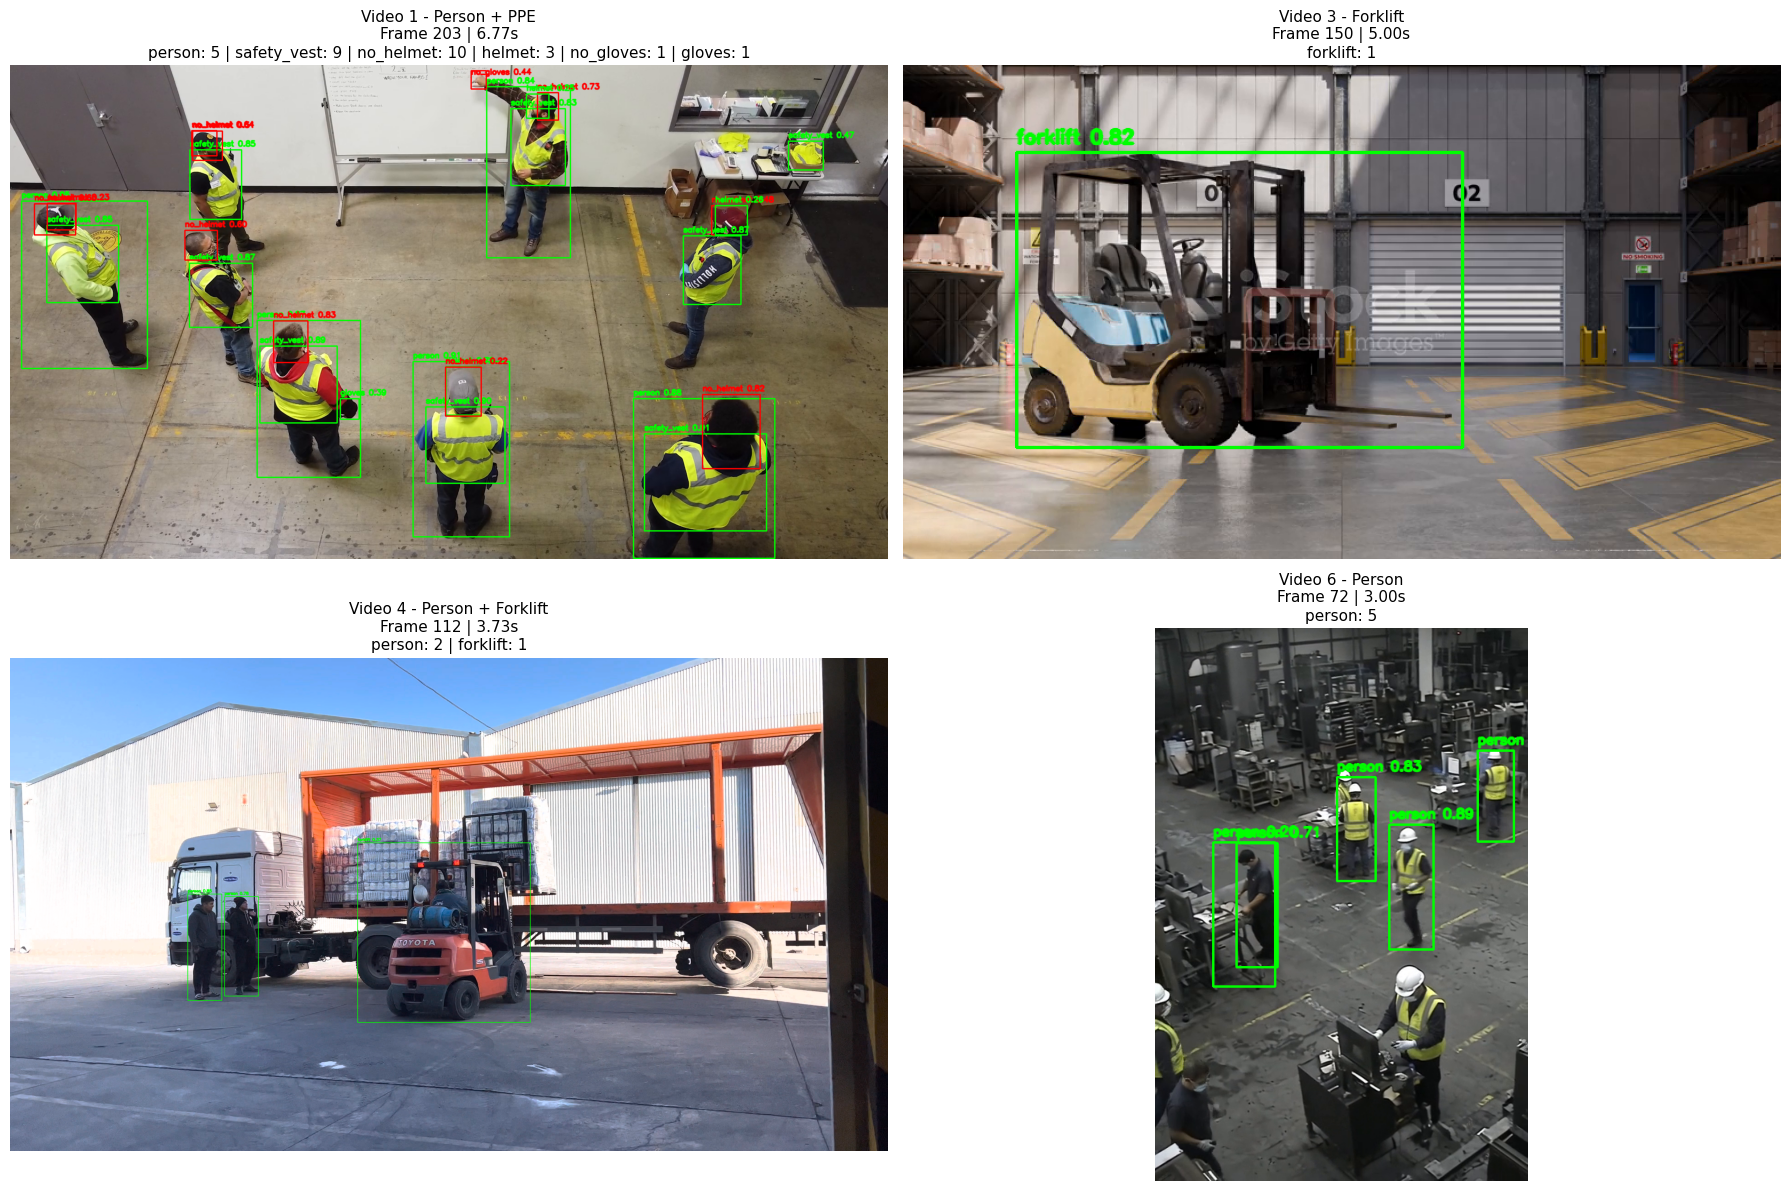


VISUAL DETECTION SUMMARY

Video 1 - Person + PPE
Video   : demo-video-1.mp4
Frame   : 203
Time    : 6.77s
Counts  : {'person': 5, 'safety_vest': 9, 'no_helmet': 10, 'helmet': 3, 'no_gloves': 1, 'gloves': 1}
Saved   : /kaggle/working/industrial_safety_engine/outputs/detection_previews/preview_1.jpg

Video 3 - Forklift
Video   : demo-video-3.mp4
Frame   : 150
Time    : 5.00s
Counts  : {'forklift': 1}
Saved   : /kaggle/working/industrial_safety_engine/outputs/detection_previews/preview_2.jpg

Video 4 - Person + Forklift
Video   : demo-video4.mp4
Frame   : 112
Time    : 3.73s
Counts  : {'person': 2, 'forklift': 1}
Saved   : /kaggle/working/industrial_safety_engine/outputs/detection_previews/preview_3.jpg

Video 6 - Person
Video   : demo-video-6.mp4
Frame   : 72
Time    : 3.00s
Counts  : {'person': 5}
Saved   : /kaggle/working/industrial_safety_engine/outputs/detection_previews/preview_4.jpg

✓ VISUAL SANITY CHECK COMPLETE


In [7]:
# ============================================================
# CELL 6: VISUAL DETECTION SANITY CHECK
# ============================================================

import cv2
import matplotlib.pyplot as plt
from collections import Counter


# ------------------------------------------------------------
# 1. Representative frames to inspect
# ------------------------------------------------------------

VISUAL_TESTS = [
    {
        "video_key": "video_1",
        "position": 0.50,
        "models": ["person", "helmet_vest", "gloves"],
        "title": "Video 1 - Person + PPE"
    },

    {
        "video_key": "video_3",
        "position": 0.50,
        "models": ["forklift"],
        "title": "Video 3 - Forklift"
    },

    {
        "video_key": "video_4",
        "position": 0.25,
        "models": ["person", "forklift"],
        "title": "Video 4 - Person + Forklift"
    },

    {
        "video_key": "video_6",
        "position": 0.50,
        "models": ["person"],
        "title": "Video 6 - Person"
    },
]


# ------------------------------------------------------------
# 2. Bounding-box drawing function
# ------------------------------------------------------------

def draw_detection(
    frame,
    box,
    label,
    confidence
):

    x1, y1, x2, y2 = [
        int(v) for v in box
    ]

    # Green for normal detections
    # Red for violation-related PPE classes
    if label in [
        "no_helmet",
        "no_safety_vest",
        "no_gloves"
    ]:
        color = (0, 0, 255)
    else:
        color = (0, 255, 0)

    cv2.rectangle(
        frame,
        (x1, y1),
        (x2, y2),
        color,
        2
    )

    text = f"{label} {confidence:.2f}"

    cv2.putText(
        frame,
        text,
        (x1, max(y1 - 8, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        color,
        2,
        cv2.LINE_AA
    )


# ------------------------------------------------------------
# 3. Run models and annotate frame
# ------------------------------------------------------------

def create_detection_preview(
    video_path,
    position,
    model_keys,
    confidence=0.20
):

    frame, frame_index, timestamp = (
        read_frame_at_position(
            video_path,
            position
        )
    )

    if frame is None:
        raise RuntimeError(
            f"Could not read frame from {video_path}"
        )

    annotated = frame.copy()

    detection_counts = Counter()

    for model_key in model_keys:

        model = models[model_key]

        allowed_classes = set(
            INFERENCE_CONFIG["models"]
            [model_key]
            ["allowed_classes"]
        )

        result = model.predict(
            source=frame,
            conf=confidence,
            imgsz=INFERENCE_CONFIG["imgsz"],
            device=DEVICE,
            verbose=False
        )[0]

        if result.boxes is None:
            continue

        for box in result.boxes:

            class_id = int(
                box.cls[0].item()
            )

            score = float(
                box.conf[0].item()
            )

            original_class = (
                model.names[class_id]
            )

            if original_class not in allowed_classes:
                continue

            unified_class = (
                MODEL_CLASS_TO_UNIFIED
                .get(model_key, {})
                .get(original_class)
            )

            if unified_class is None:
                continue

            xyxy = (
                box.xyxy[0]
                .cpu()
                .numpy()
            )

            draw_detection(
                annotated,
                xyxy,
                unified_class,
                score
            )

            detection_counts[
                unified_class
            ] += 1

    return (
        annotated,
        detection_counts,
        frame_index,
        timestamp
    )


# ------------------------------------------------------------
# 4. Create previews
# ------------------------------------------------------------

preview_results = []

for test in VISUAL_TESTS:

    video_path = (
        DEMO_VIDEOS[
            test["video_key"]
        ]
    )

    annotated, counts, frame_id, ts = (
        create_detection_preview(
            video_path=video_path,
            position=test["position"],
            model_keys=test["models"],
            confidence=DIAGNOSTIC_CONF
        )
    )

    preview_results.append({
        "title": test["title"],
        "video": video_path.name,
        "frame": frame_id,
        "time": ts,
        "image": annotated,
        "counts": counts
    })


# ------------------------------------------------------------
# 5. Display previews
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 12)
)

axes = axes.flatten()

for ax, item in zip(
    axes,
    preview_results
):

    image_rgb = cv2.cvtColor(
        item["image"],
        cv2.COLOR_BGR2RGB
    )

    ax.imshow(image_rgb)

    count_text = " | ".join(
        [
            f"{k}: {v}"
            for k, v in item["counts"].items()
        ]
    )

    ax.set_title(
        f"{item['title']}\n"
        f"Frame {item['frame']} | "
        f"{item['time']:.2f}s\n"
        f"{count_text}",
        fontsize=11
    )

    ax.axis("off")


plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Save annotated preview images
# ------------------------------------------------------------

PREVIEW_DIR = (
    DIRS["outputs"] /
    "detection_previews"
)

PREVIEW_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("\n" + "=" * 90)
print("VISUAL DETECTION SUMMARY")
print("=" * 90)

for i, item in enumerate(
    preview_results,
    start=1
):

    output_path = (
        PREVIEW_DIR /
        f"preview_{i}.jpg"
    )

    cv2.imwrite(
        str(output_path),
        item["image"]
    )

    print(
        f"\n{item['title']}"
    )

    print(
        f"Video   : {item['video']}"
    )

    print(
        f"Frame   : {item['frame']}"
    )

    print(
        f"Time    : {item['time']:.2f}s"
    )

    print(
        f"Counts  : {dict(item['counts'])}"
    )

    print(
        f"Saved   : {output_path}"
    )


print("\n" + "=" * 90)
print("✓ VISUAL SANITY CHECK COMPLETE")
print("=" * 90)

### Final Thresholds + Unified Detection Engine

In [8]:
# ============================================================
# CELL 7: FINAL THRESHOLDS & UNIFIED DETECTION ENGINE
# ============================================================

import cv2
import numpy as np
from collections import Counter


# ------------------------------------------------------------
# 1. Final class-specific confidence thresholds
# ------------------------------------------------------------
#
# These are based on the diagnostic + visual inspection.
#
# Person:
#   Strong detections across videos.
#
# Forklift:
#   0.30 keeps the genuine ~0.36 detection in video-4,
#   while video-3 forklift is already very strong (~0.82).
#
# PPE:
#   Higher thresholds reduce noisy detections.
#   PPE is supplementary, not core rule logic.
# ------------------------------------------------------------

CLASS_THRESHOLDS = {

    # Main analytics classes
    "person": 0.35,

    "forklift": 0.30,
    "stacker": 0.35,
    "truck": 0.35,
    "crane": 0.35,
    "container": 0.40,
    "ship": 0.40,

    # PPE
    "helmet": 0.45,
    "no_helmet": 0.50,

    "safety_vest": 0.50,
    "no_safety_vest": 0.50,

    "gloves": 0.40,
    "no_gloves": 0.45,
}


# ------------------------------------------------------------
# 2. Low model-level confidence
# ------------------------------------------------------------
#
# Models first return candidates from 0.20 onward.
# We then apply our class-specific threshold above.
# ------------------------------------------------------------

MODEL_BASE_CONF = 0.20


# ------------------------------------------------------------
# 3. Unified detection function
# ------------------------------------------------------------

def run_unified_detection(
    frame,
    model_keys,
    imgsz=None
):
    """
    Run one or more YOLO models on a frame and return
    detections in one common format.

    Returns:
        list of dictionaries:

        {
            "model": ...,
            "class_id": ...,
            "class_name": ...,
            "confidence": ...,
            "bbox": [x1, y1, x2, y2],
            "center": (cx, cy),
            "bottom_center": (bcx, bcy)
        }
    """

    if imgsz is None:
        imgsz = INFERENCE_CONFIG["imgsz"]

    detections = []

    for model_key in model_keys:

        model = models[model_key]

        allowed_classes = set(
            INFERENCE_CONFIG["models"]
            [model_key]
            ["allowed_classes"]
        )

        result = model.predict(
            source=frame,
            conf=MODEL_BASE_CONF,
            imgsz=imgsz,
            device=DEVICE,
            verbose=False
        )[0]

        if result.boxes is None:
            continue

        for box in result.boxes:

            class_id = int(
                box.cls[0].item()
            )

            confidence = float(
                box.conf[0].item()
            )

            original_class = (
                model.names[class_id]
            )

            # Ignore unwanted model classes
            if original_class not in allowed_classes:
                continue


            # Convert model-specific class name
            # into our unified class name
            unified_class = (
                MODEL_CLASS_TO_UNIFIED
                .get(model_key, {})
                .get(original_class)
            )

            if unified_class is None:
                continue


            # Apply class-specific threshold
            threshold = CLASS_THRESHOLDS.get(
                unified_class,
                0.35
            )

            if confidence < threshold:
                continue


            # Bounding box
            x1, y1, x2, y2 = (
                box.xyxy[0]
                .detach()
                .cpu()
                .numpy()
                .astype(float)
            )


            # Geometric reference points
            cx = (x1 + x2) / 2
            cy = (y1 + y2) / 2

            bottom_center_x = cx
            bottom_center_y = y2


            detection = {

                "model":
                    model_key,

                "class_id":
                    class_id,

                "class_name":
                    unified_class,

                "confidence":
                    confidence,

                "bbox": [
                    int(x1),
                    int(y1),
                    int(x2),
                    int(y2)
                ],

                "center": (
                    int(cx),
                    int(cy)
                ),

                "bottom_center": (
                    int(bottom_center_x),
                    int(bottom_center_y)
                ),
            }

            detections.append(
                detection
            )

    return detections


# ------------------------------------------------------------
# 4. Helper function to summarize detections
# ------------------------------------------------------------

def summarize_detections(detections):

    counts = Counter(
        detection["class_name"]
        for detection in detections
    )

    return dict(counts)


# ------------------------------------------------------------
# 5. Test unified detection engine
# ------------------------------------------------------------

TEST_CASES = [

    (
        "video_1",
        0.50,
        ["person", "helmet_vest", "gloves"]
    ),

    (
        "video_3",
        0.50,
        ["forklift"]
    ),

    (
        "video_4",
        0.25,
        ["person", "forklift"]
    ),

    (
        "video_6",
        0.50,
        ["person"]
    ),
]


print("=" * 90)
print("FINAL UNIFIED DETECTION TEST")
print("=" * 90)


for video_key, position, model_keys in TEST_CASES:

    video_path = DEMO_VIDEOS[
        video_key
    ]

    frame, frame_id, timestamp = (
        read_frame_at_position(
            video_path,
            position
        )
    )

    detections = (
        run_unified_detection(
            frame,
            model_keys
        )
    )

    counts = (
        summarize_detections(
            detections
        )
    )


    print(
        f"\n{video_path.name}"
    )

    print(
        f"Frame       : {frame_id}"
    )

    print(
        f"Time        : {timestamp:.2f}s"
    )

    print(
        f"Models      : {model_keys}"
    )

    print(
        f"Detections  : {counts}"
    )


print("\n" + "=" * 90)
print("FINAL CONFIDENCE THRESHOLDS")
print("=" * 90)

for class_name, threshold in CLASS_THRESHOLDS.items():

    print(
        f"{class_name:<20} "
        f": {threshold:.2f}"
    )


print("\n" + "=" * 90)
print("✓ UNIFIED DETECTION ENGINE READY")
print("=" * 90)

FINAL UNIFIED DETECTION TEST

demo-video-1.mp4
Frame       : 203
Time        : 6.77s
Models      : ['person', 'helmet_vest', 'gloves']
Detections  : {'person': 5, 'safety_vest': 8, 'no_helmet': 7, 'helmet': 1}

demo-video-3.mp4
Frame       : 150
Time        : 5.00s
Models      : ['forklift']
Detections  : {'forklift': 1}

demo-video4.mp4
Frame       : 112
Time        : 3.73s
Models      : ['person', 'forklift']
Detections  : {'person': 2, 'forklift': 1}

demo-video-6.mp4
Frame       : 72
Time        : 3.00s
Models      : ['person']
Detections  : {'person': 4}

FINAL CONFIDENCE THRESHOLDS
person               : 0.35
forklift             : 0.30
stacker              : 0.35
truck                : 0.35
crane                : 0.35
container            : 0.40
ship                 : 0.40
helmet               : 0.45
no_helmet            : 0.50
safety_vest          : 0.50
no_safety_vest       : 0.50
gloves               : 0.40
no_gloves            : 0.45

✓ UNIFIED DETECTION ENGINE READY


### ByteTrack Persistent Tracking

In [ ]:
# ============================================================
# CELL 8: BYTETRACK PERSISTENT TRACKING
# ============================================================

import cv2
import yaml
from pathlib import Path
from collections import defaultdict
from ultralytics import YOLO


# ------------------------------------------------------------
# 1. Portfolio ByteTrack configuration
# ------------------------------------------------------------

TRACKER_CONFIG_PATH = (
    DIRS["configs"] /
    "bytetrack_portfolio.yaml"
)

tracker_config = {
    "tracker_type": "bytetrack",

    # Detection association thresholds
    "track_high_thresh": 0.25,
    "track_low_thresh": 0.10,
    "new_track_thresh": 0.25,

    # Keep temporarily lost tracks alive
    "track_buffer": 60,

    # Association matching threshold
    "match_thresh": 0.80,

    "fuse_score": True,
}

with open(
    TRACKER_CONFIG_PATH,
    "w"
) as f:

    yaml.safe_dump(
        tracker_config,
        f,
        sort_keys=False
    )


print("=" * 90)
print("BYTETRACK CONFIGURATION")
print("=" * 90)

for key, value in tracker_config.items():
    print(
        f"{key:<20}: {value}"
    )

print(
    f"\nSaved to: {TRACKER_CONFIG_PATH}"
)


# ------------------------------------------------------------
# 2. Helper:
#    unified class names -> original model class IDs
# ------------------------------------------------------------

def get_tracking_class_ids(
    model_key,
    unified_classes
):

    model = models[model_key]

    required_original_names = []

    for unified_class in unified_classes:

        info = CLASS_REGISTRY[
            unified_class
        ]

        if info["model"] != model_key:
            continue

        required_original_names.append(
            info["model_class_name"]
        )

    class_ids = []

    for class_id, class_name in model.names.items():

        if class_name in required_original_names:
            class_ids.append(
                int(class_id)
            )

    return class_ids


# ------------------------------------------------------------
# 3. Convert Ultralytics tracking result
#    into our unified tracking format
# ------------------------------------------------------------

def extract_tracked_objects(
    result,
    model_key
):

    tracked_objects = []

    if result.boxes is None:
        return tracked_objects

    # No IDs = ByteTrack has not assigned tracks yet
    if result.boxes.id is None:
        return tracked_objects


    boxes_xyxy = (
        result.boxes.xyxy
        .detach()
        .cpu()
        .numpy()
    )

    class_ids = (
        result.boxes.cls
        .detach()
        .cpu()
        .numpy()
        .astype(int)
    )

    confidences = (
        result.boxes.conf
        .detach()
        .cpu()
        .numpy()
    )

    track_ids = (
        result.boxes.id
        .detach()
        .cpu()
        .numpy()
        .astype(int)
    )


    for bbox, class_id, confidence, track_id in zip(
        boxes_xyxy,
        class_ids,
        confidences,
        track_ids
    ):

        original_class = (
            result.names[
                int(class_id)
            ]
        )

        unified_class = (
            MODEL_CLASS_TO_UNIFIED
            .get(model_key, {})
            .get(original_class)
        )

        if unified_class is None:
            continue


        # Apply our final class threshold
        threshold = (
            CLASS_THRESHOLDS
            .get(
                unified_class,
                0.35
            )
        )

        if confidence < threshold:
            continue


        x1, y1, x2, y2 = bbox

        cx = (
            x1 + x2
        ) / 2

        cy = (
            y1 + y2
        ) / 2


        tracked_objects.append({

            "track_id":
                int(track_id),

            "class_name":
                unified_class,

            "confidence":
                float(confidence),

            "bbox": [
                int(x1),
                int(y1),
                int(x2),
                int(y2)
            ],

            "center": (
                int(cx),
                int(cy)
            ),

            # Important for ROI logic:
            # approximate physical ground position
            "bottom_center": (
                int(cx),
                int(y2)
            ),
        })


    return tracked_objects


# ------------------------------------------------------------
# 4. Tracking diagnostic for a complete video
# ------------------------------------------------------------

def run_tracking_diagnostic(
    video_key,
    model_key,
    target_classes
):

    video_path = (
        DEMO_VIDEOS[
            video_key
        ]
    )

    print("\n" + "=" * 90)
    print(
        f"TRACKING: {video_path.name}"
    )
    print("=" * 90)


    # --------------------------------------------------------
    # IMPORTANT:
    # Fresh YOLO instance = fresh ByteTrack state.
    #
    # This prevents track IDs from one demo video leaking
    # into another video.
    # --------------------------------------------------------

    tracker_model = YOLO(
        str(
            model_paths[
                model_key
            ]
        )
    )


    tracking_class_ids = (
        get_tracking_class_ids(
            model_key,
            target_classes
        )
    )


    print(
        f"Model          : {model_key}"
    )

    print(
        f"Target classes : {target_classes}"
    )

    print(
        f"YOLO class IDs : {tracking_class_ids}"
    )


    # --------------------------------------------------------
    # Video
    # --------------------------------------------------------

    cap = cv2.VideoCapture(
        str(video_path)
    )

    if not cap.isOpened():

        raise RuntimeError(
            f"Could not open: {video_path}"
        )


    fps = cap.get(
        cv2.CAP_PROP_FPS
    )

    total_frames = int(
        cap.get(
            cv2.CAP_PROP_FRAME_COUNT
        )
    )


    # --------------------------------------------------------
    # Track statistics
    # --------------------------------------------------------

    track_history = defaultdict(
        lambda: {
            "class_name": None,
            "first_frame": None,
            "last_frame": None,
            "frames_seen": 0,
            "max_confidence": 0.0,
        }
    )


    frame_index = 0


    while True:

        success, frame = cap.read()

        if not success:
            break


        # ----------------------------------------------------
        # ByteTrack inference
        # ----------------------------------------------------

        result = tracker_model.track(
            source=frame,

            persist=True,

            tracker=str(
                TRACKER_CONFIG_PATH
            ),

            conf=MODEL_BASE_CONF,

            imgsz=INFERENCE_CONFIG[
                "imgsz"
            ],

            device=DEVICE,

            classes=tracking_class_ids,

            verbose=False
        )[0]


        tracked_objects = (
            extract_tracked_objects(
                result,
                model_key
            )
        )


        # ----------------------------------------------------
        # Save statistics
        # ----------------------------------------------------

        for obj in tracked_objects:

            key = (
                obj["class_name"],
                obj["track_id"]
            )

            record = (
                track_history[
                    key
                ]
            )


            record[
                "class_name"
            ] = obj[
                "class_name"
            ]


            if (
                record[
                    "first_frame"
                ]
                is None
            ):
                record[
                    "first_frame"
                ] = frame_index


            record[
                "last_frame"
            ] = frame_index


            record[
                "frames_seen"
            ] += 1


            record[
                "max_confidence"
            ] = max(
                record[
                    "max_confidence"
                ],
                obj[
                    "confidence"
                ]
            )


        frame_index += 1


    cap.release()


    # --------------------------------------------------------
    # Print statistics
    # --------------------------------------------------------

    print(
        f"\nProcessed frames : "
        f"{frame_index}/{total_frames}"
    )

    print(
        f"Video FPS        : "
        f"{fps:.2f}"
    )


    if len(track_history) == 0:

        print(
            "\n❌ No persistent tracks generated."
        )

        return {}


    print("\nTRACK SUMMARY")
    print("-" * 90)


    sorted_tracks = sorted(
        track_history.items(),
        key=lambda x: x[1][
            "frames_seen"
        ],
        reverse=True
    )


    for (
        class_name,
        track_id
    ), info in sorted_tracks:

        duration_sec = (
            info["frames_seen"] /
            fps
            if fps > 0
            else 0
        )

        print(
            f"{class_name:<12} "
            f"ID={track_id:<4} | "
            f"frames={info['frames_seen']:<4} | "
            f"duration≈{duration_sec:>5.2f}s | "
            f"first={info['first_frame']:<4} | "
            f"last={info['last_frame']:<4} | "
            f"max_conf={info['max_confidence']:.2f}"
        )


    unique_ids = defaultdict(
        set
    )

    for (
        class_name,
        track_id
    ) in track_history.keys():

        unique_ids[
            class_name
        ].add(
            track_id
        )


    print("\nUNIQUE TRACKS")
    print("-" * 90)

    for class_name, ids in unique_ids.items():

        print(
            f"{class_name:<12}: "
            f"{len(ids)} unique IDs "
            f"{sorted(ids)}"
        )


    return dict(
        track_history
    )


# ------------------------------------------------------------
# 5. Test tracking on our three core rule videos
# ------------------------------------------------------------

TRACKING_DIAGNOSTICS = {}


# Restricted Zone
TRACKING_DIAGNOSTICS[
    "restricted_zone"
] = run_tracking_diagnostic(
    video_key="video_6",
    model_key="person",
    target_classes=[
        "person"
    ]
)


# Wrong MHE Parking
TRACKING_DIAGNOSTICS[
    "wrong_mhe_parking"
] = run_tracking_diagnostic(
    video_key="video_3",
    model_key="forklift",
    target_classes=[
        "forklift"
    ]
)


# Directional Line Crossing
TRACKING_DIAGNOSTICS[
    "line_crossing"
] = run_tracking_diagnostic(
    video_key="video_4",
    model_key="person",
    target_classes=[
        "person"
    ]
)


print("\n" + "=" * 90)
print("✓ PERSISTENT TRACKING DIAGNOSTIC COMPLETE")
print("=" * 90)

BYTETRACK CONFIGURATION
tracker_type        : bytetrack
track_high_thresh   : 0.25
track_low_thresh    : 0.1
new_track_thresh    : 0.25
track_buffer        : 60
match_thresh        : 0.8
fuse_score          : True

Saved to: /kaggle/working/industrial_safety_engine/configs/bytetrack_portfolio.yaml

TRACKING: demo-video-6.mp4
Model          : person
Target classes : ['person']
YOLO class IDs : [0]
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 339ms
Prepared 1 package in 102ms
Installed 1 package in 7ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


Processed frames : 145/145
Video FPS        : 24.00

TRACK SUMMARY
------------------------------------------------------------------------------------------
person       ID=6    | frames=112  | duration≈ 4.67s | first=25   | last=144  | max

### Visualize Person Trajectories + Coordinate Grid

In [ ]:
# ============================================================
# CELL 9: PERSON TRAJECTORIES & ROI DESIGN VIEW
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from ultralytics import YOLO


# ------------------------------------------------------------
# 1. Use video-4 for spatial rules
# ------------------------------------------------------------

SPATIAL_RULE_VIDEO = DEMO_VIDEOS["video_4"]


# ------------------------------------------------------------
# 2. Fresh person tracker
# ------------------------------------------------------------

trajectory_model = YOLO(
    str(model_paths["person"])
)


# ------------------------------------------------------------
# 3. Video information
# ------------------------------------------------------------

cap = cv2.VideoCapture(
    str(SPATIAL_RULE_VIDEO)
)

if not cap.isOpened():
    raise RuntimeError(
        f"Could not open {SPATIAL_RULE_VIDEO}"
    )

fps = cap.get(
    cv2.CAP_PROP_FPS
)

total_frames = int(
    cap.get(
        cv2.CAP_PROP_FRAME_COUNT
    )
)

width = int(
    cap.get(
        cv2.CAP_PROP_FRAME_WIDTH
    )
)

height = int(
    cap.get(
        cv2.CAP_PROP_FRAME_HEIGHT
    )
)


# ------------------------------------------------------------
# 4. Store trajectories
# ------------------------------------------------------------

track_points = defaultdict(list)

track_frame_counts = defaultdict(int)

reference_frame = None

frame_index = 0


# ------------------------------------------------------------
# 5. Track entire video
# ------------------------------------------------------------

while True:

    success, frame = cap.read()

    if not success:
        break


    # Keep a representative frame
    # around middle of video
    if frame_index == total_frames // 2:
        reference_frame = frame.copy()


    result = trajectory_model.track(

        source=frame,

        persist=True,

        tracker=str(
            TRACKER_CONFIG_PATH
        ),

        conf=0.20,

        imgsz=INFERENCE_CONFIG[
            "imgsz"
        ],

        device=DEVICE,

        classes=[0],  # person only

        verbose=False
    )[0]


    tracked_objects = extract_tracked_objects(
        result,
        "person"
    )


    for obj in tracked_objects:

        track_id = obj[
            "track_id"
        ]

        point = obj[
            "bottom_center"
        ]

        track_points[
            track_id
        ].append(
            point
        )

        track_frame_counts[
            track_id
        ] += 1


    frame_index += 1


cap.release()


# ------------------------------------------------------------
# 6. Fallback reference frame
# ------------------------------------------------------------

if reference_frame is None:

    reference_frame, _, _ = (
        read_frame_at_position(
            SPATIAL_RULE_VIDEO,
            0.50
        )
    )


# ------------------------------------------------------------
# 7. Draw trajectories
# ------------------------------------------------------------

trajectory_view = (
    reference_frame.copy()
)


# Only show reasonably stable tracks
MIN_TRACK_FRAMES = 30


stable_tracks = {
    track_id: points

    for track_id, points
    in track_points.items()

    if track_frame_counts[
        track_id
    ] >= MIN_TRACK_FRAMES
}


for track_id, points in stable_tracks.items():

    if len(points) < 2:
        continue


    # Draw trajectory
    for i in range(
        1,
        len(points)
    ):

        cv2.line(
            trajectory_view,

            points[i - 1],
            points[i],

            (0, 255, 255),

            4
        )


    # Start point
    cv2.circle(
        trajectory_view,
        points[0],
        12,
        (0, 255, 0),
        -1
    )


    # End point
    cv2.circle(
        trajectory_view,
        points[-1],
        12,
        (0, 0, 255),
        -1
    )


    # Track label
    middle_point = (
        points[
            len(points) // 2
        ]
    )

    cv2.putText(
        trajectory_view,

        f"ID {track_id}",

        (
            middle_point[0] + 10,
            middle_point[1] - 10
        ),

        cv2.FONT_HERSHEY_SIMPLEX,

        1.1,

        (255, 255, 0),

        3,

        cv2.LINE_AA
    )


# ------------------------------------------------------------
# 8. Draw coordinate grid
# ------------------------------------------------------------

GRID_X = 400
GRID_Y = 300


# Vertical grid
for x in range(
    0,
    width,
    GRID_X
):

    cv2.line(
        trajectory_view,
        (x, 0),
        (x, height),
        (180, 180, 180),
        1
    )

    cv2.putText(
        trajectory_view,
        f"x={x}",
        (x + 10, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2
    )


# Horizontal grid
for y in range(
    0,
    height,
    GRID_Y
):

    cv2.line(
        trajectory_view,
        (0, y),
        (width, y),
        (180, 180, 180),
        1
    )

    cv2.putText(
        trajectory_view,
        f"y={y}",
        (15, y + 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2
    )


# ------------------------------------------------------------
# 9. Save result
# ------------------------------------------------------------

trajectory_output = (
    DIRS["outputs"] /
    "video4_person_trajectories.jpg"
)

cv2.imwrite(
    str(trajectory_output),
    trajectory_view
)


# ------------------------------------------------------------
# 10. Print track statistics
# ------------------------------------------------------------

print("=" * 90)
print("STABLE PERSON TRAJECTORIES")
print("=" * 90)

print(
    f"Video      : {SPATIAL_RULE_VIDEO.name}"
)

print(
    f"Resolution : {width} x {height}"
)

print(
    f"FPS        : {fps:.2f}"
)

print(
    f"Frames     : {total_frames}"
)

print(
    f"\nStable track threshold: "
    f"{MIN_TRACK_FRAMES} frames"
)

print("\nTracks:")

for track_id in sorted(
    stable_tracks.keys()
):

    points = stable_tracks[
        track_id
    ]

    start = points[0]
    end = points[-1]

    print(
        f"ID {track_id:<4} | "
        f"frames={track_frame_counts[track_id]:<4} | "
        f"start={start} | "
        f"end={end}"
    )


print(
    f"\nSaved: {trajectory_output}"
)


# ------------------------------------------------------------
# 11. Display
# ------------------------------------------------------------

plt.figure(
    figsize=(20, 11)
)

plt.imshow(
    cv2.cvtColor(
        trajectory_view,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Video 4 - Person Trajectories & Coordinate Grid\n"
    "Green = Start | Red = End",
    fontsize=15
)

plt.axis("off")

plt.show()

### Restricted Zone Intrusion Rule

In [ ]:
# ============================================================
# CELL 10: PERSON RESTRICTED ZONE INTRUSION - FINAL VERSION
# Active + Total Violations
# High-Contrast Labels
# H.264 Portfolio Output
# ============================================================

import cv2
import numpy as np
import pandas as pd
import subprocess
import shutil

from pathlib import Path
from collections import defaultdict
from ultralytics import YOLO


# ------------------------------------------------------------
# 1. Video
# ------------------------------------------------------------

RESTRICTED_VIDEO = DEMO_VIDEOS["video_4"]


# ------------------------------------------------------------
# 2. Person restricted-zone polygon
# ------------------------------------------------------------

RESTRICTED_ZONE = np.array([
    [0,    1260],
    [1150, 1260],
    [1450, 1540],
    [1180, 1820],
    [0,    1820]
], dtype=np.int32)


# ------------------------------------------------------------
# 3. Rule settings
# ------------------------------------------------------------

MIN_INTRUSION_SECONDS = 1.0

RULE_NAME = "Restricted Zone Intrusion"


# ------------------------------------------------------------
# 4. Output paths
# ------------------------------------------------------------

RESTRICTED_RAW_VIDEO = (
    DIRS["videos"] /
    "restricted_zone_intrusion_raw.mp4"
)

RESTRICTED_OUTPUT_VIDEO = (
    DIRS["videos"] /
    "restricted_zone_intrusion_demo.mp4"
)

RESTRICTED_EVENT_LOG = (
    DIRS["logs"] /
    "restricted_zone_events.csv"
)

RESTRICTED_ALERT_DIR = (
    DIRS["alerts"] /
    "restricted_zone"
)

RESTRICTED_ALERT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 5. Helper: point inside polygon
# ------------------------------------------------------------

def point_inside_roi(point, polygon):

    result = cv2.pointPolygonTest(
        polygon,
        (
            float(point[0]),
            float(point[1])
        ),
        False
    )

    return result >= 0


# ------------------------------------------------------------
# 6. Helper: high-contrast label
# ------------------------------------------------------------

def draw_high_contrast_label(
    frame,
    text,
    x,
    y,
    font_scale=1.0,
    thickness=3
):
    """
    White text on black background for better visibility.
    """

    font = cv2.FONT_HERSHEY_SIMPLEX

    (text_w, text_h), baseline = cv2.getTextSize(
        text,
        font,
        font_scale,
        thickness
    )

    frame_h, frame_w = frame.shape[:2]

    pad_x = 15
    pad_y = 12

    # Prevent label going outside frame
    x = max(
        0,
        min(
            int(x),
            frame_w - text_w - (2 * pad_x)
        )
    )

    y = max(
        text_h + (2 * pad_y),
        int(y)
    )

    top_left = (
        x,
        y - text_h - (2 * pad_y)
    )

    bottom_right = (
        x + text_w + (2 * pad_x),
        y + baseline
    )

    # Black background
    cv2.rectangle(
        frame,
        top_left,
        bottom_right,
        (0, 0, 0),
        -1
    )

    # White text
    cv2.putText(
        frame,
        text,
        (
            x + pad_x,
            y - pad_y
        ),
        font,
        font_scale,
        (255, 255, 255),
        thickness,
        cv2.LINE_AA
    )


# ------------------------------------------------------------
# 7. Fresh person tracker
# ------------------------------------------------------------

restricted_tracker = YOLO(
    str(model_paths["person"])
)


# ------------------------------------------------------------
# 8. Open video
# ------------------------------------------------------------

cap = cv2.VideoCapture(
    str(RESTRICTED_VIDEO)
)

if not cap.isOpened():

    raise RuntimeError(
        f"Could not open {RESTRICTED_VIDEO}"
    )


fps = cap.get(
    cv2.CAP_PROP_FPS
)

width = int(
    cap.get(
        cv2.CAP_PROP_FRAME_WIDTH
    )
)

height = int(
    cap.get(
        cv2.CAP_PROP_FRAME_HEIGHT
    )
)

total_frames = int(
    cap.get(
        cv2.CAP_PROP_FRAME_COUNT
    )
)


MIN_INTRUSION_FRAMES = max(
    1,
    int(
        round(
            MIN_INTRUSION_SECONDS * fps
        )
    )
)


# ------------------------------------------------------------
# 9. Portfolio output resolution
# ------------------------------------------------------------

OUTPUT_WIDTH = 1920
OUTPUT_HEIGHT = 1080


fourcc = cv2.VideoWriter_fourcc(
    *"mp4v"
)

writer = cv2.VideoWriter(
    str(RESTRICTED_RAW_VIDEO),
    fourcc,
    fps,
    (
        OUTPUT_WIDTH,
        OUTPUT_HEIGHT
    )
)


# ------------------------------------------------------------
# 10. Per-track rule state
# ------------------------------------------------------------

track_state = defaultdict(
    lambda: {

        "inside_frames": 0,

        "was_inside": False,

        "violation_active": False,

        "alert_generated": False,

        "entry_frame": None,
    }
)


# ------------------------------------------------------------
# 11. Event storage
# ------------------------------------------------------------

event_records = []

frame_index = 0

unique_person_ids = set()

violating_ids = set()


print("=" * 95)
print("PERSON RESTRICTED ZONE INTRUSION RULE")
print("=" * 95)

print(
    f"Video               : {RESTRICTED_VIDEO.name}"
)

print(
    f"Resolution          : {width} x {height}"
)

print(
    f"FPS                 : {fps:.2f}"
)

print(
    f"Frames              : {total_frames}"
)

print(
    f"Persistence         : "
    f"{MIN_INTRUSION_SECONDS:.1f}s "
    f"({MIN_INTRUSION_FRAMES} frames)"
)

print(
    f"Final Output        : "
    f"{RESTRICTED_OUTPUT_VIDEO}"
)


# ------------------------------------------------------------
# 12. Process video
# ------------------------------------------------------------

while True:

    success, frame = cap.read()

    if not success:
        break


    # --------------------------------------------------------
    # Person tracking
    # --------------------------------------------------------

    result = restricted_tracker.track(
        source=frame,

        persist=True,

        tracker=str(
            TRACKER_CONFIG_PATH
        ),

        conf=MODEL_BASE_CONF,

        imgsz=INFERENCE_CONFIG[
            "imgsz"
        ],

        device=DEVICE,

        classes=[0],

        verbose=False

    )[0]


    tracked_people = (
        extract_tracked_objects(
            result,
            "person"
        )
    )


    # --------------------------------------------------------
    # Restricted-zone overlay
    # --------------------------------------------------------

    overlay = frame.copy()

    cv2.fillPoly(
        overlay,
        [RESTRICTED_ZONE],
        (0, 0, 255)
    )

    frame = cv2.addWeighted(
        overlay,
        0.18,
        frame,
        0.82,
        0
    )

    cv2.polylines(
        frame,
        [RESTRICTED_ZONE],
        True,
        (0, 0, 255),
        8
    )


    # --------------------------------------------------------
    # High-contrast ROI label
    # --------------------------------------------------------

    draw_high_contrast_label(
        frame,
        "PERSON RESTRICTED ZONE",
        40,
        1220,
        font_scale=1.25,
        thickness=3
    )


    # --------------------------------------------------------
    # Process every tracked person
    # --------------------------------------------------------

    active_track_ids = set()


    for person in tracked_people:

        track_id = person[
            "track_id"
        ]

        confidence = person[
            "confidence"
        ]

        x1, y1, x2, y2 = person[
            "bbox"
        ]

        bottom_center = person[
            "bottom_center"
        ]


        unique_person_ids.add(
            track_id
        )

        active_track_ids.add(
            track_id
        )


        # ----------------------------------------------------
        # ROI membership
        # ----------------------------------------------------

        inside = point_inside_roi(
            bottom_center,
            RESTRICTED_ZONE
        )


        state = track_state[
            track_id
        ]


        # ----------------------------------------------------
        # Entered / remains inside
        # ----------------------------------------------------

        if inside:

            if not state[
                "was_inside"
            ]:

                state[
                    "entry_frame"
                ] = frame_index

                state[
                    "inside_frames"
                ] = 1

            else:

                state[
                    "inside_frames"
                ] += 1


            state[
                "was_inside"
            ] = True


        # ----------------------------------------------------
        # Outside ROI
        # ----------------------------------------------------

        else:

            state[
                "inside_frames"
            ] = 0

            state[
                "entry_frame"
            ] = None

            state[
                "violation_active"
            ] = False

            state[
                "alert_generated"
            ] = False

            state[
                "was_inside"
            ] = False


        # ----------------------------------------------------
        # Time inside ROI
        # ----------------------------------------------------

        inside_duration = (
            state[
                "inside_frames"
            ] / fps
        )


        # ----------------------------------------------------
        # Confirm violation
        # ----------------------------------------------------

        if (
            inside
            and
            state[
                "inside_frames"
            ] >= MIN_INTRUSION_FRAMES
        ):

            state[
                "violation_active"
            ] = True

            violating_ids.add(
                track_id
            )


        # ----------------------------------------------------
        # Generate ONE event per continuous intrusion
        # ----------------------------------------------------

        generated_now = False

        snapshot_path = None


        if (
            state[
                "violation_active"
            ]
            and
            not state[
                "alert_generated"
            ]
        ):

            event_time_sec = (
                frame_index / fps
            )

            event_id = (
                f"RZI_"
                f"{frame_index:06d}_"
                f"ID{track_id}"
            )


            snapshot_path = (
                RESTRICTED_ALERT_DIR /
                f"{event_id}.jpg"
            )


            event_records.append({

                "event_id":
                    event_id,

                "rule":
                    RULE_NAME,

                "video":
                    RESTRICTED_VIDEO.name,

                "frame":
                    frame_index,

                "timestamp_sec":
                    round(
                        event_time_sec,
                        2
                    ),

                "track_id":
                    track_id,

                "class":
                    "person",

                "confidence":
                    round(
                        confidence,
                        3
                    ),

                "inside_duration_sec":
                    round(
                        inside_duration,
                        2
                    ),

                "snapshot":
                    str(
                        snapshot_path
                    )
            })


            state[
                "alert_generated"
            ] = True

            generated_now = True


        # ----------------------------------------------------
        # Bounding-box state
        # ----------------------------------------------------

        if state[
            "violation_active"
        ]:

            box_color = (
                0,
                0,
                255
            )

            status_text = (
                f"VIOLATION | "
                f"Person #{track_id} | "
                f"{inside_duration:.1f}s"
            )


        elif inside:

            box_color = (
                0,
                165,
                255
            )

            status_text = (
                f"INSIDE ROI | "
                f"Person #{track_id} | "
                f"{inside_duration:.1f}s"
            )


        else:

            box_color = (
                0,
                255,
                0
            )

            status_text = (
                f"Person #{track_id}"
            )


        # ----------------------------------------------------
        # Draw bbox
        # ----------------------------------------------------

        cv2.rectangle(
            frame,
            (x1, y1),
            (x2, y2),
            box_color,
            6
        )


        # Ground reference / bottom-center
        cv2.circle(
            frame,
            bottom_center,
            10,
            box_color,
            -1
        )


        # ----------------------------------------------------
        # High-contrast object label
        # ----------------------------------------------------

        draw_high_contrast_label(
            frame,
            status_text,
            x1,
            max(
                y1 - 15,
                80
            ),
            font_scale=1.0,
            thickness=3
        )


        # ----------------------------------------------------
        # Save alert snapshot
        # ----------------------------------------------------

        if (
            generated_now
            and
            snapshot_path is not None
        ):

            cv2.imwrite(
                str(snapshot_path),
                frame
            )


    # --------------------------------------------------------
    # ACTIVE + TOTAL VIOLATIONS
    # --------------------------------------------------------

    current_violations = sum(

        1

        for track_id
        in active_track_ids

        if track_state[
            track_id
        ][
            "violation_active"
        ]
    )


    # Cumulative confirmed events
    total_violations = len(
        event_records
    )


    # --------------------------------------------------------
    # Analytics status panel
    # --------------------------------------------------------

    panel_text = (
        "Person Restricted Zone  |  "
        f"Active Violations: {current_violations}  |  "
        f"Total Violations: {total_violations}"
    )


    cv2.rectangle(
        frame,
        (30, 35),
        (1750, 135),
        (0, 0, 0),
        -1
    )


    cv2.putText(
        frame,
        panel_text,
        (55, 100),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.35,
        (255, 255, 255),
        4,
        cv2.LINE_AA
    )


    # --------------------------------------------------------
    # Resize for portfolio output
    # --------------------------------------------------------

    output_frame = cv2.resize(
        frame,
        (
            OUTPUT_WIDTH,
            OUTPUT_HEIGHT
        ),
        interpolation=cv2.INTER_AREA
    )


    writer.write(
        output_frame
    )


    frame_index += 1


# ------------------------------------------------------------
# 13. Release resources
# ------------------------------------------------------------

cap.release()

writer.release()


# ------------------------------------------------------------
# 14. Save event CSV
# ------------------------------------------------------------

events_df = pd.DataFrame(
    event_records
)

events_df.to_csv(
    RESTRICTED_EVENT_LOG,
    index=False
)


# ------------------------------------------------------------
# 15. Convert MP4V → H.264
# ------------------------------------------------------------

print(
    "\nEncoding final portfolio video to H.264..."
)


ffmpeg_command = [

    "ffmpeg",
    "-y",

    "-loglevel",
    "error",

    "-i",
    str(
        RESTRICTED_RAW_VIDEO
    ),

    "-c:v",
    "libx264",

    "-preset",
    "medium",

    "-crf",
    "22",

    "-pix_fmt",
    "yuv420p",

    "-movflags",
    "+faststart",

    str(
        RESTRICTED_OUTPUT_VIDEO
    )
]


encoding_result = subprocess.run(
    ffmpeg_command,
    capture_output=True,
    text=True
)


if (
    encoding_result.returncode == 0
    and
    RESTRICTED_OUTPUT_VIDEO.exists()
):

    print(
        "✓ H.264 encoding successful."
    )

    try:

        RESTRICTED_RAW_VIDEO.unlink()

    except:

        pass


else:

    print(
        "⚠ H.264 encoding failed. "
        "Using original MP4V output."
    )

    print(
        encoding_result.stderr[
            -1000:
        ]
    )

    shutil.copy2(
        RESTRICTED_RAW_VIDEO,
        RESTRICTED_OUTPUT_VIDEO
    )


# ------------------------------------------------------------
# 16. Final report
# ------------------------------------------------------------

print("\n" + "=" * 95)
print("PERSON RESTRICTED ZONE RESULT")
print("=" * 95)


print(
    f"Processed Frames        : "
    f"{frame_index}"
)


print(
    f"Unique Person Track IDs : "
    f"{len(unique_person_ids)}"
)


print(
    f"Violation Track IDs     : "
    f"{sorted(violating_ids)}"
)


print(
    f"Total Violations        : "
    f"{len(event_records)}"
)


print(
    f"Generated Alerts        : "
    f"{len(event_records)}"
)


print(
    f"Output Video            : "
    f"{RESTRICTED_OUTPUT_VIDEO}"
)


print(
    f"Event Log               : "
    f"{RESTRICTED_EVENT_LOG}"
)


print(
    f"Alert Snapshots         : "
    f"{RESTRICTED_ALERT_DIR}"
)


# ------------------------------------------------------------
# 17. Print events
# ------------------------------------------------------------

if len(events_df) > 0:

    print("\nEVENTS")
    print("-" * 95)

    print(
        events_df[
            [
                "event_id",
                "timestamp_sec",
                "track_id",
                "confidence",
                "inside_duration_sec"
            ]
        ].to_string(
            index=False
        )
    )


else:

    print(
        "\n⚠ No intrusion remained inside "
        "the ROI long enough to trigger."
    )


print("\n" + "=" * 95)
print("✓ PERSON RESTRICTED ZONE RULE COMPLETE")
print("=" * 95)

### Forklift ROI Visual Validation

In [ ]:
# ============================================================
# CELL 10B: FORKLIFT RESTRICTED-ZONE ROI VISUALIZATION
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Forklift / MHE restricted zone
# ------------------------------------------------------------

FORKLIFT_RESTRICTED_ZONE = np.array([
    [1850, 1100],
    [2850, 1100],
    [3050, 1800],
    [1650, 1800],
], dtype=np.int32)


# ------------------------------------------------------------
# 2. Representative frames
# ------------------------------------------------------------

PREVIEW_FRAMES = [
    0,
    60,
    120,
    240,
    360
]


cap = cv2.VideoCapture(
    str(DEMO_VIDEOS["video_4"])
)

preview_images = []


for frame_id in PREVIEW_FRAMES:

    cap.set(
        cv2.CAP_PROP_POS_FRAMES,
        frame_id
    )

    success, frame = cap.read()

    if not success:
        continue


    # --------------------------------------------------------
    # Person restricted ROI - RED
    # --------------------------------------------------------

    person_overlay = frame.copy()

    cv2.fillPoly(
        person_overlay,
        [RESTRICTED_ZONE],
        (0, 0, 255)
    )

    frame = cv2.addWeighted(
        person_overlay,
        0.12,
        frame,
        0.88,
        0
    )

    cv2.polylines(
        frame,
        [RESTRICTED_ZONE],
        True,
        (0, 0, 255),
        7
    )


    # --------------------------------------------------------
    # Forklift restricted ROI - MAGENTA
    # --------------------------------------------------------

    forklift_overlay = frame.copy()

    cv2.fillPoly(
        forklift_overlay,
        [FORKLIFT_RESTRICTED_ZONE],
        (255, 0, 255)
    )

    frame = cv2.addWeighted(
        forklift_overlay,
        0.18,
        frame,
        0.82,
        0
    )

    cv2.polylines(
        frame,
        [FORKLIFT_RESTRICTED_ZONE],
        True,
        (255, 0, 255),
        7
    )


    # --------------------------------------------------------
    # Labels
    # --------------------------------------------------------

    cv2.putText(
        frame,
        "PERSON RESTRICTED ZONE",
        (50, 1210),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.3,
        (0, 0, 255),
        4,
        cv2.LINE_AA
    )


    cv2.putText(
        frame,
        "FORKLIFT RESTRICTED ZONE",
        (1850, 1050),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.3,
        (255, 0, 255),
        4,
        cv2.LINE_AA
    )


    # Frame information
    cv2.putText(
        frame,
        f"Frame {frame_id} | {frame_id / 30:.1f}s",
        (50, 80),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.3,
        (255, 255, 255),
        4,
        cv2.LINE_AA
    )


    preview_images.append(
        (
            frame_id,
            frame
        )
    )


cap.release()


# ------------------------------------------------------------
# 3. Display one image per row
# ------------------------------------------------------------

for frame_id, image in preview_images:

    plt.figure(
        figsize=(18, 10)
    )

    plt.imshow(
        cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )
    )

    plt.title(
        f"Frame {frame_id} - Dual Restricted-Zone Configuration\n"
        f"Red = Person Restricted Zone | "
        f"Magenta = Forklift Restricted Zone",
        fontsize=14
    )

    plt.axis("off")
    plt.show()


print("=" * 90)
print("RESTRICTED ZONE CONFIGURATION")
print("=" * 90)

print("\nPERSON ROI:")
print(RESTRICTED_ZONE.tolist())

print("\nFORKLIFT ROI:")
print(FORKLIFT_RESTRICTED_ZONE.tolist())

print("\n✓ Dual ROI visualization complete.")

### Forklift / MHE Restricted-Zone Intrusion

In [ ]:
# ============================================================
# CELL 10C: MHE RESTRICTED-ZONE INTRUSION - FINAL VERSION
# Active + Total Violations
# High-Contrast Labels
# H.264 Portfolio Output
# ============================================================

import cv2
import numpy as np
import pandas as pd
import subprocess
import shutil
import zipfile

from pathlib import Path
from collections import defaultdict
from ultralytics import YOLO
from IPython.display import display, FileLink


# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

MHE_VIDEO = DEMO_VIDEOS["video_4"]

MHE_RULE_NAME = "MHE Restricted Zone Intrusion"

MHE_RESTRICTED_ZONE = np.array([
    [1850, 1100],
    [2850, 1100],
    [3050, 1800],
    [1650, 1800],
], dtype=np.int32)

MHE_MIN_INTRUSION_SECONDS = 1.0

# Video-4 specific tuning
MHE_MODEL_CONF = 0.15
MHE_FINAL_CONF = 0.25


# ------------------------------------------------------------
# 2. Output paths
# ------------------------------------------------------------

MHE_RAW_VIDEO = (
    DIRS["videos"] /
    "mhe_restricted_zone_raw.mp4"
)

MHE_OUTPUT_VIDEO = (
    DIRS["videos"] /
    "mhe_restricted_zone_intrusion_demo.mp4"
)

MHE_EVENT_LOG = (
    DIRS["logs"] /
    "mhe_restricted_zone_events.csv"
)

MHE_ALERT_DIR = (
    DIRS["alerts"] /
    "mhe_restricted_zone"
)

MHE_ALERT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 3. High-contrast text label
# ------------------------------------------------------------

def draw_high_contrast_label(
    frame,
    text,
    x,
    y,
    font_scale=1.0,
    thickness=3
):
    """
    White text on solid black background.
    Keeps labels readable regardless of scene background.
    """

    font = cv2.FONT_HERSHEY_SIMPLEX

    (text_w, text_h), baseline = cv2.getTextSize(
        text,
        font,
        font_scale,
        thickness
    )

    frame_h, frame_w = frame.shape[:2]

    padding_x = 15
    padding_y = 12

    # Keep label inside frame
    x = max(
        0,
        min(
            int(x),
            frame_w - text_w - 2 * padding_x
        )
    )

    y = max(
        text_h + 2 * padding_y,
        int(y)
    )

    top_left = (
        x,
        y - text_h - 2 * padding_y
    )

    bottom_right = (
        x + text_w + 2 * padding_x,
        y + baseline
    )

    # Black background
    cv2.rectangle(
        frame,
        top_left,
        bottom_right,
        (0, 0, 0),
        -1
    )

    # White text
    cv2.putText(
        frame,
        text,
        (
            x + padding_x,
            y - padding_y
        ),
        font,
        font_scale,
        (255, 255, 255),
        thickness,
        cv2.LINE_AA
    )


# ------------------------------------------------------------
# 4. Forklift extraction
# ------------------------------------------------------------

def extract_tracked_forklifts(
    result,
    min_conf=0.25
):

    tracked = []

    if (
        result.boxes is None
        or result.boxes.id is None
    ):
        return tracked

    boxes = (
        result.boxes.xyxy
        .detach()
        .cpu()
        .numpy()
    )

    class_ids = (
        result.boxes.cls
        .detach()
        .cpu()
        .numpy()
        .astype(int)
    )

    confidences = (
        result.boxes.conf
        .detach()
        .cpu()
        .numpy()
    )

    track_ids = (
        result.boxes.id
        .detach()
        .cpu()
        .numpy()
        .astype(int)
    )

    for bbox, cls_id, conf, track_id in zip(
        boxes,
        class_ids,
        confidences,
        track_ids
    ):

        class_name = result.names[
            int(cls_id)
        ]

        if class_name != "forklift":
            continue

        if float(conf) < min_conf:
            continue

        x1, y1, x2, y2 = bbox

        cx = (
            x1 + x2
        ) / 2

        tracked.append({

            "track_id":
                int(track_id),

            "confidence":
                float(conf),

            "bbox": [
                int(x1),
                int(y1),
                int(x2),
                int(y2)
            ],

            "bottom_center": (
                int(cx),
                int(y2)
            )
        })

    return tracked


# ------------------------------------------------------------
# 5. Fresh tracker
# ------------------------------------------------------------

mhe_tracker = YOLO(
    str(model_paths["forklift"])
)


# ------------------------------------------------------------
# 6. Video metadata
# ------------------------------------------------------------

cap = cv2.VideoCapture(
    str(MHE_VIDEO)
)

if not cap.isOpened():

    raise RuntimeError(
        f"Could not open {MHE_VIDEO}"
    )

fps = cap.get(
    cv2.CAP_PROP_FPS
)

width = int(
    cap.get(
        cv2.CAP_PROP_FRAME_WIDTH
    )
)

height = int(
    cap.get(
        cv2.CAP_PROP_FRAME_HEIGHT
    )
)

total_frames = int(
    cap.get(
        cv2.CAP_PROP_FRAME_COUNT
    )
)

MHE_MIN_INTRUSION_FRAMES = max(
    1,
    int(
        round(
            MHE_MIN_INTRUSION_SECONDS
            * fps
        )
    )
)


# ------------------------------------------------------------
# 7. Raw video writer
# ------------------------------------------------------------

OUTPUT_WIDTH = 1920
OUTPUT_HEIGHT = 1080

fourcc = cv2.VideoWriter_fourcc(
    *"mp4v"
)

writer = cv2.VideoWriter(
    str(MHE_RAW_VIDEO),
    fourcc,
    fps,
    (
        OUTPUT_WIDTH,
        OUTPUT_HEIGHT
    )
)


# ------------------------------------------------------------
# 8. Track state
# ------------------------------------------------------------

mhe_track_state = defaultdict(
    lambda: {

        "inside_frames": 0,

        "was_inside": False,

        "violation_active": False,

        "alert_generated": False,

        "entry_frame": None,
    }
)

mhe_event_records = []

mhe_unique_ids = set()

mhe_violating_ids = set()

frame_index = 0


print("=" * 95)
print("MHE RESTRICTED ZONE INTRUSION RULE")
print("=" * 95)

print(
    f"Video               : {MHE_VIDEO.name}"
)

print(
    f"Target              : forklift"
)

print(
    f"Resolution          : {width} x {height}"
)

print(
    f"FPS                 : {fps:.2f}"
)

print(
    f"Frames              : {total_frames}"
)

print(
    f"Persistence         : "
    f"{MHE_MIN_INTRUSION_SECONDS:.1f}s "
    f"({MHE_MIN_INTRUSION_FRAMES} frames)"
)

print(
    f"Tracking Conf       : {MHE_MODEL_CONF}"
)

print(
    f"Final Detection Conf: {MHE_FINAL_CONF}"
)


# ------------------------------------------------------------
# 9. Main processing loop
# ------------------------------------------------------------

while True:

    success, frame = cap.read()

    if not success:
        break


    # --------------------------------------------------------
    # Track forklift
    # --------------------------------------------------------

    result = mhe_tracker.track(

        source=frame,

        persist=True,

        tracker=str(
            TRACKER_CONFIG_PATH
        ),

        conf=MHE_MODEL_CONF,

        imgsz=INFERENCE_CONFIG[
            "imgsz"
        ],

        device=DEVICE,

        # Forklift class ID
        classes=[2],

        verbose=False

    )[0]


    tracked_forklifts = (
        extract_tracked_forklifts(
            result,
            min_conf=MHE_FINAL_CONF
        )
    )


    # --------------------------------------------------------
    # ROI overlay
    # --------------------------------------------------------

    overlay = frame.copy()

    cv2.fillPoly(
        overlay,
        [MHE_RESTRICTED_ZONE],
        (255, 0, 255)
    )

    frame = cv2.addWeighted(
        overlay,
        0.18,
        frame,
        0.82,
        0
    )

    cv2.polylines(
        frame,
        [MHE_RESTRICTED_ZONE],
        True,
        (255, 0, 255),
        8
    )


    # --------------------------------------------------------
    # High-contrast ROI title
    # --------------------------------------------------------

    draw_high_contrast_label(
        frame,
        "MHE RESTRICTED ZONE",
        1850,
        1050,
        font_scale=1.25,
        thickness=3
    )


    active_track_ids = set()


    # --------------------------------------------------------
    # Evaluate each forklift
    # --------------------------------------------------------

    for forklift in tracked_forklifts:

        track_id = forklift[
            "track_id"
        ]

        confidence = forklift[
            "confidence"
        ]

        x1, y1, x2, y2 = forklift[
            "bbox"
        ]

        bottom_center = forklift[
            "bottom_center"
        ]


        mhe_unique_ids.add(
            track_id
        )

        active_track_ids.add(
            track_id
        )


        # ----------------------------------------------------
        # ROI membership
        # ----------------------------------------------------

        inside = point_inside_roi(
            bottom_center,
            MHE_RESTRICTED_ZONE
        )


        state = mhe_track_state[
            track_id
        ]


        # ----------------------------------------------------
        # Update state
        # ----------------------------------------------------

        if inside:

            if not state[
                "was_inside"
            ]:

                state[
                    "entry_frame"
                ] = frame_index

                state[
                    "inside_frames"
                ] = 1

            else:

                state[
                    "inside_frames"
                ] += 1


            state[
                "was_inside"
            ] = True


        else:

            state[
                "inside_frames"
            ] = 0

            state[
                "entry_frame"
            ] = None

            state[
                "violation_active"
            ] = False

            state[
                "alert_generated"
            ] = False

            state[
                "was_inside"
            ] = False


        # ----------------------------------------------------
        # Duration inside ROI
        # ----------------------------------------------------

        inside_duration = (
            state[
                "inside_frames"
            ] / fps
        )


        # ----------------------------------------------------
        # Confirm violation
        # ----------------------------------------------------

        if (
            inside
            and
            state[
                "inside_frames"
            ] >= MHE_MIN_INTRUSION_FRAMES
        ):

            state[
                "violation_active"
            ] = True

            mhe_violating_ids.add(
                track_id
            )


        # ----------------------------------------------------
        # Generate one event per continuous intrusion
        # ----------------------------------------------------

        generated_now = False

        snapshot_path = None


        if (
            state[
                "violation_active"
            ]
            and
            not state[
                "alert_generated"
            ]
        ):

            event_time_sec = (
                frame_index / fps
            )

            event_id = (
                f"MHE_RZI_"
                f"{frame_index:06d}_"
                f"ID{track_id}"
            )

            snapshot_path = (
                MHE_ALERT_DIR /
                f"{event_id}.jpg"
            )


            mhe_event_records.append({

                "event_id":
                    event_id,

                "rule":
                    MHE_RULE_NAME,

                "video":
                    MHE_VIDEO.name,

                "frame":
                    frame_index,

                "timestamp_sec":
                    round(
                        event_time_sec,
                        2
                    ),

                "track_id":
                    track_id,

                "class":
                    "forklift",

                "confidence":
                    round(
                        confidence,
                        3
                    ),

                "inside_duration_sec":
                    round(
                        inside_duration,
                        2
                    ),

                "snapshot":
                    str(
                        snapshot_path
                    )
            })


            state[
                "alert_generated"
            ] = True

            generated_now = True


        # ----------------------------------------------------
        # Box visualization state
        # ----------------------------------------------------

        if state[
            "violation_active"
        ]:

            box_color = (
                0,
                0,
                255
            )

            label = (
                f"MHE INTRUSION | "
                f"Forklift #{track_id} | "
                f"{inside_duration:.1f}s"
            )


        elif inside:

            box_color = (
                0,
                165,
                255
            )

            label = (
                f"INSIDE ROI | "
                f"Forklift #{track_id} | "
                f"{inside_duration:.1f}s"
            )


        else:

            box_color = (
                0,
                255,
                0
            )

            label = (
                f"Forklift #{track_id} | "
                f"{confidence:.2f}"
            )


        # ----------------------------------------------------
        # Draw bounding box
        # ----------------------------------------------------

        cv2.rectangle(
            frame,
            (x1, y1),
            (x2, y2),
            box_color,
            7
        )


        # Ground/reference point
        cv2.circle(
            frame,
            bottom_center,
            12,
            box_color,
            -1
        )


        # ----------------------------------------------------
        # High-contrast object label
        # ----------------------------------------------------

        draw_high_contrast_label(
            frame,
            label,
            x1,
            max(
                y1 - 15,
                80
            ),
            font_scale=1.05,
            thickness=3
        )


        # ----------------------------------------------------
        # Save alert snapshot
        # ----------------------------------------------------

        if (
            generated_now
            and
            snapshot_path is not None
        ):

            cv2.imwrite(
                str(snapshot_path),
                frame
            )


    # --------------------------------------------------------
    # ACTIVE VIOLATIONS
    # --------------------------------------------------------

    current_violations = sum(

        1

        for track_id
        in active_track_ids

        if mhe_track_state[
            track_id
        ][
            "violation_active"
        ]
    )


    # --------------------------------------------------------
    # TOTAL VIOLATIONS
    #
    # Number of confirmed intrusion events generated
    # since the beginning of the video.
    # --------------------------------------------------------

    total_violations = len(
        mhe_event_records
    )


    # --------------------------------------------------------
    # Top analytics status panel
    # --------------------------------------------------------

    panel_text = (
        "MHE Restricted Zone  |  "
        f"Active Violations: {current_violations}  |  "
        f"Total Violations: {total_violations}"
    )


    cv2.rectangle(
        frame,
        (30, 35),
        (1750, 135),
        (0, 0, 0),
        -1
    )


    cv2.putText(
        frame,
        panel_text,
        (55, 100),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.35,
        (255, 255, 255),
        4,
        cv2.LINE_AA
    )


    # --------------------------------------------------------
    # Write 1080p output
    # --------------------------------------------------------

    output_frame = cv2.resize(
        frame,
        (
            OUTPUT_WIDTH,
            OUTPUT_HEIGHT
        ),
        interpolation=cv2.INTER_AREA
    )


    writer.write(
        output_frame
    )


    frame_index += 1


# ------------------------------------------------------------
# 10. Release video resources
# ------------------------------------------------------------

cap.release()

writer.release()


# ------------------------------------------------------------
# 11. Save event CSV
# ------------------------------------------------------------

mhe_events_df = pd.DataFrame(
    mhe_event_records
)

mhe_events_df.to_csv(
    MHE_EVENT_LOG,
    index=False
)


# ------------------------------------------------------------
# 12. Convert MP4V -> H.264
# ------------------------------------------------------------

print(
    "\nEncoding portfolio video to H.264..."
)


ffmpeg_command = [

    "ffmpeg",
    "-y",

    "-loglevel",
    "error",

    "-i",
    str(
        MHE_RAW_VIDEO
    ),

    "-c:v",
    "libx264",

    "-preset",
    "medium",

    "-crf",
    "22",

    "-pix_fmt",
    "yuv420p",

    "-movflags",
    "+faststart",

    str(
        MHE_OUTPUT_VIDEO
    )
]


encoding = subprocess.run(
    ffmpeg_command,
    capture_output=True,
    text=True
)


if (
    encoding.returncode == 0
    and
    MHE_OUTPUT_VIDEO.exists()
):

    print(
        "✓ H.264 encoding successful."
    )

    try:

        MHE_RAW_VIDEO.unlink()

    except:

        pass


else:

    print(
        "⚠ H.264 conversion failed. "
        "Using original MP4 output."
    )

    print(
        encoding.stderr[-1000:]
    )

    shutil.copy2(
        MHE_RAW_VIDEO,
        MHE_OUTPUT_VIDEO
    )


# ------------------------------------------------------------
# 13. Build downloadable bundle
# ------------------------------------------------------------

MHE_DOWNLOAD_ZIP = (
    DIRS["outputs"] /
    "mhe_restricted_zone_demo_bundle.zip"
)


with zipfile.ZipFile(
    MHE_DOWNLOAD_ZIP,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:


    if MHE_OUTPUT_VIDEO.exists():

        zipf.write(
            MHE_OUTPUT_VIDEO,
            arcname=MHE_OUTPUT_VIDEO.name
        )


    if MHE_EVENT_LOG.exists():

        zipf.write(
            MHE_EVENT_LOG,
            arcname=MHE_EVENT_LOG.name
        )


    for snapshot in sorted(
        MHE_ALERT_DIR.glob("*.jpg")
    ):

        zipf.write(
            snapshot,
            arcname=(
                f"alert_snapshots/"
                f"{snapshot.name}"
            )
        )


# ------------------------------------------------------------
# 14. Final report
# ------------------------------------------------------------

print("\n" + "=" * 95)
print("MHE RESTRICTED ZONE RESULT")
print("=" * 95)


print(
    f"Processed Frames       : "
    f"{frame_index}"
)


print(
    f"Unique Forklift IDs    : "
    f"{len(mhe_unique_ids)} "
    f"{sorted(mhe_unique_ids)}"
)


print(
    f"Violation Track IDs    : "
    f"{sorted(mhe_violating_ids)}"
)


print(
    f"Total Violations       : "
    f"{len(mhe_event_records)}"
)


print(
    f"Generated Alerts       : "
    f"{len(mhe_event_records)}"
)


print(
    f"Output Video           : "
    f"{MHE_OUTPUT_VIDEO}"
)


print(
    f"Event Log              : "
    f"{MHE_EVENT_LOG}"
)


print(
    f"Alert Snapshots        : "
    f"{MHE_ALERT_DIR}"
)


print(
    f"Download Bundle        : "
    f"{MHE_DOWNLOAD_ZIP}"
)


# ------------------------------------------------------------
# 15. Event summary
# ------------------------------------------------------------

if len(mhe_events_df) > 0:

    print("\nEVENTS")
    print("-" * 95)

    print(
        mhe_events_df[
            [
                "event_id",
                "timestamp_sec",
                "track_id",
                "confidence",
                "inside_duration_sec"
            ]
        ].to_string(
            index=False
        )
    )


else:

    print(
        "\n⚠ No MHE intrusion persisted "
        "for the configured duration."
    )


print("\n" + "=" * 95)
print("✓ MHE RESTRICTED ZONE RULE COMPLETE")
print("=" * 95)


# ------------------------------------------------------------
# 16. Clickable Kaggle file links
# ------------------------------------------------------------

print(
    "\nDOWNLOAD FILES:"
)

display(
    FileLink(
        str(MHE_OUTPUT_VIDEO)
    )
)

display(
    FileLink(
        str(MHE_DOWNLOAD_ZIP)
    )
)

In [ ]:
# ============================================================
# CELL 10D: PACKAGE ALL CURRENT PORTFOLIO OUTPUTS
# ============================================================

import zipfile
from pathlib import Path
from IPython.display import display, FileLink


OUTPUT_ROOT = (
    Path("/kaggle/working/industrial_safety_engine/outputs")
)

DOWNLOAD_BUNDLE = (
    Path("/kaggle/working") /
    "industrial_safety_engine_outputs.zip"
)


with zipfile.ZipFile(
    DOWNLOAD_BUNDLE,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for file_path in OUTPUT_ROOT.rglob("*"):

        if file_path.is_file():

            zipf.write(
                file_path,
                arcname=file_path.relative_to(
                    OUTPUT_ROOT
                )
            )


print("=" * 80)
print("PORTFOLIO OUTPUT BUNDLE")
print("=" * 80)

print(
    f"Created: {DOWNLOAD_BUNDLE}"
)

print(
    f"Size   : "
    f"{DOWNLOAD_BUNDLE.stat().st_size / 1024**2:.2f} MB"
)

print("\nClick below to download:")

display(
    FileLink(
        str(DOWNLOAD_BUNDLE)
    )
)

In [ ]:
# ============================================================
# CELL 10E: KAGGLE DOWNLOAD FIX
# Copy outputs to /kaggle/working root + relative FileLinks
# ============================================================

import os
import shutil
import zipfile
import subprocess
from pathlib import Path
from IPython.display import display, FileLink


# ------------------------------------------------------------
# 1. Source files
# ------------------------------------------------------------

PROJECT_OUTPUTS = Path(
    "/kaggle/working/industrial_safety_engine/outputs"
)

PERSON_VIDEO_SRC = (
    PROJECT_OUTPUTS /
    "videos" /
    "restricted_zone_intrusion_demo.mp4"
)

MHE_VIDEO_SRC = (
    PROJECT_OUTPUTS /
    "videos" /
    "mhe_restricted_zone_intrusion_demo.mp4"
)

PERSON_LOG_SRC = (
    PROJECT_OUTPUTS /
    "logs" /
    "restricted_zone_events.csv"
)

MHE_LOG_SRC = (
    PROJECT_OUTPUTS /
    "logs" /
    "mhe_restricted_zone_events.csv"
)


# ------------------------------------------------------------
# 2. Destination: Kaggle working ROOT
# ------------------------------------------------------------

WORKING_ROOT = Path("/kaggle/working")

PERSON_VIDEO_DST = (
    WORKING_ROOT /
    "person_restricted_zone_demo.mp4"
)

MHE_VIDEO_DST = (
    WORKING_ROOT /
    "mhe_restricted_zone_demo.mp4"
)

PERSON_LOG_DST = (
    WORKING_ROOT /
    "person_restricted_zone_events.csv"
)

MHE_LOG_DST = (
    WORKING_ROOT /
    "mhe_restricted_zone_events.csv"
)

DOWNLOAD_ZIP = (
    WORKING_ROOT /
    "industrial_safety_portfolio_outputs.zip"
)


# ------------------------------------------------------------
# 3. Verify + copy
# ------------------------------------------------------------

files_to_copy = [
    (
        PERSON_VIDEO_SRC,
        PERSON_VIDEO_DST
    ),
    (
        MHE_VIDEO_SRC,
        MHE_VIDEO_DST
    ),
    (
        PERSON_LOG_SRC,
        PERSON_LOG_DST
    ),
    (
        MHE_LOG_SRC,
        MHE_LOG_DST
    ),
]


print("=" * 90)
print("VERIFYING FILES")
print("=" * 90)


copied_files = []


for src, dst in files_to_copy:

    if not src.exists():

        print(
            f"❌ Missing: {src}"
        )

        continue


    size_mb = (
        src.stat().st_size /
        (1024 ** 2)
    )


    if src.stat().st_size == 0:

        print(
            f"❌ Empty file: {src}"
        )

        continue


    shutil.copy2(
        src,
        dst
    )


    copied_files.append(
        dst
    )


    print(
        f"✅ {src.name:<45} "
        f"{size_mb:>8.2f} MB"
    )


# ------------------------------------------------------------
# 4. Confirm video files can actually be read
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("VIDEO VALIDATION")
print("=" * 90)


for video_path in [
    PERSON_VIDEO_DST,
    MHE_VIDEO_DST
]:

    if not video_path.exists():
        continue


    command = [
        "ffprobe",
        "-v",
        "error",

        "-select_streams",
        "v:0",

        "-show_entries",
        "stream=codec_name,width,height,duration",

        "-of",
        "default=noprint_wrappers=1",

        str(video_path)
    ]


    result = subprocess.run(
        command,
        capture_output=True,
        text=True
    )


    print(
        f"\n{video_path.name}"
    )

    if result.returncode == 0:

        print(
            result.stdout.strip()
        )

        print("✅ Video readable")

    else:

        print("❌ ffprobe failed")
        print(result.stderr)


# ------------------------------------------------------------
# 5. Create ONE clean ZIP
# ------------------------------------------------------------

if DOWNLOAD_ZIP.exists():
    DOWNLOAD_ZIP.unlink()


with zipfile.ZipFile(
    DOWNLOAD_ZIP,
    mode="w",
    compression=zipfile.ZIP_DEFLATED
) as zipf:


    # Main copied files
    for file_path in copied_files:

        if file_path.exists():

            zipf.write(
                file_path,
                arcname=file_path.name
            )


    # Person alert snapshots
    person_alert_dir = (
        PROJECT_OUTPUTS /
        "alerts" /
        "restricted_zone"
    )

    if person_alert_dir.exists():

        for image_path in person_alert_dir.glob(
            "*.jpg"
        ):

            zipf.write(
                image_path,
                arcname=(
                    "person_alert_snapshots/"
                    + image_path.name
                )
            )


    # MHE alert snapshots
    mhe_alert_dir = (
        PROJECT_OUTPUTS /
        "alerts" /
        "mhe_restricted_zone"
    )

    if mhe_alert_dir.exists():

        for image_path in mhe_alert_dir.glob(
            "*.jpg"
        ):

            zipf.write(
                image_path,
                arcname=(
                    "mhe_alert_snapshots/"
                    + image_path.name
                )
            )


# ------------------------------------------------------------
# 6. Verify final ZIP
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("DOWNLOAD PACKAGE")
print("=" * 90)


if DOWNLOAD_ZIP.exists():

    zip_size = (
        DOWNLOAD_ZIP.stat().st_size /
        (1024 ** 2)
    )

    print(
        f"ZIP Path : {DOWNLOAD_ZIP}"
    )

    print(
        f"ZIP Size : {zip_size:.2f} MB"
    )


    with zipfile.ZipFile(
        DOWNLOAD_ZIP,
        "r"
    ) as zipf:

        bad_file = (
            zipf.testzip()
        )

        if bad_file is None:

            print(
                "ZIP Test : ✅ Valid"
            )

        else:

            print(
                f"ZIP Test : ❌ Corrupted file "
                f"{bad_file}"
            )

        print(
            "\nFiles inside ZIP:"
        )

        for name in zipf.namelist():

            print(
                f"  • {name}"
            )


# ------------------------------------------------------------
# 7. IMPORTANT:
#    Change directory BEFORE making FileLinks
# ------------------------------------------------------------

os.chdir(
    "/kaggle/working"
)


print("\n" + "=" * 90)
print("CLICKABLE DOWNLOAD LINKS")
print("=" * 90)

print(
    "\n1. Complete project bundle:"
)

display(
    FileLink(
        "industrial_safety_portfolio_outputs.zip"
    )
)


if PERSON_VIDEO_DST.exists():

    print(
        "\n2. Person Restricted Zone Video:"
    )

    display(
        FileLink(
            "person_restricted_zone_demo.mp4"
        )
    )


if MHE_VIDEO_DST.exists():

    print(
        "\n3. MHE Restricted Zone Video:"
    )

    display(
        FileLink(
            "mhe_restricted_zone_demo.mp4"
        )
    )


print(
    "\n✓ Files are now directly inside /kaggle/working/"
)

### Dwell Zone + Tracking Validation

In [ ]:
# ============================================================
# CELL 11: DWELL-TIME ROI + TRACKING VALIDATION
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

from collections import defaultdict
from ultralytics import YOLO


# ------------------------------------------------------------
# 1. Video
# ------------------------------------------------------------

DWELL_VIDEO = DEMO_VIDEOS["video_1"]


# ------------------------------------------------------------
# 2. Dwell ROI
#
# Designed for the central/lower working area in video-1.
# We will validate visually before locking it.
# ------------------------------------------------------------

DWELL_ZONE = np.array([
    [430, 480],
    [1180, 480],
    [1230, 1070],
    [360, 1070]
], dtype=np.int32)


# ------------------------------------------------------------
# 3. Dwell settings
# ------------------------------------------------------------

DWELL_THRESHOLD_SECONDS = 5.0

DWELL_PERSON_CONF = 0.30


# ------------------------------------------------------------
# 4. Fresh person tracker
# ------------------------------------------------------------

dwell_tracker = YOLO(
    str(model_paths["person"])
)


# ------------------------------------------------------------
# 5. Open video
# ------------------------------------------------------------

cap = cv2.VideoCapture(
    str(DWELL_VIDEO)
)

if not cap.isOpened():

    raise RuntimeError(
        f"Could not open {DWELL_VIDEO}"
    )


fps = cap.get(
    cv2.CAP_PROP_FPS
)

total_frames = int(
    cap.get(
        cv2.CAP_PROP_FRAME_COUNT
    )
)

width = int(
    cap.get(
        cv2.CAP_PROP_FRAME_WIDTH
    )
)

height = int(
    cap.get(
        cv2.CAP_PROP_FRAME_HEIGHT
    )
)


# ------------------------------------------------------------
# 6. Per-track diagnostic storage
# ------------------------------------------------------------

track_info = defaultdict(
    lambda: {

        "first_seen": None,

        "last_seen": None,

        "frames_seen": 0,

        "inside_frames": 0,

        "first_inside_frame": None,

        "last_inside_frame": None,

        "max_confidence": 0.0,
    }
)


# Representative visualization frames
PREVIEW_FRAME_IDS = [
    50,
    150,
    250,
    350
]

preview_frames = []

frame_index = 0


print("=" * 95)
print("DWELL-TIME TRACKING VALIDATION")
print("=" * 95)

print(
    f"Video          : {DWELL_VIDEO.name}"
)

print(
    f"Resolution     : {width} x {height}"
)

print(
    f"FPS            : {fps:.2f}"
)

print(
    f"Frames         : {total_frames}"
)

print(
    f"Dwell Threshold: {DWELL_THRESHOLD_SECONDS:.1f}s"
)


# ------------------------------------------------------------
# 7. Process complete video
# ------------------------------------------------------------

while True:

    success, frame = cap.read()

    if not success:
        break


    result = dwell_tracker.track(

        source=frame,

        persist=True,

        tracker=str(
            TRACKER_CONFIG_PATH
        ),

        conf=0.20,

        imgsz=INFERENCE_CONFIG[
            "imgsz"
        ],

        device=DEVICE,

        classes=[0],

        verbose=False

    )[0]


    tracked_people = (
        extract_tracked_objects(
            result,
            "person"
        )
    )


    # --------------------------------------------------------
    # Diagnostic updates
    # --------------------------------------------------------

    for person in tracked_people:

        track_id = person[
            "track_id"
        ]

        confidence = person[
            "confidence"
        ]

        bottom_center = person[
            "bottom_center"
        ]


        # Final local confidence for this dwell demo
        if confidence < DWELL_PERSON_CONF:
            continue


        info = track_info[
            track_id
        ]


        if info[
            "first_seen"
        ] is None:

            info[
                "first_seen"
            ] = frame_index


        info[
            "last_seen"
        ] = frame_index


        info[
            "frames_seen"
        ] += 1


        info[
            "max_confidence"
        ] = max(
            info[
                "max_confidence"
            ],
            confidence
        )


        # ----------------------------------------------------
        # ROI membership using bottom-center
        # ----------------------------------------------------

        inside = point_inside_roi(
            bottom_center,
            DWELL_ZONE
        )


        if inside:

            info[
                "inside_frames"
            ] += 1


            if info[
                "first_inside_frame"
            ] is None:

                info[
                    "first_inside_frame"
                ] = frame_index


            info[
                "last_inside_frame"
            ] = frame_index


    # --------------------------------------------------------
    # Save representative annotated previews
    # --------------------------------------------------------

    if frame_index in PREVIEW_FRAME_IDS:

        preview = frame.copy()


        # ROI overlay
        overlay = preview.copy()

        cv2.fillPoly(
            overlay,
            [DWELL_ZONE],
            (0, 255, 255)
        )

        preview = cv2.addWeighted(
            overlay,
            0.18,
            preview,
            0.82,
            0
        )


        cv2.polylines(
            preview,
            [DWELL_ZONE],
            True,
            (0, 255, 255),
            6
        )


        draw_high_contrast_label(
            preview,
            "DWELL / OBJECT-STAY ZONE",
            430,
            450,
            font_scale=1.0,
            thickness=3
        )


        # Draw tracked people
        for person in tracked_people:

            if (
                person["confidence"]
                < DWELL_PERSON_CONF
            ):
                continue


            track_id = person[
                "track_id"
            ]

            x1, y1, x2, y2 = person[
                "bbox"
            ]

            bottom_center = person[
                "bottom_center"
            ]


            inside = point_inside_roi(
                bottom_center,
                DWELL_ZONE
            )


            if inside:

                color = (
                    0,
                    165,
                    255
                )

                label = (
                    f"Inside ROI | "
                    f"Person #{track_id}"
                )

            else:

                color = (
                    0,
                    255,
                    0
                )

                label = (
                    f"Person #{track_id}"
                )


            cv2.rectangle(
                preview,
                (x1, y1),
                (x2, y2),
                color,
                4
            )


            cv2.circle(
                preview,
                bottom_center,
                8,
                color,
                -1
            )


            draw_high_contrast_label(
                preview,
                label,
                x1,
                max(
                    y1 - 10,
                    60
                ),
                font_scale=0.75,
                thickness=2
            )


        preview_frames.append(
            (
                frame_index,
                preview
            )
        )


    frame_index += 1


cap.release()


# ------------------------------------------------------------
# 8. Print tracking/dwell diagnostic
# ------------------------------------------------------------

print("\n" + "=" * 95)
print("TRACK / ROI SUMMARY")
print("=" * 95)


summary_rows = []


for track_id, info in track_info.items():

    observed_duration = (
        info[
            "frames_seen"
        ] / fps
    )


    inside_duration = (
        info[
            "inside_frames"
        ] / fps
    )


    summary_rows.append(
        (
            track_id,
            info[
                "frames_seen"
            ],
            observed_duration,
            info[
                "inside_frames"
            ],
            inside_duration,
            info[
                "max_confidence"
            ]
        )
    )


# Sort by time spent inside ROI
summary_rows = sorted(
    summary_rows,
    key=lambda x: x[4],
    reverse=True
)


for (
    track_id,
    frames_seen,
    observed_duration,
    inside_frames,
    inside_duration,
    max_conf
) in summary_rows:

    candidate = (
        "✅ DWELL CANDIDATE"
        if inside_duration
        >= DWELL_THRESHOLD_SECONDS
        else ""
    )


    print(
        f"Person ID={track_id:<3} | "
        f"tracked={observed_duration:>5.2f}s | "
        f"inside={inside_duration:>5.2f}s | "
        f"max_conf={max_conf:.2f} "
        f"{candidate}"
    )


# ------------------------------------------------------------
# 9. Display ROI previews
# ------------------------------------------------------------

print("\n" + "=" * 95)
print("DWELL ZONE VISUAL VALIDATION")
print("=" * 95)


for frame_id, image in preview_frames:

    plt.figure(
        figsize=(16, 9)
    )

    plt.imshow(
        cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )
    )

    plt.title(
        f"Dwell-Time ROI Validation - Frame {frame_id}",
        fontsize=14
    )

    plt.axis(
        "off"
    )

    plt.show()


print("\n✓ Dwell tracking validation complete.")

In [ ]:
# ============================================================
# CELL 11B: DWELL-TIME / OBJECT-STAY RULE - FINAL VERSION
# Timestamp-Based Timer
# Active + Total Violations
# Alert Snapshot + CSV Logging
# H.264 Portfolio Output
# ============================================================

import cv2
import numpy as np
import pandas as pd
import subprocess
import shutil

from pathlib import Path
from collections import defaultdict
from ultralytics import YOLO


# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

DWELL_VIDEO = DEMO_VIDEOS["video_1"]

DWELL_RULE_NAME = "Dwell-Time / Object-Stay Violation"

DWELL_ZONE = np.array([
    [430, 480],
    [1180, 480],
    [1230, 1070],
    [360, 1070]
], dtype=np.int32)


# Person must remain inside ROI for this duration
DWELL_THRESHOLD_SECONDS = 5.0

# Detection settings
DWELL_TRACK_CONF = 0.20
DWELL_FINAL_CONF = 0.30


# ------------------------------------------------------------
# 2. Output paths
# ------------------------------------------------------------

DWELL_RAW_VIDEO = (
    DIRS["videos"] /
    "dwell_time_raw.mp4"
)

DWELL_OUTPUT_VIDEO = (
    DIRS["videos"] /
    "dwell_time_violation_demo.mp4"
)

DWELL_EVENT_LOG = (
    DIRS["logs"] /
    "dwell_time_events.csv"
)

DWELL_ALERT_DIR = (
    DIRS["alerts"] /
    "dwell_time"
)

DWELL_ALERT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 3. Person extraction
# ------------------------------------------------------------

def extract_dwell_people(
    result,
    min_conf=0.30
):

    tracked = []

    if (
        result.boxes is None
        or result.boxes.id is None
    ):
        return tracked


    boxes = (
        result.boxes.xyxy
        .detach()
        .cpu()
        .numpy()
    )

    class_ids = (
        result.boxes.cls
        .detach()
        .cpu()
        .numpy()
        .astype(int)
    )

    confidences = (
        result.boxes.conf
        .detach()
        .cpu()
        .numpy()
    )

    track_ids = (
        result.boxes.id
        .detach()
        .cpu()
        .numpy()
        .astype(int)
    )


    for bbox, cls_id, conf, track_id in zip(
        boxes,
        class_ids,
        confidences,
        track_ids
    ):

        class_name = result.names[
            int(cls_id)
        ]

        if class_name != "person":
            continue

        if float(conf) < min_conf:
            continue


        x1, y1, x2, y2 = bbox

        cx = (
            x1 + x2
        ) / 2


        tracked.append({

            "track_id":
                int(track_id),

            "confidence":
                float(conf),

            "bbox": [
                int(x1),
                int(y1),
                int(x2),
                int(y2)
            ],

            "bottom_center": (
                int(cx),
                int(y2)
            )
        })


    return tracked


# ------------------------------------------------------------
# 4. Fresh tracker
# ------------------------------------------------------------

dwell_rule_tracker = YOLO(
    str(model_paths["person"])
)


# ------------------------------------------------------------
# 5. Video metadata
# ------------------------------------------------------------

cap = cv2.VideoCapture(
    str(DWELL_VIDEO)
)

if not cap.isOpened():

    raise RuntimeError(
        f"Could not open {DWELL_VIDEO}"
    )


fps = cap.get(
    cv2.CAP_PROP_FPS
)

width = int(
    cap.get(
        cv2.CAP_PROP_FRAME_WIDTH
    )
)

height = int(
    cap.get(
        cv2.CAP_PROP_FRAME_HEIGHT
    )
)

total_frames = int(
    cap.get(
        cv2.CAP_PROP_FRAME_COUNT
    )
)


# ------------------------------------------------------------
# 6. Output writer
# ------------------------------------------------------------

OUTPUT_WIDTH = 1920
OUTPUT_HEIGHT = 1080

fourcc = cv2.VideoWriter_fourcc(
    *"mp4v"
)

writer = cv2.VideoWriter(
    str(DWELL_RAW_VIDEO),
    fourcc,
    fps,
    (
        OUTPUT_WIDTH,
        OUTPUT_HEIGHT
    )
)


# ------------------------------------------------------------
# 7. Track state
# ------------------------------------------------------------

dwell_state = defaultdict(
    lambda: {

        # Time object entered current dwell episode
        "entry_time": None,

        # Is currently inside ROI
        "inside": False,

        # Has threshold been crossed
        "violation_active": False,

        # Prevent duplicate event every frame
        "alert_generated": False,

        # Last time seen
        "last_seen_time": None
    }
)


# ------------------------------------------------------------
# 8. Event storage
# ------------------------------------------------------------

dwell_event_records = []

unique_person_ids = set()

violating_ids = set()

frame_index = 0


print("=" * 95)
print("DWELL-TIME / OBJECT-STAY RULE")
print("=" * 95)

print(
    f"Video               : {DWELL_VIDEO.name}"
)

print(
    f"Resolution          : {width} x {height}"
)

print(
    f"FPS                 : {fps:.2f}"
)

print(
    f"Frames              : {total_frames}"
)

print(
    f"Dwell Threshold     : "
    f"{DWELL_THRESHOLD_SECONDS:.1f}s"
)

print(
    f"Tracking Confidence : "
    f"{DWELL_TRACK_CONF}"
)

print(
    f"Final Confidence    : "
    f"{DWELL_FINAL_CONF}"
)


# ------------------------------------------------------------
# 9. Main processing loop
# ------------------------------------------------------------

while True:

    success, frame = cap.read()

    if not success:
        break


    # Current video timestamp
    current_time = (
        frame_index / fps
    )


    # --------------------------------------------------------
    # Person tracking
    # --------------------------------------------------------

    result = dwell_rule_tracker.track(

        source=frame,

        persist=True,

        tracker=str(
            TRACKER_CONFIG_PATH
        ),

        conf=DWELL_TRACK_CONF,

        imgsz=INFERENCE_CONFIG[
            "imgsz"
        ],

        device=DEVICE,

        classes=[0],

        verbose=False

    )[0]


    tracked_people = (
        extract_dwell_people(
            result,
            min_conf=DWELL_FINAL_CONF
        )
    )


    # --------------------------------------------------------
    # ROI overlay
    # --------------------------------------------------------

    overlay = frame.copy()

    cv2.fillPoly(
        overlay,
        [DWELL_ZONE],
        (0, 255, 255)
    )

    frame = cv2.addWeighted(
        overlay,
        0.18,
        frame,
        0.82,
        0
    )


    cv2.polylines(
        frame,
        [DWELL_ZONE],
        True,
        (0, 255, 255),
        7
    )


    draw_high_contrast_label(
        frame,
        "DWELL / OBJECT-STAY ZONE",
        430,
        450,
        font_scale=1.05,
        thickness=3
    )


    active_track_ids = set()


    # --------------------------------------------------------
    # Process tracked people
    # --------------------------------------------------------

    for person in tracked_people:

        track_id = person[
            "track_id"
        ]

        confidence = person[
            "confidence"
        ]

        x1, y1, x2, y2 = person[
            "bbox"
        ]

        bottom_center = person[
            "bottom_center"
        ]


        unique_person_ids.add(
            track_id
        )

        active_track_ids.add(
            track_id
        )


        state = dwell_state[
            track_id
        ]


        state[
            "last_seen_time"
        ] = current_time


        # ----------------------------------------------------
        # ROI membership
        # ----------------------------------------------------

        inside = point_inside_roi(
            bottom_center,
            DWELL_ZONE
        )


        # ----------------------------------------------------
        # Person enters ROI
        # ----------------------------------------------------

        if inside:

            if not state[
                "inside"
            ]:

                state[
                    "entry_time"
                ] = current_time

                state[
                    "violation_active"
                ] = False

                state[
                    "alert_generated"
                ] = False


            state[
                "inside"
            ] = True


        # ----------------------------------------------------
        # Person exits ROI
        # ----------------------------------------------------

        else:

            state[
                "inside"
            ] = False

            state[
                "entry_time"
            ] = None

            state[
                "violation_active"
            ] = False

            state[
                "alert_generated"
            ] = False


        # ----------------------------------------------------
        # Calculate continuous dwell duration
        # ----------------------------------------------------

        if (
            inside
            and
            state[
                "entry_time"
            ] is not None
        ):

            dwell_duration = (
                current_time
                -
                state[
                    "entry_time"
                ]
            )

        else:

            dwell_duration = 0.0


        # ----------------------------------------------------
        # Confirm dwell violation
        # ----------------------------------------------------

        if (
            inside
            and
            dwell_duration
            >= DWELL_THRESHOLD_SECONDS
        ):

            state[
                "violation_active"
            ] = True

            violating_ids.add(
                track_id
            )


        # ----------------------------------------------------
        # Generate ONE event per dwell episode
        # ----------------------------------------------------

        generated_now = False

        snapshot_path = None


        if (
            state[
                "violation_active"
            ]
            and
            not state[
                "alert_generated"
            ]
        ):

            event_id = (
                f"DWELL_"
                f"{frame_index:06d}_"
                f"ID{track_id}"
            )


            snapshot_path = (
                DWELL_ALERT_DIR /
                f"{event_id}.jpg"
            )


            dwell_event_records.append({

                "event_id":
                    event_id,

                "rule":
                    DWELL_RULE_NAME,

                "video":
                    DWELL_VIDEO.name,

                "frame":
                    frame_index,

                "timestamp_sec":
                    round(
                        current_time,
                        2
                    ),

                "track_id":
                    track_id,

                "class":
                    "person",

                "confidence":
                    round(
                        confidence,
                        3
                    ),

                "dwell_duration_sec":
                    round(
                        dwell_duration,
                        2
                    ),

                "threshold_sec":
                    DWELL_THRESHOLD_SECONDS,

                "snapshot":
                    str(
                        snapshot_path
                    )
            })


            state[
                "alert_generated"
            ] = True

            generated_now = True


        # ----------------------------------------------------
        # Visualization state
        # ----------------------------------------------------

        if state[
            "violation_active"
        ]:

            box_color = (
                0,
                0,
                255
            )

            label = (
                f"DWELL VIOLATION | "
                f"Person #{track_id} | "
                f"{dwell_duration:.1f}s"
            )


        elif inside:

            box_color = (
                0,
                165,
                255
            )

            label = (
                f"DWELLING | "
                f"Person #{track_id} | "
                f"{dwell_duration:.1f}s"
            )


        else:

            box_color = (
                0,
                255,
                0
            )

            label = (
                f"Person #{track_id}"
            )


        # ----------------------------------------------------
        # Draw bounding box
        # ----------------------------------------------------

        cv2.rectangle(
            frame,
            (x1, y1),
            (x2, y2),
            box_color,
            5
        )


        cv2.circle(
            frame,
            bottom_center,
            9,
            box_color,
            -1
        )


        draw_high_contrast_label(
            frame,
            label,
            x1,
            max(
                y1 - 10,
                70
            ),
            font_scale=0.80,
            thickness=2
        )


        # ----------------------------------------------------
        # Alert snapshot
        # ----------------------------------------------------

        if (
            generated_now
            and
            snapshot_path is not None
        ):

            cv2.imwrite(
                str(snapshot_path),
                frame
            )


    # --------------------------------------------------------
    # Active violations
    # --------------------------------------------------------

    current_violations = sum(

        1

        for track_id
        in active_track_ids

        if dwell_state[
            track_id
        ][
            "violation_active"
        ]
    )


    # Cumulative events
    total_violations = len(
        dwell_event_records
    )


    # --------------------------------------------------------
    # Status panel
    # --------------------------------------------------------

    panel_text = (
        "Dwell-Time / Object-Stay  |  "
        f"Threshold: {DWELL_THRESHOLD_SECONDS:.0f}s  |  "
        f"Active Violations: {current_violations}  |  "
        f"Total Violations: {total_violations}"
    )


    cv2.rectangle(
        frame,
        (20, 20),
        (1900, 115),
        (0, 0, 0),
        -1
    )


    cv2.putText(
        frame,
        panel_text,
        (45, 82),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.15,
        (255, 255, 255),
        3,
        cv2.LINE_AA
    )


    # --------------------------------------------------------
    # Write 1080p frame
    # --------------------------------------------------------

    output_frame = cv2.resize(
        frame,
        (
            OUTPUT_WIDTH,
            OUTPUT_HEIGHT
        ),
        interpolation=cv2.INTER_AREA
    )


    writer.write(
        output_frame
    )


    frame_index += 1


# ------------------------------------------------------------
# 10. Release
# ------------------------------------------------------------

cap.release()

writer.release()


# ------------------------------------------------------------
# 11. Save event log
# ------------------------------------------------------------

dwell_events_df = pd.DataFrame(
    dwell_event_records
)

dwell_events_df.to_csv(
    DWELL_EVENT_LOG,
    index=False
)


# ------------------------------------------------------------
# 12. H.264 encode
# ------------------------------------------------------------

print(
    "\nEncoding Dwell-Time portfolio video to H.264..."
)


ffmpeg_command = [

    "ffmpeg",
    "-y",

    "-loglevel",
    "error",

    "-i",
    str(DWELL_RAW_VIDEO),

    "-c:v",
    "libx264",

    "-preset",
    "medium",

    "-crf",
    "22",

    "-pix_fmt",
    "yuv420p",

    "-movflags",
    "+faststart",

    str(DWELL_OUTPUT_VIDEO)
]


encoding = subprocess.run(
    ffmpeg_command,
    capture_output=True,
    text=True
)


if (
    encoding.returncode == 0
    and
    DWELL_OUTPUT_VIDEO.exists()
):

    print(
        "✓ H.264 encoding successful."
    )

    try:

        DWELL_RAW_VIDEO.unlink()

    except:

        pass


else:

    print(
        "⚠ H.264 encoding failed. "
        "Using raw MP4 output."
    )

    print(
        encoding.stderr[
            -1000:
        ]
    )

    shutil.copy2(
        DWELL_RAW_VIDEO,
        DWELL_OUTPUT_VIDEO
    )


# ------------------------------------------------------------
# 13. Final report
# ------------------------------------------------------------

print("\n" + "=" * 95)
print("DWELL-TIME / OBJECT-STAY RESULT")
print("=" * 95)


print(
    f"Processed Frames       : "
    f"{frame_index}"
)


print(
    f"Unique Person Track IDs: "
    f"{len(unique_person_ids)}"
)


print(
    f"Violation Track IDs    : "
    f"{sorted(violating_ids)}"
)


print(
    f"Total Violations       : "
    f"{len(dwell_event_records)}"
)


print(
    f"Generated Alerts       : "
    f"{len(dwell_event_records)}"
)


print(
    f"Output Video           : "
    f"{DWELL_OUTPUT_VIDEO}"
)


print(
    f"Event Log              : "
    f"{DWELL_EVENT_LOG}"
)


print(
    f"Alert Snapshots        : "
    f"{DWELL_ALERT_DIR}"
)


# ------------------------------------------------------------
# 14. Events
# ------------------------------------------------------------

if len(dwell_events_df) > 0:

    print("\nEVENTS")
    print("-" * 95)

    print(
        dwell_events_df[
            [
                "event_id",
                "timestamp_sec",
                "track_id",
                "confidence",
                "dwell_duration_sec",
                "threshold_sec"
            ]
        ].to_string(
            index=False
        )
    )


else:

    print(
        "\n⚠ No person exceeded "
        "the dwell-time threshold."
    )


print("\n" + "=" * 95)
print("✓ DWELL-TIME RULE COMPLETE")
print("=" * 95)

### Directional Line Crossing Validation

In [ ]:
# ============================================================
# CELL 13: DIRECTIONAL LINE CROSSING - VALIDATION
# Person Tracking + Direction Check
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from collections import defaultdict
from ultralytics import YOLO


# ------------------------------------------------------------
# 1. Video
# ------------------------------------------------------------

LINE_VIDEO = DEMO_VIDEOS["video_4"]


# ------------------------------------------------------------
# 2. Virtual crossing line
#
# Video resolution = 3840 x 2160
# ------------------------------------------------------------

LINE_A = (900, 950)
LINE_B = (900, 1850)

LINE_X = 900


# ------------------------------------------------------------
# 3. Target direction
# ------------------------------------------------------------

TARGET_DIRECTION = "RIGHT_TO_LEFT"


# ------------------------------------------------------------
# 4. Detection / tracking settings
# ------------------------------------------------------------

LINE_TRACK_CONF = 0.20
LINE_FINAL_CONF = 0.35


# ------------------------------------------------------------
# 5. Fresh person tracker
# ------------------------------------------------------------

line_tracker = YOLO(
    str(model_paths["person"])
)


# ------------------------------------------------------------
# 6. Open video
# ------------------------------------------------------------

cap = cv2.VideoCapture(
    str(LINE_VIDEO)
)

if not cap.isOpened():

    raise RuntimeError(
        f"Could not open {LINE_VIDEO}"
    )


fps = cap.get(
    cv2.CAP_PROP_FPS
)

width = int(
    cap.get(
        cv2.CAP_PROP_FRAME_WIDTH
    )
)

height = int(
    cap.get(
        cv2.CAP_PROP_FRAME_HEIGHT
    )
)

total_frames = int(
    cap.get(
        cv2.CAP_PROP_FRAME_COUNT
    )
)


# ------------------------------------------------------------
# 7. Tracking state
# ------------------------------------------------------------

previous_points = {}

crossing_events = []

crossed_track_ids = set()

track_frame_counts = defaultdict(int)


# ------------------------------------------------------------
# 8. Preview frames
# ------------------------------------------------------------

PREVIEW_FRAMES = [
    40,
    100,
    160,
    220,
    280,
    340
]

preview_images = []

frame_index = 0


print("=" * 95)
print("DIRECTIONAL LINE CROSSING - VALIDATION")
print("=" * 95)

print(
    f"Video            : {LINE_VIDEO.name}"
)

print(
    f"Resolution       : {width} x {height}"
)

print(
    f"FPS              : {fps:.2f}"
)

print(
    f"Frames           : {total_frames}"
)

print(
    f"Line             : {LINE_A} -> {LINE_B}"
)

print(
    f"Target Direction : {TARGET_DIRECTION}"
)


# ------------------------------------------------------------
# 9. Process video
# ------------------------------------------------------------

while True:

    success, frame = cap.read()

    if not success:
        break


    result = line_tracker.track(

        source=frame,

        persist=True,

        tracker=str(
            TRACKER_CONFIG_PATH
        ),

        conf=LINE_TRACK_CONF,

        imgsz=INFERENCE_CONFIG[
            "imgsz"
        ],

        device=DEVICE,

        classes=[0],

        verbose=False

    )[0]


    tracked_people = (
        extract_tracked_objects(
            result,
            "person"
        )
    )


    current_objects = []


    # --------------------------------------------------------
    # Evaluate every tracked person
    # --------------------------------------------------------

    for person in tracked_people:

        if (
            person["confidence"]
            < LINE_FINAL_CONF
        ):
            continue


        track_id = person[
            "track_id"
        ]

        point = person[
            "bottom_center"
        ]

        track_frame_counts[
            track_id
        ] += 1


        crossed_now = False


        # ----------------------------------------------------
        # Need previous point for crossing test
        # ----------------------------------------------------

        if track_id in previous_points:

            previous_point = (
                previous_points[
                    track_id
                ]
            )


            previous_x = (
                previous_point[0]
            )

            current_x = (
                point[0]
            )


            # ------------------------------------------------
            # RIGHT -> LEFT crossing
            # ------------------------------------------------

            right_to_left = (
                previous_x > LINE_X
                and
                current_x <= LINE_X
            )


            # ------------------------------------------------
            # LEFT -> RIGHT crossing
            # ------------------------------------------------

            left_to_right = (
                previous_x < LINE_X
                and
                current_x >= LINE_X
            )


            # ------------------------------------------------
            # Ensure crossing occurs within line Y-range
            # ------------------------------------------------

            min_y = min(
                LINE_A[1],
                LINE_B[1]
            )

            max_y = max(
                LINE_A[1],
                LINE_B[1]
            )


            crossing_y_valid = (
                min_y
                <= point[1]
                <= max_y
            )


            # ------------------------------------------------
            # Desired directional crossing
            # ------------------------------------------------

            if (
                TARGET_DIRECTION
                == "RIGHT_TO_LEFT"
                and
                right_to_left
                and
                crossing_y_valid
            ):

                crossed_now = True

                direction = (
                    "RIGHT_TO_LEFT"
                )


            elif (
                TARGET_DIRECTION
                == "LEFT_TO_RIGHT"
                and
                left_to_right
                and
                crossing_y_valid
            ):

                crossed_now = True

                direction = (
                    "LEFT_TO_RIGHT"
                )


            else:

                direction = None


            # ------------------------------------------------
            # Record once per track
            # ------------------------------------------------

            if (
                crossed_now
                and
                track_id
                not in crossed_track_ids
            ):

                event_time = (
                    frame_index / fps
                )


                crossing_events.append({

                    "frame":
                        frame_index,

                    "timestamp_sec":
                        round(
                            event_time,
                            2
                        ),

                    "track_id":
                        track_id,

                    "direction":
                        direction,

                    "point":
                        point
                })


                crossed_track_ids.add(
                    track_id
                )


        # Update previous location
        previous_points[
            track_id
        ] = point


        current_objects.append(
            (
                person,
                crossed_now
            )
        )


    # --------------------------------------------------------
    # Preview visualization
    # --------------------------------------------------------

    if frame_index in PREVIEW_FRAMES:

        preview = frame.copy()


        # Virtual line
        cv2.line(
            preview,
            LINE_A,
            LINE_B,
            (255, 255, 0),
            12
        )


        draw_high_contrast_label(
            preview,
            "DIRECTIONAL CROSSING LINE",
            940,
            930,
            font_scale=1.1,
            thickness=3
        )


        # Direction arrow
        cv2.arrowedLine(
            preview,
            (1250, 900),
            (650, 900),
            (255, 255, 0),
            10,
            tipLength=0.08
        )


        draw_high_contrast_label(
            preview,
            "MONITORED DIRECTION: RIGHT -> LEFT",
            1200,
            830,
            font_scale=0.9,
            thickness=2
        )


        # ----------------------------------------------------
        # Draw tracked people
        # ----------------------------------------------------

        for person, crossed_now in current_objects:

            track_id = person[
                "track_id"
            ]

            x1, y1, x2, y2 = person[
                "bbox"
            ]

            bottom_center = person[
                "bottom_center"
            ]


            if (
                track_id
                in crossed_track_ids
            ):

                color = (
                    0,
                    0,
                    255
                )

                label = (
                    f"CROSSED | "
                    f"Person #{track_id}"
                )

            else:

                color = (
                    0,
                    255,
                    0
                )

                label = (
                    f"Person #{track_id}"
                )


            cv2.rectangle(
                preview,
                (x1, y1),
                (x2, y2),
                color,
                6
            )


            cv2.circle(
                preview,
                bottom_center,
                10,
                color,
                -1
            )


            draw_high_contrast_label(
                preview,
                label,
                x1,
                max(
                    y1 - 15,
                    70
                ),
                font_scale=0.85,
                thickness=2
            )


        preview_images.append(
            (
                frame_index,
                preview
            )
        )


    frame_index += 1


cap.release()


# ------------------------------------------------------------
# 10. Result summary
# ------------------------------------------------------------

print("\n" + "=" * 95)
print("LINE CROSSING SUMMARY")
print("=" * 95)


print(
    f"Stable/Detected Track IDs : "
    f"{sorted(track_frame_counts.keys())}"
)

print(
    f"Crossed Track IDs         : "
    f"{sorted(crossed_track_ids)}"
)

print(
    f"Total Directional Crossings: "
    f"{len(crossing_events)}"
)


if crossing_events:

    print("\nEVENTS")
    print("-" * 95)

    for event in crossing_events:

        print(
            f"Person #{event['track_id']} | "
            f"frame={event['frame']} | "
            f"time={event['timestamp_sec']:.2f}s | "
            f"direction={event['direction']} | "
            f"point={event['point']}"
        )

else:

    print(
        "\n⚠ No valid directional crossings detected."
    )


# ------------------------------------------------------------
# 11. Display validation frames
# ------------------------------------------------------------

print("\n" + "=" * 95)
print("LINE VISUAL VALIDATION")
print("=" * 95)


for frame_id, image in preview_images:

    plt.figure(
        figsize=(18, 10)
    )

    plt.imshow(
        cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )
    )

    plt.title(
        f"Directional Line Crossing Validation - Frame {frame_id}",
        fontsize=14
    )

    plt.axis(
        "off"
    )

    plt.show()


print(
    "\n✓ Directional line-crossing validation complete."
)

### Directional Line Crossing Rule

In [ ]:
# ============================================================
# CELL 13B: DIRECTIONAL LINE CROSSING - FINAL RULE
# RIGHT -> LEFT
# Active + Total Violations
# Alert Snapshot + CSV + H.264 Output
# ============================================================

import cv2
import numpy as np
import pandas as pd
import subprocess
import shutil

from collections import defaultdict
from ultralytics import YOLO


# ------------------------------------------------------------
# 1. Video
# ------------------------------------------------------------

LINE_VIDEO = DEMO_VIDEOS["video_4"]


# ------------------------------------------------------------
# 2. Virtual line
# ------------------------------------------------------------

LINE_X = 900

LINE_A = (
    LINE_X,
    950
)

LINE_B = (
    LINE_X,
    1850
)


# ------------------------------------------------------------
# 3. Rule configuration
# ------------------------------------------------------------

LINE_RULE_NAME = (
    "Directional Line Crossing"
)

TARGET_DIRECTION = (
    "RIGHT_TO_LEFT"
)

LINE_TRACK_CONF = 0.20
LINE_FINAL_CONF = 0.35


# Prevent line jitter from creating false crossings
LINE_DEADBAND_PX = 25


# Keep crossing visually active for this duration
ALERT_ACTIVE_SECONDS = 1.5


# ------------------------------------------------------------
# 4. Output paths
# ------------------------------------------------------------

LINE_RAW_VIDEO = (
    DIRS["videos"] /
    "directional_line_crossing_raw.mp4"
)

LINE_OUTPUT_VIDEO = (
    DIRS["videos"] /
    "directional_line_crossing_demo.mp4"
)

LINE_EVENT_LOG = (
    DIRS["logs"] /
    "directional_line_crossing_events.csv"
)

LINE_ALERT_DIR = (
    DIRS["alerts"] /
    "directional_line_crossing"
)

LINE_ALERT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 5. Fresh person tracker
# ------------------------------------------------------------

line_rule_tracker = YOLO(
    str(model_paths["person"])
)


# ------------------------------------------------------------
# 6. Open video
# ------------------------------------------------------------

cap = cv2.VideoCapture(
    str(LINE_VIDEO)
)

if not cap.isOpened():

    raise RuntimeError(
        f"Could not open {LINE_VIDEO}"
    )


fps = cap.get(
    cv2.CAP_PROP_FPS
)

width = int(
    cap.get(
        cv2.CAP_PROP_FRAME_WIDTH
    )
)

height = int(
    cap.get(
        cv2.CAP_PROP_FRAME_HEIGHT
    )
)

total_frames = int(
    cap.get(
        cv2.CAP_PROP_FRAME_COUNT
    )
)


# ------------------------------------------------------------
# 7. Output writer
# ------------------------------------------------------------

OUTPUT_WIDTH = 1920
OUTPUT_HEIGHT = 1080


fourcc = cv2.VideoWriter_fourcc(
    *"mp4v"
)

writer = cv2.VideoWriter(
    str(LINE_RAW_VIDEO),
    fourcc,
    fps,
    (
        OUTPUT_WIDTH,
        OUTPUT_HEIGHT
    )
)


# ------------------------------------------------------------
# 8. Track state
#
# last_side:
# RIGHT / LEFT
#
# armed:
# Becomes True while object is clearly on right.
# After RIGHT -> LEFT crossing, becomes False.
# If object returns to right later, it is re-armed.
# ------------------------------------------------------------

line_state = defaultdict(
    lambda: {

        "last_side": None,

        "armed": False,

        "last_alert_time": None,
    }
)


# ------------------------------------------------------------
# 9. Event storage
# ------------------------------------------------------------

line_events = []

unique_person_ids = set()

violation_track_ids = set()

frame_index = 0


print("=" * 100)
print("DIRECTIONAL LINE CROSSING RULE")
print("=" * 100)

print(
    f"Video                 : {LINE_VIDEO.name}"
)

print(
    f"Resolution            : {width} x {height}"
)

print(
    f"FPS                   : {fps:.2f}"
)

print(
    f"Frames                : {total_frames}"
)

print(
    f"Line                  : "
    f"{LINE_A} -> {LINE_B}"
)

print(
    f"Monitored Direction   : "
    f"{TARGET_DIRECTION}"
)

print(
    f"Line Deadband         : "
    f"{LINE_DEADBAND_PX}px"
)

print(
    f"Alert Active Window   : "
    f"{ALERT_ACTIVE_SECONDS:.1f}s"
)


# ------------------------------------------------------------
# 10. Helper: determine stable side
# ------------------------------------------------------------

def get_line_side(x):

    if x > (
        LINE_X
        +
        LINE_DEADBAND_PX
    ):

        return "RIGHT"

    elif x < (
        LINE_X
        -
        LINE_DEADBAND_PX
    ):

        return "LEFT"

    else:

        return "DEADBAND"


# ------------------------------------------------------------
# 11. Main processing loop
# ------------------------------------------------------------

while True:

    success, frame = cap.read()

    if not success:
        break


    current_time = (
        frame_index / fps
    )


    # --------------------------------------------------------
    # Person tracking
    # --------------------------------------------------------

    result = line_rule_tracker.track(

        source=frame,

        persist=True,

        tracker=str(
            TRACKER_CONFIG_PATH
        ),

        conf=LINE_TRACK_CONF,

        imgsz=INFERENCE_CONFIG[
            "imgsz"
        ],

        device=DEVICE,

        classes=[0],

        verbose=False

    )[0]


    tracked_people = (
        extract_tracked_objects(
            result,
            "person"
        )
    )


    # --------------------------------------------------------
    # Draw directional line
    # --------------------------------------------------------

    cv2.line(
        frame,
        LINE_A,
        LINE_B,
        (255, 255, 0),
        10
    )


    # Direction arrow
    cv2.arrowedLine(
        frame,
        (1400, 880),
        (650, 880),
        (255, 255, 0),
        10,
        tipLength=0.08
    )


    draw_high_contrast_label(
        frame,
        "MONITORED: RIGHT -> LEFT",
        1050,
        800,
        font_scale=1.0,
        thickness=3
    )


    draw_high_contrast_label(
        frame,
        "DIRECTIONAL CROSSING LINE",
        930,
        940,
        font_scale=1.0,
        thickness=3
    )


    active_violating_tracks = set()


    # --------------------------------------------------------
    # Process tracked people
    # --------------------------------------------------------

    for person in tracked_people:

        confidence = person[
            "confidence"
        ]


        if (
            confidence
            < LINE_FINAL_CONF
        ):
            continue


        track_id = person[
            "track_id"
        ]

        x1, y1, x2, y2 = person[
            "bbox"
        ]

        bottom_center = person[
            "bottom_center"
        ]


        px = bottom_center[0]
        py = bottom_center[1]


        unique_person_ids.add(
            track_id
        )


        state = line_state[
            track_id
        ]


        current_side = get_line_side(
            px
        )


        # ----------------------------------------------------
        # Crossing only counts within vertical line limits
        # ----------------------------------------------------

        y_valid = (
            min(
                LINE_A[1],
                LINE_B[1]
            )
            <= py <=
            max(
                LINE_A[1],
                LINE_B[1]
            )
        )


        # ----------------------------------------------------
        # RIGHT side arms track
        # ----------------------------------------------------

        if (
            current_side
            == "RIGHT"
        ):

            state[
                "armed"
            ] = True


        crossing_now = False


        # ----------------------------------------------------
        # RIGHT -> LEFT crossing
        #
        # Ignore temporary DEADBAND state.
        # ----------------------------------------------------

        if (
            current_side
            == "LEFT"
            and
            state[
                "armed"
            ]
            and
            state[
                "last_side"
            ]
            in [
                "RIGHT",
                "DEADBAND"
            ]
            and
            y_valid
        ):

            crossing_now = True


        # ----------------------------------------------------
        # Event generation
        # ----------------------------------------------------

        if crossing_now:

            event_id = (
                f"LINE_"
                f"{frame_index:06d}_"
                f"ID{track_id}"
            )


            snapshot_path = (
                LINE_ALERT_DIR /
                f"{event_id}.jpg"
            )


            line_events.append({

                "event_id":
                    event_id,

                "rule":
                    LINE_RULE_NAME,

                "video":
                    LINE_VIDEO.name,

                "frame":
                    frame_index,

                "timestamp_sec":
                    round(
                        current_time,
                        2
                    ),

                "track_id":
                    track_id,

                "class":
                    "person",

                "confidence":
                    round(
                        confidence,
                        3
                    ),

                "direction":
                    TARGET_DIRECTION,

                "crossing_x":
                    px,

                "crossing_y":
                    py,

                "snapshot":
                    str(
                        snapshot_path
                    )
            })


            violation_track_ids.add(
                track_id
            )


            state[
                "last_alert_time"
            ] = current_time


            # Disarm after crossing.
            # Returning to right side re-arms it.
            state[
                "armed"
            ] = False


            # ------------------------------------------------
            # Draw violation BEFORE snapshot
            # ------------------------------------------------

            cv2.rectangle(
                frame,
                (x1, y1),
                (x2, y2),
                (0, 0, 255),
                7
            )


            cv2.circle(
                frame,
                bottom_center,
                11,
                (0, 0, 255),
                -1
            )


            draw_high_contrast_label(
                frame,
                (
                    f"LINE CROSSING | "
                    f"Person #{track_id} | "
                    f"RIGHT -> LEFT"
                ),
                x1,
                max(
                    y1 - 15,
                    80
                ),
                font_scale=0.85,
                thickness=2
            )


            cv2.imwrite(
                str(snapshot_path),
                frame
            )


        # ----------------------------------------------------
        # Active alert window
        # ----------------------------------------------------

        alert_active = False


        if (
            state[
                "last_alert_time"
            ] is not None
        ):

            time_since_crossing = (
                current_time
                -
                state[
                    "last_alert_time"
                ]
            )


            if (
                time_since_crossing
                <= ALERT_ACTIVE_SECONDS
            ):

                alert_active = True


        if alert_active:

            active_violating_tracks.add(
                track_id
            )


        # ----------------------------------------------------
        # Regular visualization
        # ----------------------------------------------------

        if not crossing_now:

            if alert_active:

                color = (
                    0,
                    0,
                    255
                )

                label = (
                    f"CROSSED | "
                    f"Person #{track_id} | "
                    f"RIGHT -> LEFT"
                )


            else:

                color = (
                    0,
                    255,
                    0
                )

                label = (
                    f"Person #{track_id}"
                )


            cv2.rectangle(
                frame,
                (x1, y1),
                (x2, y2),
                color,
                6
            )


            cv2.circle(
                frame,
                bottom_center,
                10,
                color,
                -1
            )


            draw_high_contrast_label(
                frame,
                label,
                x1,
                max(
                    y1 - 15,
                    70
                ),
                font_scale=0.80,
                thickness=2
            )


        # ----------------------------------------------------
        # Update stable side
        #
        # DEADBAND is intentionally retained as a transition
        # state.
        # ----------------------------------------------------

        state[
            "last_side"
        ] = current_side


    # --------------------------------------------------------
    # Active + Total violations
    # --------------------------------------------------------

    active_violations = len(
        active_violating_tracks
    )


    total_violations = len(
        line_events
    )


    # --------------------------------------------------------
    # Dashboard
    # --------------------------------------------------------

    panel_text = (
        "Directional Line Crossing  |  "
        "Direction: RIGHT -> LEFT  |  "
        f"Active Violations: {active_violations}  |  "
        f"Total Violations: {total_violations}"
    )


    cv2.rectangle(
        frame,
        (30, 30),
        (2050, 130),
        (0, 0, 0),
        -1
    )


    cv2.putText(
        frame,
        panel_text,
        (55, 95),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.25,
        (255, 255, 255),
        4,
        cv2.LINE_AA
    )


    # --------------------------------------------------------
    # Resize & write
    # --------------------------------------------------------

    output_frame = cv2.resize(
        frame,
        (
            OUTPUT_WIDTH,
            OUTPUT_HEIGHT
        ),
        interpolation=cv2.INTER_AREA
    )


    writer.write(
        output_frame
    )


    frame_index += 1


# ------------------------------------------------------------
# 12. Release
# ------------------------------------------------------------

cap.release()

writer.release()


# ------------------------------------------------------------
# 13. Save CSV
# ------------------------------------------------------------

line_events_df = pd.DataFrame(
    line_events
)

line_events_df.to_csv(
    LINE_EVENT_LOG,
    index=False
)


# ------------------------------------------------------------
# 14. H.264 encoding
# ------------------------------------------------------------

print(
    "\nEncoding Directional Line Crossing video to H.264..."
)


ffmpeg_command = [

    "ffmpeg",
    "-y",

    "-loglevel",
    "error",

    "-i",
    str(
        LINE_RAW_VIDEO
    ),

    "-c:v",
    "libx264",

    "-preset",
    "medium",

    "-crf",
    "22",

    "-pix_fmt",
    "yuv420p",

    "-movflags",
    "+faststart",

    str(
        LINE_OUTPUT_VIDEO
    )
]


encoding = subprocess.run(
    ffmpeg_command,
    capture_output=True,
    text=True
)


if (
    encoding.returncode == 0
    and
    LINE_OUTPUT_VIDEO.exists()
):

    print(
        "✓ H.264 encoding successful."
    )

    try:

        LINE_RAW_VIDEO.unlink()

    except:

        pass


else:

    print(
        "⚠ H.264 encoding failed."
    )

    print(
        encoding.stderr[-1000:]
    )

    shutil.copy2(
        LINE_RAW_VIDEO,
        LINE_OUTPUT_VIDEO
    )


# ------------------------------------------------------------
# 15. Final report
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("DIRECTIONAL LINE CROSSING RESULT")
print("=" * 100)


print(
    f"Processed Frames       : "
    f"{frame_index}"
)

print(
    f"Unique Person Track IDs: "
    f"{len(unique_person_ids)}"
)

print(
    f"Violation Track IDs    : "
    f"{sorted(violation_track_ids)}"
)

print(
    f"Total Violations       : "
    f"{len(line_events)}"
)

print(
    f"Generated Alerts       : "
    f"{len(line_events)}"
)

print(
    f"Output Video           : "
    f"{LINE_OUTPUT_VIDEO}"
)

print(
    f"Event Log              : "
    f"{LINE_EVENT_LOG}"
)

print(
    f"Alert Snapshots        : "
    f"{LINE_ALERT_DIR}"
)


if len(
    line_events_df
) > 0:

    print("\nEVENTS")
    print("-" * 100)

    print(
        line_events_df[
            [
                "event_id",
                "timestamp_sec",
                "track_id",
                "confidence",
                "direction",
                "crossing_x",
                "crossing_y"
            ]
        ].to_string(
            index=False
        )
    )


else:

    print(
        "\n⚠ No directional crossing "
        "violations generated."
    )


print("\n" + "=" * 100)
print("✓ DIRECTIONAL LINE CROSSING RULE COMPLETE")
print("=" * 100)

### Object Count Validation

In [ ]:
# ============================================================
# CELL 14: OBJECT COUNT - VALIDATION
# Person Count inside ROI
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO


# ------------------------------------------------------------
# 1. Video
# ------------------------------------------------------------

COUNT_VIDEO = DEMO_VIDEOS["video_1"]


# ------------------------------------------------------------
# 2. Counting ROI
# Full main working area
# ------------------------------------------------------------

COUNT_ZONE = np.array([
    [0, 180],
    [1500, 180],
    [1500, 1080],
    [0, 1080]
], dtype=np.int32)


# ------------------------------------------------------------
# 3. Configuration
# ------------------------------------------------------------

COUNT_TARGET_CLASS = "person"

COUNT_TRACK_CONF = 0.20
COUNT_FINAL_CONF = 0.35

# Example safety occupancy limit
COUNT_LIMIT = 4


# ------------------------------------------------------------
# 4. Fresh tracker
# ------------------------------------------------------------

count_tracker = YOLO(
    str(model_paths["person"])
)


# ------------------------------------------------------------
# 5. Open video
# ------------------------------------------------------------

cap = cv2.VideoCapture(
    str(COUNT_VIDEO)
)

if not cap.isOpened():
    raise RuntimeError(
        f"Could not open {COUNT_VIDEO}"
    )


fps = cap.get(
    cv2.CAP_PROP_FPS
)

width = int(
    cap.get(
        cv2.CAP_PROP_FRAME_WIDTH
    )
)

height = int(
    cap.get(
        cv2.CAP_PROP_FRAME_HEIGHT
    )
)

total_frames = int(
    cap.get(
        cv2.CAP_PROP_FRAME_COUNT
    )
)


# ------------------------------------------------------------
# 6. Preview frames
# ------------------------------------------------------------

PREVIEW_FRAMES = [
    50,
    150,
    250,
    350
]

preview_images = []

count_history = []

frame_index = 0


print("=" * 95)
print("OBJECT COUNT VALIDATION")
print("=" * 95)

print(f"Video        : {COUNT_VIDEO.name}")
print(f"Resolution   : {width} x {height}")
print(f"FPS          : {fps:.2f}")
print(f"Frames       : {total_frames}")
print(f"Target Class : {COUNT_TARGET_CLASS}")
print(f"Count Limit  : {COUNT_LIMIT}")


# ------------------------------------------------------------
# 7. Process video
# ------------------------------------------------------------

while True:

    success, frame = cap.read()

    if not success:
        break


    result = count_tracker.track(
        source=frame,
        persist=True,
        tracker=str(TRACKER_CONFIG_PATH),
        conf=COUNT_TRACK_CONF,
        imgsz=INFERENCE_CONFIG["imgsz"],
        device=DEVICE,
        classes=[0],
        verbose=False
    )[0]


    tracked_people = extract_tracked_objects(
        result,
        "person"
    )


    people_inside = []


    for person in tracked_people:

        if person["confidence"] < COUNT_FINAL_CONF:
            continue


        inside = point_inside_roi(
            person["bottom_center"],
            COUNT_ZONE
        )


        if inside:
            people_inside.append(
                person
            )


    current_count = len(
        people_inside
    )


    count_history.append(
        current_count
    )


    # --------------------------------------------------------
    # Preview
    # --------------------------------------------------------

    if frame_index in PREVIEW_FRAMES:

        preview = frame.copy()


        overlay = preview.copy()

        cv2.fillPoly(
            overlay,
            [COUNT_ZONE],
            (255, 255, 0)
        )

        preview = cv2.addWeighted(
            overlay,
            0.10,
            preview,
            0.90,
            0
        )


        cv2.polylines(
            preview,
            [COUNT_ZONE],
            True,
            (255, 255, 0),
            5
        )


        draw_high_contrast_label(
            preview,
            "PERSON COUNT ZONE",
            40,
            170,
            font_scale=0.9,
            thickness=2
        )


        # Draw all valid tracked persons
        for person in tracked_people:

            if person["confidence"] < COUNT_FINAL_CONF:
                continue


            track_id = person["track_id"]

            x1, y1, x2, y2 = person["bbox"]

            point = person["bottom_center"]


            inside = point_inside_roi(
                point,
                COUNT_ZONE
            )


            if inside:

                color = (
                    0,
                    255,
                    0
                )

                label = (
                    f"Person #{track_id}"
                )

            else:

                color = (
                    180,
                    180,
                    180
                )

                label = (
                    f"Outside #{track_id}"
                )


            cv2.rectangle(
                preview,
                (x1, y1),
                (x2, y2),
                color,
                4
            )


            cv2.circle(
                preview,
                point,
                8,
                color,
                -1
            )


            draw_high_contrast_label(
                preview,
                label,
                x1,
                max(
                    y1 - 8,
                    55
                ),
                font_scale=0.65,
                thickness=2
            )


        # Count panel
        status = (
            "OVER LIMIT"
            if current_count > COUNT_LIMIT
            else "NORMAL"
        )


        draw_high_contrast_label(
            preview,
            (
                f"Persons: {current_count} | "
                f"Limit: {COUNT_LIMIT} | "
                f"{status}"
            ),
            40,
            100,
            font_scale=0.9,
            thickness=2
        )


        preview_images.append(
            (
                frame_index,
                current_count,
                preview
            )
        )


    frame_index += 1


cap.release()


# ------------------------------------------------------------
# 8. Count statistics
# ------------------------------------------------------------

print("\n" + "=" * 95)
print("COUNT SUMMARY")
print("=" * 95)

print(
    f"Minimum Count : "
    f"{min(count_history)}"
)

print(
    f"Maximum Count : "
    f"{max(count_history)}"
)

print(
    f"Average Count : "
    f"{np.mean(count_history):.2f}"
)

print(
    f"Frames Over Limit (> {COUNT_LIMIT}) : "
    f"{sum(c > COUNT_LIMIT for c in count_history)}"
)


# ------------------------------------------------------------
# 9. Show preview frames
# ------------------------------------------------------------

print("\n" + "=" * 95)
print("COUNT VISUAL VALIDATION")
print("=" * 95)


for frame_id, count, image in preview_images:

    plt.figure(
        figsize=(16, 9)
    )

    plt.imshow(
        cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )
    )

    plt.title(
        f"Object Count Validation - "
        f"Frame {frame_id} | "
        f"Persons={count}",
        fontsize=14
    )

    plt.axis("off")

    plt.show()


print(
    "\n✓ Object Count validation complete."
)

### Object Count / Occupancy Rule

In [ ]:
# ============================================================
# CELL 14B: OBJECT COUNT / OCCUPANCY LIMIT - FINAL RULE
# Person Count inside ROI
# Persistence + Active/Total Violations
# Alert Snapshot + CSV + H.264 Output
# ============================================================

import cv2
import numpy as np
import pandas as pd
import subprocess
import shutil

from ultralytics import YOLO


# ------------------------------------------------------------
# 1. Video
# ------------------------------------------------------------

COUNT_VIDEO = DEMO_VIDEOS["video_1"]


# ------------------------------------------------------------
# 2. Count ROI
# ------------------------------------------------------------

COUNT_ZONE = np.array([
    [0, 180],
    [1500, 180],
    [1500, 1080],
    [0, 1080]
], dtype=np.int32)


# ------------------------------------------------------------
# 3. Rule configuration
# ------------------------------------------------------------

COUNT_RULE_NAME = "Person Occupancy Limit"

COUNT_TARGET_CLASS = "person"

COUNT_LIMIT = 4

# Count must remain > limit this long before alert
COUNT_PERSISTENCE_SEC = 1.0

COUNT_TRACK_CONF = 0.20
COUNT_FINAL_CONF = 0.35


# ------------------------------------------------------------
# 4. Output paths
# ------------------------------------------------------------

COUNT_RAW_VIDEO = (
    DIRS["videos"] /
    "object_count_raw.mp4"
)

COUNT_OUTPUT_VIDEO = (
    DIRS["videos"] /
    "object_count_demo.mp4"
)

COUNT_EVENT_LOG = (
    DIRS["logs"] /
    "object_count_events.csv"
)

COUNT_ALERT_DIR = (
    DIRS["alerts"] /
    "object_count"
)

COUNT_ALERT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 5. Fresh tracker
# ------------------------------------------------------------

count_rule_tracker = YOLO(
    str(model_paths["person"])
)


# ------------------------------------------------------------
# 6. Open video
# ------------------------------------------------------------

cap = cv2.VideoCapture(
    str(COUNT_VIDEO)
)

if not cap.isOpened():
    raise RuntimeError(
        f"Could not open {COUNT_VIDEO}"
    )


fps = cap.get(
    cv2.CAP_PROP_FPS
)

width = int(
    cap.get(
        cv2.CAP_PROP_FRAME_WIDTH
    )
)

height = int(
    cap.get(
        cv2.CAP_PROP_FRAME_HEIGHT
    )
)

total_frames = int(
    cap.get(
        cv2.CAP_PROP_FRAME_COUNT
    )
)


# ------------------------------------------------------------
# 7. Output writer
# ------------------------------------------------------------

OUTPUT_WIDTH = 1920
OUTPUT_HEIGHT = 1080


fourcc = cv2.VideoWriter_fourcc(
    *"mp4v"
)

writer = cv2.VideoWriter(
    str(COUNT_RAW_VIDEO),
    fourcc,
    fps,
    (
        OUTPUT_WIDTH,
        OUTPUT_HEIGHT
    )
)


# ------------------------------------------------------------
# 8. Rule state
# ------------------------------------------------------------

over_limit_start_time = None

violation_active = False

alert_generated = False

count_events = []

frame_index = 0

maximum_count = 0


print("=" * 100)
print("OBJECT COUNT / OCCUPANCY LIMIT RULE")
print("=" * 100)

print(
    f"Video                 : {COUNT_VIDEO.name}"
)

print(
    f"Resolution            : {width} x {height}"
)

print(
    f"FPS                   : {fps:.2f}"
)

print(
    f"Frames                : {total_frames}"
)

print(
    f"Target Class          : {COUNT_TARGET_CLASS}"
)

print(
    f"Occupancy Limit       : {COUNT_LIMIT}"
)

print(
    f"Persistence Threshold : "
    f"{COUNT_PERSISTENCE_SEC:.1f}s"
)


# ------------------------------------------------------------
# 9. Main loop
# ------------------------------------------------------------

while True:

    success, frame = cap.read()

    if not success:
        break


    current_time = (
        frame_index / fps
    )


    # --------------------------------------------------------
    # Person tracking
    # --------------------------------------------------------

    result = count_rule_tracker.track(

        source=frame,

        persist=True,

        tracker=str(
            TRACKER_CONFIG_PATH
        ),

        conf=COUNT_TRACK_CONF,

        imgsz=INFERENCE_CONFIG[
            "imgsz"
        ],

        device=DEVICE,

        classes=[0],

        verbose=False

    )[0]


    tracked_people = (
        extract_tracked_objects(
            result,
            "person"
        )
    )


    valid_people = []

    people_inside = []


    # --------------------------------------------------------
    # Determine ROI occupancy
    # --------------------------------------------------------

    for person in tracked_people:

        if (
            person["confidence"]
            < COUNT_FINAL_CONF
        ):
            continue


        valid_people.append(
            person
        )


        inside = point_inside_roi(
            person[
                "bottom_center"
            ],
            COUNT_ZONE
        )


        if inside:

            people_inside.append(
                person
            )


    current_count = len(
        people_inside
    )


    maximum_count = max(
        maximum_count,
        current_count
    )


    excess_persons = max(
        0,
        current_count - COUNT_LIMIT
    )


    over_limit = (
        current_count > COUNT_LIMIT
    )


    # --------------------------------------------------------
    # Over-limit timer
    # --------------------------------------------------------

    if over_limit:

        if (
            over_limit_start_time
            is None
        ):

            over_limit_start_time = (
                current_time
            )


        over_limit_duration = (
            current_time
            -
            over_limit_start_time
        )


    else:

        over_limit_duration = 0.0

        over_limit_start_time = None

        violation_active = False

        alert_generated = False


    # --------------------------------------------------------
    # Confirm count violation
    # --------------------------------------------------------

    if (
        over_limit
        and
        over_limit_duration
        >= COUNT_PERSISTENCE_SEC
    ):

        violation_active = True


    # --------------------------------------------------------
    # Generate one event per continuous over-limit episode
    # --------------------------------------------------------

    generated_now = False

    snapshot_path = None


    if (
        violation_active
        and
        not alert_generated
    ):

        event_id = (
            f"COUNT_"
            f"{frame_index:06d}"
        )


        snapshot_path = (
            COUNT_ALERT_DIR /
            f"{event_id}.jpg"
        )


        count_events.append({

            "event_id":
                event_id,

            "rule":
                COUNT_RULE_NAME,

            "video":
                COUNT_VIDEO.name,

            "frame":
                frame_index,

            "timestamp_sec":
                round(
                    current_time,
                    2
                ),

            "target_class":
                COUNT_TARGET_CLASS,

            "current_count":
                current_count,

            "configured_limit":
                COUNT_LIMIT,

            "excess_objects":
                excess_persons,

            "over_limit_duration_sec":
                round(
                    over_limit_duration,
                    2
                ),

            "track_ids":
                ",".join(
                    str(
                        p["track_id"]
                    )
                    for p
                    in people_inside
                ),

            "snapshot":
                str(
                    snapshot_path
                )
        })


        alert_generated = True

        generated_now = True


    # --------------------------------------------------------
    # ROI overlay
    # --------------------------------------------------------

    overlay = frame.copy()


    if violation_active:

        roi_color = (
            0,
            0,
            255
        )

    elif over_limit:

        roi_color = (
            0,
            165,
            255
        )

    else:

        roi_color = (
            255,
            255,
            0
        )


    cv2.fillPoly(
        overlay,
        [COUNT_ZONE],
        roi_color
    )


    frame = cv2.addWeighted(
        overlay,
        0.10,
        frame,
        0.90,
        0
    )


    cv2.polylines(
        frame,
        [COUNT_ZONE],
        True,
        roi_color,
        6
    )


    draw_high_contrast_label(
        frame,
        "PERSON COUNT ZONE",
        40,
        170,
        font_scale=0.90,
        thickness=2
    )


    # --------------------------------------------------------
    # Draw tracked people
    # --------------------------------------------------------

    inside_ids = {
        p["track_id"]
        for p in people_inside
    }


    for person in valid_people:

        track_id = person[
            "track_id"
        ]

        x1, y1, x2, y2 = person[
            "bbox"
        ]

        point = person[
            "bottom_center"
        ]


        inside = (
            track_id in inside_ids
        )


        if inside:

            if violation_active:

                color = (
                    0,
                    0,
                    255
                )

            elif over_limit:

                color = (
                    0,
                    165,
                    255
                )

            else:

                color = (
                    0,
                    255,
                    0
                )


            label = (
                f"Person #{track_id}"
            )


        else:

            color = (
                180,
                180,
                180
            )

            label = (
                f"Outside #{track_id}"
            )


        cv2.rectangle(
            frame,
            (x1, y1),
            (x2, y2),
            color,
            4
        )


        cv2.circle(
            frame,
            point,
            8,
            color,
            -1
        )


        draw_high_contrast_label(
            frame,
            label,
            x1,
            max(
                y1 - 8,
                55
            ),
            font_scale=0.65,
            thickness=2
        )


    # --------------------------------------------------------
    # Current rule state
    # --------------------------------------------------------

    if violation_active:

        status_text = (
            "COUNT VIOLATION"
        )

    elif over_limit:

        status_text = (
            f"OVER LIMIT | "
            f"Confirming {over_limit_duration:.1f}s"
        )

    else:

        status_text = (
            "NORMAL"
        )


    # --------------------------------------------------------
    # Active / Total violations
    # --------------------------------------------------------

    active_violations = (
        1
        if violation_active
        else 0
    )


    total_violations = len(
        count_events
    )


    # --------------------------------------------------------
    # Analytics panel
    # --------------------------------------------------------

    panel_text = (
        f"Person Count: {current_count}  |  "
        f"Limit: {COUNT_LIMIT}  |  "
        f"Excess: {excess_persons}  |  "
        f"Active Violations: {active_violations}  |  "
        f"Total Violations: {total_violations}"
    )


    cv2.rectangle(
        frame,
        (25, 25),
        (1890, 125),
        (0, 0, 0),
        -1
    )


    cv2.putText(
        frame,
        panel_text,
        (50, 90),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.15,
        (255, 255, 255),
        3,
        cv2.LINE_AA
    )


    # --------------------------------------------------------
    # Rule status label
    # --------------------------------------------------------

    draw_high_contrast_label(
        frame,
        status_text,
        40,
        250,
        font_scale=0.85,
        thickness=2
    )


    # --------------------------------------------------------
    # Save alert snapshot AFTER analytics are drawn
    # --------------------------------------------------------

    if (
        generated_now
        and
        snapshot_path is not None
    ):

        cv2.imwrite(
            str(snapshot_path),
            frame
        )


    # --------------------------------------------------------
    # Write output
    # --------------------------------------------------------

    output_frame = cv2.resize(
        frame,
        (
            OUTPUT_WIDTH,
            OUTPUT_HEIGHT
        ),
        interpolation=cv2.INTER_AREA
    )


    writer.write(
        output_frame
    )


    frame_index += 1


# ------------------------------------------------------------
# 10. Release
# ------------------------------------------------------------

cap.release()

writer.release()


# ------------------------------------------------------------
# 11. Save CSV
# ------------------------------------------------------------

count_events_df = pd.DataFrame(
    count_events
)

count_events_df.to_csv(
    COUNT_EVENT_LOG,
    index=False
)


# ------------------------------------------------------------
# 12. H.264 encode
# ------------------------------------------------------------

print(
    "\nEncoding Object Count video to H.264..."
)


ffmpeg_command = [

    "ffmpeg",
    "-y",

    "-loglevel",
    "error",

    "-i",
    str(COUNT_RAW_VIDEO),

    "-c:v",
    "libx264",

    "-preset",
    "medium",

    "-crf",
    "22",

    "-pix_fmt",
    "yuv420p",

    "-movflags",
    "+faststart",

    str(COUNT_OUTPUT_VIDEO)
]


encoding = subprocess.run(
    ffmpeg_command,
    capture_output=True,
    text=True
)


if (
    encoding.returncode == 0
    and
    COUNT_OUTPUT_VIDEO.exists()
):

    print(
        "✓ H.264 encoding successful."
    )

    try:

        COUNT_RAW_VIDEO.unlink()

    except:

        pass


else:

    print(
        "⚠ H.264 encoding failed."
    )

    print(
        encoding.stderr[-1000:]
    )

    shutil.copy2(
        COUNT_RAW_VIDEO,
        COUNT_OUTPUT_VIDEO
    )


# ------------------------------------------------------------
# 13. Final report
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("OBJECT COUNT / OCCUPANCY RESULT")
print("=" * 100)


print(
    f"Processed Frames       : {frame_index}"
)

print(
    f"Configured Limit       : {COUNT_LIMIT}"
)

print(
    f"Maximum Observed Count : {maximum_count}"
)

print(
    f"Total Violations       : "
    f"{len(count_events)}"
)

print(
    f"Generated Alerts       : "
    f"{len(count_events)}"
)

print(
    f"Output Video           : "
    f"{COUNT_OUTPUT_VIDEO}"
)

print(
    f"Event Log              : "
    f"{COUNT_EVENT_LOG}"
)

print(
    f"Alert Snapshots        : "
    f"{COUNT_ALERT_DIR}"
)


if len(
    count_events_df
) > 0:

    print("\nEVENTS")
    print("-" * 100)

    print(
        count_events_df[
            [
                "event_id",
                "timestamp_sec",
                "current_count",
                "configured_limit",
                "excess_objects",
                "over_limit_duration_sec",
                "track_ids"
            ]
        ].to_string(
            index=False
        )
    )


else:

    print(
        "\n⚠ No occupancy violation "
        "persisted long enough."
    )


print("\n" + "=" * 100)
print("✓ OBJECT COUNT RULE COMPLETE")
print("=" * 100)

### Consolidated Event Logs

In [ ]:
# ============================================================
# CELL 15: CONSOLIDATED SAFETY EVENT LOG
# ============================================================

import pandas as pd
from pathlib import Path


print("=" * 100)
print("CONSOLIDATED SAFETY EVENT LOG")
print("=" * 100)


# ------------------------------------------------------------
# Event log files from successful final rules
# ------------------------------------------------------------

EVENT_LOG_FILES = {

    "Person Restricted Zone":
        DIRS["logs"] / "restricted_zone_events.csv",

    "MHE Restricted Zone":
        DIRS["logs"] / "mhe_restricted_zone_events.csv",

    "Dwell-Time":
        DIRS["logs"] / "dwell_time_events.csv",

    "Directional Line Crossing":
        DIRS["logs"] / "directional_line_crossing_events.csv",

    "Object Count":
        DIRS["logs"] / "object_count_events.csv",
}


# ------------------------------------------------------------
# Read and standardize
# ------------------------------------------------------------

all_event_tables = []


for rule_name, csv_path in EVENT_LOG_FILES.items():

    if not csv_path.exists():

        print(
            f"⚠ Missing log: {rule_name} -> {csv_path}"
        )

        continue


    df = pd.read_csv(
        csv_path
    )


    if len(df) == 0:

        print(
            f"⚠ Empty log: {rule_name}"
        )

        continue


    df.insert(
        0,
        "rule_category",
        rule_name
    )


    all_event_tables.append(
        df
    )


    print(
        f"✅ {rule_name:<30} "
        f"| Events: {len(df)}"
    )


# ------------------------------------------------------------
# Combine all events
# ------------------------------------------------------------

if len(all_event_tables) == 0:

    raise RuntimeError(
        "No valid event logs were found."
    )


master_events = pd.concat(
    all_event_tables,
    ignore_index=True,
    sort=False
)


# ------------------------------------------------------------
# Sort by rule and event timestamp where available
# ------------------------------------------------------------

sort_columns = []

if "rule_category" in master_events.columns:
    sort_columns.append(
        "rule_category"
    )

if "timestamp_sec" in master_events.columns:
    sort_columns.append(
        "timestamp_sec"
    )


if sort_columns:

    master_events = master_events.sort_values(
        by=sort_columns,
        ignore_index=True
    )


# ------------------------------------------------------------
# Save master CSV
# ------------------------------------------------------------

MASTER_EVENT_LOG = (
    DIRS["logs"] /
    "master_safety_event_log.csv"
)


master_events.to_csv(
    MASTER_EVENT_LOG,
    index=False
)


# ------------------------------------------------------------
# Rule-level summary
# ------------------------------------------------------------

rule_summary = (

    master_events

    .groupby(
        "rule_category"
    )

    .size()

    .reset_index(
        name="confirmed_events"
    )
)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("CONFIRMED EVENTS BY RULE")
print("=" * 100)

print(
    rule_summary.to_string(
        index=False
    )
)


print("\n" + "=" * 100)
print("MASTER EVENT TABLE")
print("=" * 100)


display_columns = [
    col
    for col in [
        "rule_category",
        "event_id",
        "timestamp_sec",
        "track_id",
        "class",
        "model_class",
        "current_count",
        "configured_limit",
        "direction"
    ]
    if col in master_events.columns
]


print(
    master_events[
        display_columns
    ].to_string(
        index=False
    )
)


print("\n" + "=" * 100)

print(
    f"Total Confirmed Events : "
    f"{len(master_events)}"
)

print(
    f"Master Event Log       : "
    f"{MASTER_EVENT_LOG}"
)

print("=" * 100)

print(
    "✓ Consolidated event log created successfully."
)

In [ ]:
# ============================================================
# CELL 16: FINAL RULE RESULTS SUMMARY
# Portfolio-Level Rule Performance Overview
# ============================================================

import pandas as pd


print("=" * 110)
print("INDUSTRIAL VIDEO ANALYTICS & SAFETY RULE ENGINE")
print("FINAL RULE RESULTS SUMMARY")
print("=" * 110)


# ------------------------------------------------------------
# 1. Final successful rule configuration
# ------------------------------------------------------------

final_rule_results = pd.DataFrame([

    {
        "Rule":
            "Person Restricted-Zone Intrusion",

        "Target":
            "Person",

        "Core Logic":
            "Person enters configured ROI and remains inside for 1.0s",

        "Threshold / Direction":
            "Persistence = 1.0s",

        "Confirmed Events":
            2,

        "Demo Video":
            "demo-video4.mp4",

        "Output":
            "person_restricted_zone_demo.mp4",

        "Status":
            "PASS"
    },

    {
        "Rule":
            "MHE Restricted-Zone Intrusion",

        "Target":
            "Forklift / MHE",

        "Core Logic":
            "Tracked MHE enters prohibited ROI and persists inside",

        "Threshold / Direction":
            "Persistence = 1.0s",

        "Confirmed Events":
            1,

        "Demo Video":
            "demo-video4.mp4",

        "Output":
            "mhe_restricted_zone_demo.mp4",

        "Status":
            "PASS"
    },

    {
        "Rule":
            "Dwell-Time / Object-Stay",

        "Target":
            "Person",

        "Core Logic":
            "Continuous tracked presence inside dwell ROI",

        "Threshold / Direction":
            "Dwell >= 5.0s",

        "Confirmed Events":
            2,

        "Demo Video":
            "demo-video-1.mp4",

        "Output":
            "dwell_time_violation_demo.mp4",

        "Status":
            "PASS"
    },

    {
        "Rule":
            "Directional Line Crossing",

        "Target":
            "Person",

        "Core Logic":
            "Track crosses virtual line in monitored direction",

        "Threshold / Direction":
            "RIGHT -> LEFT",

        "Confirmed Events":
            2,

        "Demo Video":
            "demo-video4.mp4",

        "Output":
            "directional_line_crossing_demo.mp4",

        "Status":
            "PASS"
    },

    {
        "Rule":
            "Object Count / Occupancy Limit",

        "Target":
            "Person",

        "Core Logic":
            "ROI person count exceeds configured occupancy limit",

        "Threshold / Direction":
            "Limit = 4 | Persistence = 1.0s",

        "Confirmed Events":
            1,

        "Demo Video":
            "demo-video-1.mp4",

        "Output":
            "object_count_demo.mp4",

        "Status":
            "PASS"
    }

])


# ------------------------------------------------------------
# 2. Cross-check event counts from MASTER EVENT LOG
# ------------------------------------------------------------

actual_counts = (

    master_events

    .groupby("rule_category")

    .size()

    .to_dict()
)


rule_to_master_name = {

    "Person Restricted-Zone Intrusion":
        "Person Restricted Zone",

    "MHE Restricted-Zone Intrusion":
        "MHE Restricted Zone",

    "Dwell-Time / Object-Stay":
        "Dwell-Time",

    "Directional Line Crossing":
        "Directional Line Crossing",

    "Object Count / Occupancy Limit":
        "Object Count",
}


final_rule_results[
    "Verified Events"
] = (

    final_rule_results["Rule"]

    .map(
        lambda rule:
            actual_counts.get(
                rule_to_master_name[rule],
                0
            )
    )
)


# ------------------------------------------------------------
# 3. Verify expected vs actual
# ------------------------------------------------------------

final_rule_results[
    "Event Verification"
] = (

    final_rule_results.apply(

        lambda row:

            "MATCH"

            if (
                row["Confirmed Events"]
                ==
                row["Verified Events"]
            )

            else "CHECK",

        axis=1
    )
)


# ------------------------------------------------------------
# 4. Save summary
# ------------------------------------------------------------

FINAL_RESULTS_CSV = (
    DIRS["outputs"] /
    "final_rule_results_summary.csv"
)


final_rule_results.to_csv(
    FINAL_RESULTS_CSV,
    index=False
)


# ------------------------------------------------------------
# 5. Display clean client-facing table
# ------------------------------------------------------------

display_columns = [

    "Rule",
    "Target",
    "Threshold / Direction",
    "Verified Events",
    "Status",
    "Event Verification"
]


print("\nFINAL IMPLEMENTED RULES")
print("-" * 110)


print(
    final_rule_results[
        display_columns
    ].to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 6. Project-level statistics
# ------------------------------------------------------------

total_rules = len(
    final_rule_results
)

passed_rules = int(
    (
        final_rule_results["Status"]
        == "PASS"
    ).sum()
)

total_events = int(
    final_rule_results[
        "Verified Events"
    ].sum()
)

verified_rules = int(
    (
        final_rule_results[
            "Event Verification"
        ]
        == "MATCH"
    ).sum()
)


print("\n" + "=" * 110)
print("PROJECT RESULTS")
print("=" * 110)


print(
    f"Final Rule Modules       : {total_rules}"
)

print(
    f"Successfully Implemented : {passed_rules}/{total_rules}"
)

print(
    f"Event Logs Verified      : {verified_rules}/{total_rules}"
)

print(
    f"Total Confirmed Events   : {total_events}"
)

print(
    f"Tracking Engine          : ByteTrack"
)

print(
    f"Detection Framework      : Ultralytics YOLO"
)

print(
    f"Event Logging            : CSV"
)

print(
    f"Alert Evidence           : Automated snapshots"
)

print(
    f"Video Outputs            : H.264 MP4"
)

print(
    f"Results CSV              : {FINAL_RESULTS_CSV}"
)


# ------------------------------------------------------------
# 7. Capabilities demonstrated
# ------------------------------------------------------------

print("\n" + "=" * 110)
print("CAPABILITIES DEMONSTRATED")
print("=" * 110)


capabilities = [

    "Multi-model YOLO inference",

    "Persistent object tracking with ByteTrack",

    "Track-ID-aware rule evaluation",

    "Polygon ROI analytics",

    "Temporal persistence and dwell timers",

    "Directional virtual-line crossing",

    "Class-specific occupancy counting",

    "Active vs cumulative violation analytics",

    "Automated alert snapshot generation",

    "Structured CSV event logging",

    "Portfolio-ready H.264 video generation",
]


for i, capability in enumerate(
    capabilities,
    start=1
):

    print(
        f"{i:02d}. {capability}"
    )


print("\n" + "=" * 110)
print("✓ ALL FINAL PORTFOLIO RULES VERIFIED")
print("=" * 110)

In [ ]:
# ============================================================
# CELL 16.5: STANDARDIZE PERSON RESTRICTED-ZONE VIDEO NAME
# ============================================================

from pathlib import Path
import shutil

videos_dir = DIRS["videos"]

# Existing filename generated by Cell 10
old_video = (
    videos_dir /
    "restricted_zone_intrusion_demo.mp4"
)

# Canonical portfolio filename
new_video = (
    videos_dir /
    "person_restricted_zone_demo.mp4"
)


print("=" * 90)
print("PERSON RESTRICTED-ZONE VIDEO STANDARDIZATION")
print("=" * 90)


# Already standardized
if new_video.exists():

    print(
        f"✅ Canonical video already exists:\n"
        f"{new_video}"
    )


# Rename/copy old output to canonical name
elif old_video.exists():

    shutil.copy2(
        old_video,
        new_video
    )

    print(
        "✅ Person Restricted-Zone video standardized."
    )

    print(
        f"Source : {old_video.name}"
    )

    print(
        f"Final  : {new_video.name}"
    )


else:

    # Diagnostic: show available video files
    print(
        "❌ Expected Person Restricted-Zone video "
        "was not found."
    )

    print(
        "\nAvailable MP4 files:"
    )

    for file in sorted(
        videos_dir.glob("*.mp4")
    ):

        print(
            f" - {file.name}"
        )


# Final verification
print("\n" + "-" * 90)

if new_video.exists():

    size_mb = (
        new_video.stat().st_size
        /
        (1024 ** 2)
    )

    print(
        f"✅ Final File : {new_video.name}"
    )

    print(
        f"✅ Size       : {size_mb:.2f} MB"
    )

else:

    print(
        "❌ Canonical output still missing."
    )

print("=" * 90)

In [ ]:
# ============================================================
# CELL 17: FINAL PORTFOLIO ARTIFACT VERIFICATION
# ============================================================

from pathlib import Path
import pandas as pd


print("=" * 110)
print("FINAL PORTFOLIO ARTIFACT VERIFICATION")
print("=" * 110)


# ------------------------------------------------------------
# 1. Final portfolio artifacts
# ------------------------------------------------------------

FINAL_ARTIFACTS = {

    # --------------------------------------------------------
    # Final Rule Videos
    # --------------------------------------------------------

    "Person Restricted Zone Video":
        DIRS["videos"] /
        "person_restricted_zone_demo.mp4",

    "MHE Restricted Zone Video":
        DIRS["videos"] /
        "mhe_restricted_zone_intrusion_demo.mp4",

    "Dwell-Time Video":
        DIRS["videos"] /
        "dwell_time_violation_demo.mp4",

    "Directional Line Crossing Video":
        DIRS["videos"] /
        "directional_line_crossing_demo.mp4",

    "Object Count Video":
        DIRS["videos"] /
        "object_count_demo.mp4",


    # --------------------------------------------------------
    # Individual Event Logs
    # --------------------------------------------------------

    "Person Restricted Zone CSV":
        DIRS["logs"] /
        "restricted_zone_events.csv",

    "MHE Restricted Zone CSV":
        DIRS["logs"] /
        "mhe_restricted_zone_events.csv",

    "Dwell-Time CSV":
        DIRS["logs"] /
        "dwell_time_events.csv",

    "Directional Line Crossing CSV":
        DIRS["logs"] /
        "directional_line_crossing_events.csv",

    "Object Count CSV":
        DIRS["logs"] /
        "object_count_events.csv",


    # --------------------------------------------------------
    # Consolidated Results
    # --------------------------------------------------------

    "Master Safety Event Log":
        DIRS["logs"] /
        "master_safety_event_log.csv",

    "Final Rule Results Summary":
        DIRS["outputs"] /
        "final_rule_results_summary.csv",
}


# ------------------------------------------------------------
# 2. File verification
# ------------------------------------------------------------

artifact_rows = []

missing_files = []


for artifact_name, artifact_path in FINAL_ARTIFACTS.items():

    exists = artifact_path.exists()

    if exists:

        size_bytes = artifact_path.stat().st_size

        size_mb = (
            size_bytes /
            (1024 ** 2)
        )

        status = "PASS"

    else:

        size_bytes = 0
        size_mb = 0.0
        status = "MISSING"

        missing_files.append(
            artifact_name
        )


    artifact_rows.append({

        "Artifact":
            artifact_name,

        "File":
            artifact_path.name,

        "Exists":
            exists,

        "Size_MB":
            round(
                size_mb,
                3
            ),

        "Status":
            status,

        "Path":
            str(
                artifact_path
            )
    })


artifact_df = pd.DataFrame(
    artifact_rows
)


# ------------------------------------------------------------
# 3. Print artifact table
# ------------------------------------------------------------

print("\nFINAL OUTPUT FILES")
print("-" * 110)


print(
    artifact_df[
        [
            "Artifact",
            "File",
            "Size_MB",
            "Status"
        ]
    ].to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 4. Alert snapshot verification
# ------------------------------------------------------------

print("\n" + "=" * 110)
print("ALERT SNAPSHOT VERIFICATION")
print("=" * 110)


ALERT_FOLDERS = {

    "Person Restricted Zone":
        DIRS["alerts"] /
        "restricted_zone",

    "MHE Restricted Zone":
        DIRS["alerts"] /
        "mhe_restricted_zone",

    "Dwell-Time":
        DIRS["alerts"] /
        "dwell_time",

    "Directional Line Crossing":
        DIRS["alerts"] /
        "directional_line_crossing",

    "Object Count":
        DIRS["alerts"] /
        "object_count",
}


snapshot_rows = []

total_snapshots = 0


for rule_name, folder in ALERT_FOLDERS.items():

    if folder.exists():

        images = list(
            folder.glob("*.jpg")
        )

        count = len(
            images
        )

    else:

        count = 0


    total_snapshots += count


    snapshot_rows.append({

        "Rule":
            rule_name,

        "Snapshots":
            count,

        "Folder":
            str(
                folder
            )
    })


snapshot_df = pd.DataFrame(
    snapshot_rows
)


print(
    snapshot_df[
        [
            "Rule",
            "Snapshots"
        ]
    ].to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 5. Validate master event log
# ------------------------------------------------------------

print("\n" + "=" * 110)
print("MASTER EVENT LOG VERIFICATION")
print("=" * 110)


MASTER_LOG_PATH = (
    DIRS["logs"] /
    "master_safety_event_log.csv"
)


if MASTER_LOG_PATH.exists():

    master_check = pd.read_csv(
        MASTER_LOG_PATH
    )

    total_master_events = len(
        master_check
    )

    print(
        f"Master Event Records : "
        f"{total_master_events}"
    )

    if (
        "rule_category"
        in master_check.columns
    ):

        unique_rules = (
            master_check[
                "rule_category"
            ]
            .nunique()
        )

        print(
            f"Rules Represented     : "
            f"{unique_rules}"
        )

    else:

        unique_rules = 0


else:

    total_master_events = 0
    unique_rules = 0

    print(
        "❌ Master event log missing."
    )


# ------------------------------------------------------------
# 6. Final verification summary
# ------------------------------------------------------------

total_artifacts = len(
    artifact_df
)

passed_artifacts = int(
    (
        artifact_df["Status"]
        == "PASS"
    ).sum()
)


print("\n" + "=" * 110)
print("PORTFOLIO VERIFICATION SUMMARY")
print("=" * 110)


print(
    f"Expected Artifacts       : "
    f"{total_artifacts}"
)

print(
    f"Verified Artifacts       : "
    f"{passed_artifacts}/{total_artifacts}"
)

print(
    f"Final Rule Modules       : 5"
)

print(
    f"Confirmed Safety Events  : "
    f"{total_master_events}"
)

print(
    f"Alert Snapshots          : "
    f"{total_snapshots}"
)

print(
    f"Rules in Master Log      : "
    f"{unique_rules}"
)


# ------------------------------------------------------------
# 7. Overall status
# ------------------------------------------------------------

if (
    passed_artifacts
    == total_artifacts
    and
    total_master_events == 8
    and
    unique_rules == 5
):

    print("\n" + "=" * 110)
    print("✅ PORTFOLIO ARTIFACT VERIFICATION PASSED")
    print("=" * 110)

    print(
        "All final videos, event logs, consolidated "
        "results, and portfolio outputs are available."
    )


else:

    print("\n" + "=" * 110)
    print("⚠ PORTFOLIO ARTIFACT VERIFICATION NEEDS REVIEW")
    print("=" * 110)


    if missing_files:

        print(
            "\nMissing artifacts:"
        )

        for item in missing_files:

            print(
                f" - {item}"
            )


print("\n✓ Final artifact verification complete.")

In [ ]:
# ============================================================
# CELL 18: CLEAN PROJECT ARCHITECTURE & WORKFLOW DIAGRAM
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from pathlib import Path


# ------------------------------------------------------------
# 1. Output path
# ------------------------------------------------------------

ARCHITECTURE_PATH = (
    DIRS["outputs"] /
    "industrial_safety_rule_engine_architecture_clean.png"
)


# ------------------------------------------------------------
# 2. Figure setup
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(18, 10)
)

ax.set_xlim(0, 18)
ax.set_ylim(0, 12)
ax.axis("off")


# ------------------------------------------------------------
# 3. Helper functions
# ------------------------------------------------------------

def add_box(
    x,
    y,
    w,
    h,
    title,
    subtitle="",
    fontsize_title=13,
    fontsize_sub=9,
    facecolor="white",
    edgecolor="black",
    lw=2
):

    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.03,rounding_size=0.12",
        linewidth=lw,
        facecolor=facecolor,
        edgecolor=edgecolor
    )

    ax.add_patch(box)


    ax.text(
        x + w / 2,
        y + h * 0.62,
        title,
        ha="center",
        va="center",
        fontsize=fontsize_title,
        fontweight="bold"
    )


    if subtitle:

        ax.text(
            x + w / 2,
            y + h * 0.28,
            subtitle,
            ha="center",
            va="center",
            fontsize=fontsize_sub,
            wrap=True
        )


def add_panel(
    x,
    y,
    w,
    h,
    title,
    facecolor="#f7f7f7",
    edgecolor="black"
):

    panel = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.04,rounding_size=0.10",
        linewidth=2,
        facecolor=facecolor,
        edgecolor=edgecolor
    )

    ax.add_patch(panel)


    ax.text(
        x + w / 2,
        y + h - 0.35,
        title,
        ha="center",
        va="center",
        fontsize=16,
        fontweight="bold"
    )


def add_arrow(
    x1,
    y1,
    x2,
    y2,
    lw=2
):

    arrow = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=lw,
        color="black"
    )

    ax.add_patch(arrow)


def add_elbow_arrow(
    points,
    lw=2
):

    # Draw intermediate straight segments
    for i in range(
        len(points) - 2
    ):

        x1, y1 = points[i]
        x2, y2 = points[i + 1]

        ax.plot(
            [x1, x2],
            [y1, y2],
            color="black",
            linewidth=lw
        )


    # Final segment with arrowhead
    x1, y1 = points[-2]
    x2, y2 = points[-1]

    arrow = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=lw,
        color="black"
    )

    ax.add_patch(arrow)


# ------------------------------------------------------------
# 4. Main title
# ------------------------------------------------------------

ax.text(
    9,
    11.35,
    "Industrial Video Analytics & Safety Rule Engine",
    ha="center",
    va="center",
    fontsize=22,
    fontweight="bold"
)


ax.text(
    9,
    10.95,
    "Detection → Tracking → Rule Evaluation → Violation Validation → Event Analytics",
    ha="center",
    va="center",
    fontsize=12
)


# ------------------------------------------------------------
# 5. Main pipeline
# ------------------------------------------------------------

top_y = 9.1

box_w = 2.4
box_h = 1.25


top_boxes = [

    (
        0.6,
        top_y,
        "Video Input",
        "Industrial CCTV / demo footage"
    ),

    (
        3.3,
        top_y,
        "YOLO Detection",
        "Person • Forklift • PPE • MHE"
    ),

    (
        6.0,
        top_y,
        "ByteTrack",
        "Persistent Track IDs"
    ),

    (
        8.7,
        top_y,
        "Rule Engine",
        "Spatial • Temporal • Directional"
    ),

    (
        11.4,
        top_y,
        "Violation Decision",
        "Persistence / threshold validation"
    ),
]


for x, y, title, subtitle in top_boxes:

    add_box(
        x,
        y,
        box_w,
        box_h,
        title,
        subtitle
    )


# ------------------------------------------------------------
# 6. Main pipeline arrows
# ------------------------------------------------------------

for i in range(
    len(top_boxes) - 1
):

    x1 = (
        top_boxes[i][0]
        +
        box_w
    )

    y1 = (
        top_boxes[i][1]
        +
        box_h / 2
    )


    x2 = (
        top_boxes[i + 1][0]
    )

    y2 = (
        top_boxes[i + 1][1]
        +
        box_h / 2
    )


    add_arrow(
        x1,
        y1,
        x2,
        y2
    )


# ------------------------------------------------------------
# 7. Implemented rule modules panel
# ------------------------------------------------------------

add_panel(
    0.8,
    5.4,
    15.8,
    2.5,
    "IMPLEMENTED RULE MODULES"
)


rule_y = 6.0

rule_w = 2.6
rule_h = 1.1


rule_boxes = [

    (
        1.1,
        rule_y,
        "Person Restricted Zone",
        "Polygon ROI + 1s persistence"
    ),

    (
        4.2,
        rule_y,
        "MHE Restricted Zone",
        "Forklift/MHE ROI intrusion"
    ),

    (
        7.3,
        rule_y,
        "Dwell-Time",
        "Tracked presence ≥ 5s"
    ),

    (
        10.4,
        rule_y,
        "Directional Crossing",
        "RIGHT → LEFT virtual line"
    ),

    (
        13.5,
        rule_y,
        "Object Count",
        "Occupancy limit + persistence"
    ),
]


for x, y, title, subtitle in rule_boxes:

    add_box(
        x,
        y,
        rule_w,
        rule_h,
        title,
        subtitle,
        fontsize_title=12,
        fontsize_sub=8
    )


# ------------------------------------------------------------
# 8. Rule Engine -> Rule Modules
# ------------------------------------------------------------

add_arrow(
    9.9,
    9.1,
    8.7,
    7.95
)


# ------------------------------------------------------------
# 9. Rule panel description
# ------------------------------------------------------------

ax.text(
    8.7,
    5.75,
    (
        "All implemented rule modules are evaluated using "
        "tracked detections and rule-specific logic."
    ),
    ha="center",
    va="center",
    fontsize=10
)


# ------------------------------------------------------------
# 10. Event & analytics output panel
# ------------------------------------------------------------

add_panel(
    0.8,
    1.2,
    15.8,
    2.8,
    "EVENT & ANALYTICS OUTPUT LAYER"
)


out_y = 2.0

out_w = 2.6
out_h = 1.15


output_boxes = [

    (
        1.1,
        out_y,
        "Annotated Video",
        "H.264 MP4"
    ),

    (
        4.2,
        out_y,
        "Alert Snapshot",
        "Automated JPG evidence"
    ),

    (
        7.3,
        out_y,
        "Event Log",
        "Structured CSV records"
    ),

    (
        10.4,
        out_y,
        "Live Analytics",
        "Active + Total Violations"
    ),

    (
        13.5,
        out_y,
        "Master Event Log",
        "Cross-rule consolidated events"
    ),
]


for x, y, title, subtitle in output_boxes:

    add_box(
        x,
        y,
        out_w,
        out_h,
        title,
        subtitle,
        fontsize_title=12,
        fontsize_sub=8
    )


# ------------------------------------------------------------
# 11. CLEAN Violation Decision -> Output Layer arrow
#
# The arrow first moves right ABOVE the rule panel,
# then down OUTSIDE the panel,
# then enters the output layer.
#
# This prevents diagonal/crossing lines.
# ------------------------------------------------------------

add_elbow_arrow(
    [

        # Bottom center of Violation Decision
        (12.6, 9.1),

        # Move slightly down, still above rules panel
        (12.6, 8.45),

        # Move completely outside right side of rules panel
        (17.0, 8.45),

        # Move downward outside the rules panel
        (17.0, 4.35),

        # Move left above output panel
        (13.0, 4.35),

        # Enter output layer vertically
        (13.0, 4.02),

    ],
    lw=2
)


# ------------------------------------------------------------
# 12. Rule Modules -> Output Layer
# ------------------------------------------------------------

add_arrow(
    8.7,
    5.4,
    8.7,
    4.05
)


# ------------------------------------------------------------
# 13. Output description
# ------------------------------------------------------------

ax.text(
    8.7,
    1.55,
    (
        "Validated violations generate annotated videos, "
        "evidence snapshots, per-rule CSV logs,\n"
        "live violation summaries, and one consolidated "
        "master event log."
    ),
    ha="center",
    va="center",
    fontsize=10
)


# ------------------------------------------------------------
# 14. Footer
# ------------------------------------------------------------

ax.text(
    9,
    0.45,
    (
        "Final Portfolio Rule Set: "
        "Person Restricted Zone • "
        "MHE Restricted Zone • "
        "Dwell-Time • "
        "Directional Crossing • "
        "Object Count"
    ),
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold"
)


# ------------------------------------------------------------
# 15. Save and display
# ------------------------------------------------------------

plt.tight_layout()


plt.savefig(
    ARCHITECTURE_PATH,
    dpi=220,
    bbox_inches="tight"
)


plt.show()


# ------------------------------------------------------------
# 16. Console summary
# ------------------------------------------------------------

print("=" * 100)
print("CLEAN PROJECT ARCHITECTURE")
print("=" * 100)


print(
    "\nMain Flow:"
)

print(
    "Video Input "
    "→ YOLO Detection "
    "→ ByteTrack "
    "→ Rule Engine "
    "→ Violation Decision"
)


print(
    "\nImplemented Rule Modules:"
)

print(
    "1. Person Restricted Zone"
)

print(
    "2. MHE Restricted Zone"
)

print(
    "3. Dwell-Time"
)

print(
    "4. Directional Crossing"
)

print(
    "5. Object Count"
)


print(
    "\nOutputs:"
)

print(
    "1. Annotated Video"
)

print(
    "2. Alert Snapshot"
)

print(
    "3. Event Log"
)

print(
    "4. Live Analytics"
)

print(
    "5. Master Event Log"
)


print(
    f"\nSaved Diagram: "
    f"{ARCHITECTURE_PATH}"
)


print(
    "\n✓ Clean architecture diagram generated successfully."
)

# Final Project Summary

## Industrial Video Analytics & Safety Rule Engine

This project demonstrates an end-to-end industrial video analytics pipeline focused on **rule-based safety monitoring**, rather than object detection alone.

The system combines **YOLO-based object detection**, **ByteTrack multi-object tracking**, spatial and temporal rule logic, automated violation detection, alert evidence generation, and structured event logging.

---

## Implemented Safety Rules

| Rule Module | Logic | Result |
|---|---|---:|
| Person Restricted-Zone Intrusion | Person enters a configured polygon ROI and remains inside for 1 second | 2 events |
| MHE Restricted-Zone Intrusion | Forklift/MHE enters a prohibited ROI with persistence validation | 1 event |
| Dwell-Time / Object-Stay | Tracked person remains inside a configured ROI for at least 5 seconds | 2 events |
| Directional Line Crossing | Person crosses a virtual line in the monitored RIGHT → LEFT direction | 2 events |
| Object Count / Occupancy Limit | Person count inside ROI exceeds limit of 4 with persistence validation | 1 event |

**Total confirmed safety events: 8**

---

## System Pipeline

**Video Input → YOLO Detection → ByteTrack Tracking → Rule Engine → Violation Validation → Event Analytics**

The rule engine uses persistent Track IDs to evaluate:

- Polygon ROI membership
- Temporal persistence
- Dwell duration
- Directional movement
- Virtual line crossing
- Class-specific object counts
- Occupancy thresholds

---

## Event & Alert Outputs

For confirmed violations, the system automatically produces:

- Annotated H.264 demo videos
- Track-ID-based violation overlays
- Active and cumulative violation counters
- Automated alert snapshots
- Per-rule CSV event logs
- Consolidated master safety event log
- Rule-level results summary

---

## Final Verification

| Metric | Result |
|---|---:|
| Final Rule Modules | 5 |
| Successfully Implemented | 5 / 5 |
| Verified Portfolio Artifacts | 12 / 12 |
| Confirmed Safety Events | 8 |
| Automated Alert Snapshots | 8 |
| Rules Represented in Master Log | 5 |

All final portfolio artifacts passed verification.

---

## Technologies

- Python
- Ultralytics YOLO
- ByteTrack
- OpenCV
- NumPy
- Pandas
- Matplotlib
- FFmpeg / H.264

---

## Key Engineering Focus

The main contribution of this project is the **rule-evaluation layer built on top of detection and tracking**.

Instead of simply detecting people or industrial vehicles, the system evaluates object behavior over time and converts tracked detections into actionable safety events.

This architecture can be extended to additional industrial video analytics scenarios such as access control, unsafe movement detection, occupancy monitoring, PPE workflows, vehicle-zone monitoring, and custom client-defined safety rules.

---

## Project Status

**Completed and portfolio-ready.**